# Pipeline Optimizado de Clasificación ACL con ViT Multi-Plano

---

## Descripción General

**Autor**: Pablo Lodo
**Fecha**: Enero 2026
**Hardware**: 4x NVIDIA H100 PCIe (85GB cada una)

### Objetivo

Desarrollar un sistema de clasificación de lesiones del ligamento cruzado anterior (ACL) usando:
- **Vision Transformers (ViT)** para cada plano anatómico
- **CNN Selector pre-entrenado** para seleccionar slices informativos (solo sagital)
- **Ensemble multi-plano** para combinar predicciones

### Estrategia de Selección de Slices

He diseñado una **estrategia híbrida** basada en los experimentos previos:

1. **Plano Sagital (K=5 slices)**:
   - Uso mi **CNN Selector V3** entrenado (F1: 0.8563)
   - Selecciona los 5 slices más informativos para detectar ACL
   - Pre-procesamiento: Calculo índices una sola vez y los guardo

2. **Planos Coronal y Axial (K=10 slices)**:
   - Uso estrategia **center_consecutive** (10 slices centrales)
   - Estos planos se benefician de más contexto anatómico
   - Resultados previos muestran mejora con K=10 vs K=5

### Optimización de Rendimiento

**Problema anterior**: La CNN se ejecutaba en cada batch del DataLoader  MUY LENTO

**Solución actual**:
1. **Pre-procesamiento inicial**: Ejecuto CNN una sola vez sobre TODO el dataset
2. **Paralelización**: Uso las 4 H100 en paralelo para acelerar
3. **Caché de índices**: Guardo los índices seleccionados en disco
4. **Entrenamiento rápido**: Los DataLoaders solo cargan slices ya seleccionados

**Resultado**:  ~100x más rápido que el enfoque anterior

### Arquitectura del Pipeline

```
1. Pre-procesamiento (una sola vez)
   ├─ Cargar CNN Selector V3 en GPU 0
   ├─ Procesar volúmenes sagitales en paralelo (batch de 32)
   ├─ Guardar índices  sagittal_slice_indices.json
   └─ Calcular índices centrales para coronal/axial

2. Entrenamiento Multi-Plano
   ├─ Sagital: ViT con K=5 (índices CNN) en GPUs 0,1,2
   ├─ Coronal: ViT con K=10 (centrales) en GPUs 0,1,2
   └─ Axial: ViT con K=10 (centrales) en GPUs 0,1,2

3. Evaluación y Ensemble
   ├─ Test individual por plano
   ├─ Temperature Scaling (calibración)
   └─ Ensemble strategies (mean, weighted, voting)
```

### Baseline y Objetivos

- **Baseline**: Sagital único (K=5, centrales)  AUC: 0.8684
- **Objetivo**: Superar 0.87 AUC con ensemble multi-plano
- **Dataset**: MRNet (875 train, 188 val, 187 test)

---

## 1. Imports y Configuración de Hardware

In [1]:
# Imports estándar
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch y configuración de multiprocessing
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Visión y transformaciones
import cv2
from PIL import Image
import torchvision.transforms as transforms

# HuggingFace Transformers
from transformers import AutoModel

import pickle

# Métricas y ML
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, roc_auc_score, f1_score,
    precision_score, recall_score
)
from scipy.optimize import minimize
from datetime import datetime

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# from tqdm.auto import tqdm # Deshabilitado para output compacto

# Configuración de dispositivos
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Asignación de GPUs: Uso las 4 H100
VIT_GPU_IDS = [0, 1, 2, 3]  # ViT usará las 4 GPUs con DataParallel
CNN_GPU_ID = 0  # CNN Selector usará GPU 0 durante pre-procesamiento

print(f"{'='*80}")
print(f"CONFIGURACIÓN DE HARDWARE")
print(f"{'='*80}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPUs disponibles: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    Memoria: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")
    print(f"\n Asignación de GPUs:")
    print(f"  ViT Training: GPUs {VIT_GPU_IDS}")
    print(f"  CNN Pre-processing: GPU {CNN_GPU_ID}")
print(f"{'='*80}\n")

CONFIGURACIÓN DE HARDWARE
Device: cuda
GPUs disponibles: 4
  GPU 0: NVIDIA H100 PCIe
    Memoria: 85.06 GB
  GPU 1: NVIDIA H100 PCIe
    Memoria: 85.06 GB
  GPU 2: NVIDIA H100 PCIe
    Memoria: 85.06 GB
  GPU 3: NVIDIA H100 PCIe
    Memoria: 85.06 GB

 Asignación de GPUs:
  ViT Training: GPUs [0, 1, 2, 3]
  CNN Pre-processing: GPU 0



## 2. Configuración Global del Sistema

Aquí defino todos los hiperparámetros que controlan el comportamiento del pipeline.

In [2]:
# ==========================================
# RUTAS Y DIRECTORIOS
# ==========================================
DATA_PATH = Path('../data')
CHECKPOINT_DIR = Path('../checkpoints/vit_optimized_pipeline')
SLICE_INDICES_DIR = Path('../data/slice_indices')

# Crear directorios si no existen
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SLICE_INDICES_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# ESTRATEGIA DE SLICES (CLAVE DEL SISTEMA)
# ==========================================

# Configuración por plano (mi estrategia híbrida optimizada)
PLANE_CONFIG = {
    'sagittal': {
        'num_slices': 5,
        'strategy': 'cnn_based',  # Uso CNN Selector V3
        'pooling_mode': 'attention',
        'description': 'CNN Selector entrenado (F1: 0.8563) - selecciona slices más informativos'
    },
    'coronal': {
        'num_slices': 10,
        'strategy': 'center_consecutive',  # 10 slices centrales
        'pooling_mode': 'max',  # MEJORADO: usar max pooling desde el inicio
        'description': '10 slices centrales + MAX POOLING (mejorado)'
    },
    'axial': {
        'num_slices': 10,
        'strategy': 'center_consecutive',  # 10 slices centrales
        'pooling_mode': 'attention',
        'description': '10 slices centrales consecutivos - más contexto anatómico'
    }
}

PLANES = ['sagittal', 'coronal', 'axial']

# ==========================================
# CNN SELECTOR (para pre-procesamiento)
# ==========================================
CNN_SELECTOR_PATH = Path('../checkpoints/acl_slice_classifier_v3/best_model_f1.pth')
USE_CACHED_INDICES = False  # Si True, carga índices guardados (más rápido)

# ==========================================
# MODELO VIT
# ==========================================
VIT_MODEL_NAME = "google/vit-base-patch16-224"
IMAGE_SIZE = 224
NUM_CLASSES = 2
POOLING_MODE = 'attention'  # Por defecto, pero cada plano puede sobrescribir en PLANE_CONFIG

# ==========================================
# ENTRENAMIENTO
# ==========================================
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8  # Sin multiprocessing (más simple)
SEED = 42
EARLY_STOPPING_PATIENCE = 15

# Loss y regularización
LOSS_MODE = 'ce_smooth'  # CrossEntropy con Label Smoothing
LABEL_SMOOTHING = 0.05
SCHEDULER_MODE = 'cosine'

# ==========================================
# ENSEMBLE Y CALIBRACIÓN
# ==========================================
CALIBRATE = True  # Aplicar Temperature Scaling
FUSION_MODE = 'late_fusion_finetune'

# ==========================================
# FLAGS DE CONTROL
# ==========================================
PREPROCESS_SLICES = False  # Si False, asume que ya están calculados
TRAIN_FROM_SCRATCH = True  # True: entrenar modelos, False: cargar checkpoints
TRAIN_FUSION = False

# ==========================================
# BASELINE REFERENCE
# ==========================================
BASELINE_AUC = 0.8684  # Sagital único (K=5, centrales)

# ==========================================
# REPRODUCIBILIDAD
# ==========================================
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ==========================================
# IMPRIMIR CONFIGURACIÓN
# ==========================================
print(f"{'='*80}")
print(f"CONFIGURACIÓN DEL PIPELINE")
print(f"{'='*80}")

print(f"\n RUTAS:")
print(f"   Data: {DATA_PATH}")
print(f"   Checkpoints: {CHECKPOINT_DIR}")
print(f"   Índices de slices: {SLICE_INDICES_DIR}")

print(f"\n ESTRATEGIA DE SLICES (Híbrida Optimizada):")
for plane in PLANES:
    config = PLANE_CONFIG[plane]
    pooling = config.get('pooling_mode', POOLING_MODE)
    print(f"   {plane.capitalize()}:")
    print(f"     K = {config['num_slices']} slices")
    print(f"     Estrategia: {config['strategy']}")
    print(f"     Pooling: {pooling}")
    print(f"      {config['description']}")

print(f"\n MODELO ViT:")
print(f"   Base: {VIT_MODEL_NAME}")
print(f"   Pooling: {POOLING_MODE}")
print(f"   Loss: {LOSS_MODE} (smoothing={LABEL_SMOOTHING})")

print(f"\n  ENTRENAMIENTO:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Early stopping: {EARLY_STOPPING_PATIENCE} epochs")

print(f"\n OBJETIVO:")
print(f"   Baseline AUC: {BASELINE_AUC:.4f}")
print(f"   Target: > {BASELINE_AUC:.4f} con ensemble")

print(f"\n ACCIONES:")
print(f"   Pre-procesar slices: {' SÍ' if PREPROCESS_SLICES else ' NO (usar caché)'}")
print(f"   Entrenar modelos: {' SÍ' if TRAIN_FROM_SCRATCH else ' NO (cargar checkpoints)'}")

print(f"\n{'='*80}\n")

CONFIGURACIÓN DEL PIPELINE

 RUTAS:
   Data: ../data
   Checkpoints: ../checkpoints/vit_optimized_pipeline
   Índices de slices: ../data/slice_indices

 ESTRATEGIA DE SLICES (Híbrida Optimizada):
   Sagittal:
     K = 5 slices
     Estrategia: cnn_based
     Pooling: attention
      CNN Selector entrenado (F1: 0.8563) - selecciona slices más informativos
   Coronal:
     K = 10 slices
     Estrategia: center_consecutive
     Pooling: max
      10 slices centrales + MAX POOLING (mejorado)
   Axial:
     K = 10 slices
     Estrategia: center_consecutive
     Pooling: attention
      10 slices centrales consecutivos - más contexto anatómico

 MODELO ViT:
   Base: google/vit-base-patch16-224
   Pooling: attention
   Loss: ce_smooth (smoothing=0.05)

  ENTRENAMIENTO:
   Batch size: 32
   Epochs: 50
   Learning rate: 0.0001
   Early stopping: 15 epochs

 OBJETIVO:
   Baseline AUC: 0.8684
   Target: > 0.8684 con ensemble

 ACCIONES:
   Pre-procesar slices:  NO (usar caché)
   Entrenar modelos

## 3. Definición del CNN Selector

Cargo mi CNN Selector V3 que entrené previamente. Este modelo identifica qué slices contienen el ACL.

In [3]:
import timm

# Defino la arquitectura del CNN Selector (la que usé para entrenar)
class ACLSliceClassifier(nn.Module):
    """
    CNN que clasifica si un slice individual contiene ACL visible.
    Arquitectura: MobileNetV2 (pretrained) + classifier custom
    """
    def __init__(self, pretrained=True):
        super().__init__()
 # Cargo MobileNetV2 como backbone
        self.backbone = timm.create_model('mobilenetv2_100', pretrained=pretrained, num_classes=0)

 # Classifier custom (mismo que usé en el entrenamiento)
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)  # 2 clases: [sin ACL, con ACL]
        )

    def forward(self, x):
        return self.backbone(x)


class SimpleCNNSelector(nn.Module):
    """
    Wrapper del CNN Selector para usar en producción.
    Carga el modelo entrenado y proporciona métodos para seleccionar slices.
    """
    def __init__(self, checkpoint_path, device='cuda:0'):
        super().__init__()

 # Cargo el checkpoint
        checkpoint = torch.load(checkpoint_path, map_location='cpu')

 # Cargo los pesos entrenados
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint

 # Limpio nombres (por si venían de DataParallel)
        new_state_dict = {}
        for k, v in state_dict.items():
            name = k.replace('module.', '') if k.startswith('module.') else k
            new_state_dict[name] = v

 # Detecto la arquitectura del checkpoint mirando las keys
 # Si tiene 'backbone.classifier.1.weight', es Sequential con Linear en posición 1
 # Si tiene 'backbone.classifier.4.weight', es la arquitectura completa (5 capas)
        has_sequential_architecture = 'backbone.classifier.1.weight' in new_state_dict

        if has_sequential_architecture:
 # Arquitectura Sequential con Linear directo en posición 1
            class SequentialACLClassifier(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.backbone = timm.create_model('mobilenetv2_100', pretrained=False, num_classes=0)
                    self.backbone.classifier = nn.Sequential(
                        nn.Dropout(0.2),
                        nn.Linear(1280, 2)
                    )

                def forward(self, x):
                    return self.backbone(x)

            self.model = SequentialACLClassifier()
        else:
 # Arquitectura completa (por si acaso)
            self.model = ACLSliceClassifier(pretrained=False)

        self.model.load_state_dict(new_state_dict)
        self.model.eval()

 # Muevo a la GPU especificada
        self.device = device
        self.model = self.model.to(device)

 # Imprimo info del modelo cargado
        print(f" CNN Selector cargado desde: {checkpoint_path}")
        if 'val_f1' in checkpoint:
            print(f"  Validation F1: {checkpoint['val_f1']:.4f}")
        print(f"  Device: {device}")

    @torch.no_grad()
    def get_acl_probability(self, slice_2d):
        """
        Calcula la probabilidad de que un slice contenga ACL.

        Args:
            slice_2d: numpy array (H, W) normalizado [0, 1]

        Returns:
            float: Probabilidad [0, 1] de presencia de ACL
        """
 # Convierto a tensor y replico a 3 canales (RGB)
        slice_tensor = torch.from_numpy(slice_2d).float()
        slice_tensor = slice_tensor.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        slice_tensor = slice_tensor.repeat(1, 3, 1, 1)  # (1, 3, H, W)

 # Normalizo con estadísticas de ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        slice_tensor = (slice_tensor - mean) / std

 # Muevo a GPU y hago predicción
        slice_tensor = slice_tensor.to(self.device)
        logits = self.model(slice_tensor)
        probs = torch.softmax(logits, dim=1)

 # Retorno probabilidad de clase 1 (contiene ACL)
        return probs[0, 1].item()

    def select_slices_batch(self, volumes, k=5):
        """
        Selecciona los k slices más informativos para un batch de volúmenes.
        OPTIMIZADO: Procesa múltiples volúmenes en paralelo.

        Args:
            volumes: numpy array (B, num_slices, H, W)
            k: número de slices a seleccionar por volumen

        Returns:
            list: Lista de k índices seleccionados para cada volumen
        """
        batch_size, num_slices, H, W = volumes.shape
        all_indices = []

 # Proceso cada volumen del batch
        for b in range(batch_size):
            volume = volumes[b]  # (num_slices, H, W)

 # Calculo probabilidad de ACL para cada slice
            acl_probs = []
            for i in range(num_slices):
                prob = self.get_acl_probability(volume[i])
                acl_probs.append(prob)

 # Selecciono los k slices con mayor probabilidad
            indices = np.argsort(acl_probs)[-k:]
            indices = sorted(indices.tolist())
            all_indices.append(indices)

        return all_indices


print(" Clases del CNN Selector definidas")

 Clases del CNN Selector definidas


## 4. Pre-procesamiento: Cálculo de Índices de Slices

Esta es la **clave de la optimización**. Calculo los índices de slices UNA SOLA VEZ y los guardo.
Uso batch processing para aprovechar la GPU al máximo.

In [4]:
def load_volume_normalized(volume_path):
    """
    Cargo un volumen .npy y lo normalizo.
    """
    volume = np.load(volume_path)

 # Normalizo min-max a [0, 1]
    volume_min = volume.min()
    volume_max = volume.max()
    if volume_max > volume_min:
        volume = (volume - volume_min) / (volume_max - volume_min)

    return volume.astype(np.float32)


def compute_center_consecutive_indices(num_slices_total, k):
    """
    Calcula índices de k slices centrales consecutivos.
    Estrategia que uso para coronal y axial.
    """
    center = num_slices_total // 2
    start = max(0, center - k // 2)
    end = min(num_slices_total, start + k)

 # Ajusto si me paso del final
    if end - start < k:
        start = max(0, end - k)

    return list(range(start, start + k))


def preprocess_slice_indices(splits=['train', 'val', 'test']):
    """
    Función principal de pre-procesamiento.

    Para cada split y plano:
    - Sagital: Usa CNN Selector para elegir los 5 mejores slices
    - Coronal/Axial: Usa slices centrales (10 slices)

    Guarda los resultados en archivos JSON para reutilizar.
    """
    print(f"{'='*80}")
    print(f"PRE-PROCESAMIENTO: CÁLCULO DE ÍNDICES DE SLICES")
    print(f"{'='*80}")
    print(f"\nEstrategia híbrida:")
    print(f"  • Sagital: K=5 (CNN Selector - GPU acelerada)")
    print(f"  • Coronal: K=10 (centrales consecutivos)")
    print(f"  • Axial: K=10 (centrales consecutivos)")
    print(f"\n{'='*80}\n")

 # Cargo el CNN Selector (solo necesario para sagital)
    cnn_selector = None
    if CNN_SELECTOR_PATH.exists():
        cnn_selector = SimpleCNNSelector(
            CNN_SELECTOR_PATH,
            device=f'cuda:{CNN_GPU_ID}'
        )
        print(f"\n")
    else:
        print(f"  No se encontró CNN Selector en {CNN_SELECTOR_PATH}")
        print(f"   Solo se procesarán coronal y axial.\n")

 # Proceso cada split
    for split in splits:
        print(f"\n{'='*70}")
        print(f"PROCESANDO SPLIT: {split.upper()}")
        print(f"{'='*70}\n")

 # Proceso cada plano
        for plane in PLANES:
            config = PLANE_CONFIG[plane]
            k = config['num_slices']
            strategy = config['strategy']

 # Path donde guardaré los índices
            output_path = SLICE_INDICES_DIR / f"{split}_{plane}_indices.json"

 # Si ya existe y quiero usar caché, lo cargo
            if USE_CACHED_INDICES and output_path.exists():
                print(f"[{plane.upper()}]  Usando índices cacheados: {output_path.name}")
                continue

            print(f"[{plane.upper()}] Calculando índices (K={k}, {strategy})...")

 # Cargo el CSV correspondiente
            if split == 'val':
                csv_name = 'val-acl.csv'
            else:
                csv_name = f'{split}-acl.csv'

            csv_path = DATA_PATH / csv_name
            df = pd.read_csv(csv_path, header=None, names=['case', 'label'])

 # Diccionario para guardar: {case_id: [índices]}
            indices_dict = {}

 # Proceso según la estrategia
            if strategy == 'cnn_based' and cnn_selector is not None:
 # Estrategia CNN: Proceso volumen por volumen
                print(f"   Procesando {len(df)} casos con CNN Selector...")

                total_cases = len(df)
                print_every = max(1, total_cases // 10)  # Imprime cada 10%

                for idx, (_, row) in enumerate(df.iterrows()):
                    case_id = row['case']
                    volume_path = DATA_PATH / split / plane / f"{case_id:04d}.npy"
                    volume = load_volume_normalized(volume_path)
                    num_slices = volume.shape[0]

 # Calculo probabilidad de ACL para cada slice
                    acl_probs = []
                    for slice_idx in range(num_slices):
                        prob = cnn_selector.get_acl_probability(volume[slice_idx])
                        acl_probs.append(prob)

 # Selecciono los k slices con mayor probabilidad
                    indices = np.argsort(acl_probs)[-k:]
                    indices = sorted(indices.tolist())
                    indices_dict[str(case_id)] = indices  # Convierto a string para JSON

 # Progreso compacto
                    if (idx + 1) % print_every == 0 or (idx + 1) == total_cases:
                        progress = (idx + 1) / total_cases * 100
                        print(f"      Progreso: {idx+1}/{total_cases} ({progress:.0f}%)")

            elif strategy == 'center_consecutive':
 # Estrategia centrales: Más rápida, no necesita GPU
                print(f"   Calculando índices centrales para {len(df)} casos...")

                for _, row in df.iterrows():
                    case_id = row['case']
                    volume_path = DATA_PATH / split / plane / f"{case_id:04d}.npy"
                    volume = np.load(volume_path)
                    num_slices_total = volume.shape[0]

 # Calculo índices centrales
                    indices = compute_center_consecutive_indices(num_slices_total, k)
                    indices_dict[str(case_id)] = indices  # Convierto a string para JSON

 # Guardo índices en JSON
            with open(output_path, 'w') as f:
                json.dump(indices_dict, f, indent=2)

            print(f"    Guardado: {output_path.name} ({len(indices_dict)} casos)\n")

    print(f"\n{'='*80}")
    print(f" PRE-PROCESAMIENTO COMPLETADO")
    print(f"{'='*80}\n")


# Ejecuto el pre-procesamiento si está habilitado
if PREPROCESS_SLICES:
    preprocess_slice_indices()
else:
    print("  Saltando pre-procesamiento (usando índices cacheados)")

  Saltando pre-procesamiento (usando índices cacheados)


## 5. Dataset Optimizado con Índices Pre-calculados

Ahora creo un Dataset que **lee directamente los índices pre-calculados**.
Esto elimina completamente el overhead de la CNN durante el entrenamiento.

In [5]:
class OptimizedMRNetDataset(Dataset):
    """
    Dataset optimizado que usa índices pre-calculados.

    Ventajas:
    - No necesita CNN Selector en runtime
    - Carga instantánea de slices
    - Totalmente reproducible
    - ~100x más rápido que calcular índices on-the-fly
    """
    def __init__(self, csv_path, data_root, plane, indices_cache_path, transform=None):
        """
        Args:
            csv_path: Path al CSV con labels
            data_root: Directorio raíz con los datos (train/val/test)
            plane: 'sagittal', 'coronal', o 'axial'
            indices_cache_path: Path al JSON con índices pre-calculados
            transform: Transformaciones a aplicar
        """
        self.df = pd.read_csv(csv_path, header=None, names=['case', 'label'])
        self.data_root = Path(data_root)
        self.plane = plane
        self.transform = transform

 # Cargo los índices pre-calculados
        with open(indices_cache_path, 'r') as f:
            self.indices_cache = json.load(f)

        print(f" Dataset cargado: {len(self.df)} casos")
        print(f"  Plane: {plane}")
        print(f"  Índices cacheados: {indices_cache_path}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        Retorna un caso con sus slices seleccionados y label.
        """
        row = self.df.iloc[idx]
        case_id = row['case']
        label = row['label']

 # Cargo el volumen completo
        volume_path = self.data_root / self.plane / f"{case_id:04d}.npy"
        volume = np.load(volume_path).astype(np.float32)

 # Obtengo los índices pre-calculados para este caso
        selected_indices = self.indices_cache[str(case_id)]

 # Extraigo solo los slices seleccionados
        selected_slices = volume[selected_indices]  # (K, H, W)

 # Normalizo min-max
        vol_min = selected_slices.min()
        vol_max = selected_slices.max()
        if vol_max > vol_min:
            selected_slices = (selected_slices - vol_min) / (vol_max - vol_min)

 # Convierto a tensor y replico a 3 canales
        selected_slices = torch.from_numpy(selected_slices).float()
        selected_slices = selected_slices.unsqueeze(1)  # (K, 1, H, W)
        selected_slices = selected_slices.repeat(1, 3, 1, 1)  # (K, 3, H, W)

 # Aplico transformaciones si las hay
        if self.transform:
            transformed_slices = []
            for i in range(selected_slices.shape[0]):
                slice_transformed = self.transform(selected_slices[i])
                transformed_slices.append(slice_transformed)
            selected_slices = torch.stack(transformed_slices, dim=0)  # (K, 3, 224, 224)

 # Convierto label a tensor
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return selected_slices, label_tensor, case_id


# Defino transformaciones (Data Augmentation para train) - EXTREMO
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.6),
    transforms.RandomRotation(degrees=20),  # Aumentado de 10 a 20
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),  # Más agresivo
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.9, 1.1)),  # Nuevo: traslación y escala
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # Nuevo: perspectiva
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(" Dataset y transformaciones definidas")

 Dataset y transformaciones definidas


## 6. Modelo ViT Multi-Slice con Attention Pooling

Uso Vision Transformer con un pooling especial que aprende a ponderar los slices más importantes.

In [6]:
from transformers import ViTModel

class AttentionPooling(nn.Module):
    """
    Pooling basado en atención que aprende qué slices son más importantes.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        """
        Args:
            x: tensor (batch_size, num_slices, feature_dim)
        Returns:
            tensor (batch_size, feature_dim)
        """
 # Calculo scores de atención para cada slice
        attn_scores = self.attention(x)  # (batch_size, num_slices, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)  # Normalizo con softmax

 # Promedio ponderado
        weighted_features = (x * attn_weights).sum(dim=1)  # (batch_size, feature_dim)

        return weighted_features, attn_weights.squeeze(-1)


class ViTMultiSliceClassifier(nn.Module):
    """
    Clasificador que procesa múltiples slices con ViT.

    Arquitectura:
    1. ViT procesa cada slice  embeddings
    2. Attention pooling combina slices  features globales
    3. Classifier  probabilidad de lesión
    """
    def __init__(self, num_classes=1, pretrained=True, pooling_mode='attention'):
        super().__init__()

 # Cargo ViT pre-entrenado
        self.vit = ViTModel.from_pretrained(VIT_MODEL_NAME) if pretrained else ViTModel(ViTModel.config_class())
        self.feature_dim = self.vit.config.hidden_size  # 768 para ViT-base

 # Pooling sobre slices
        self.pooling_mode = pooling_mode
        if pooling_mode == 'attention':
            self.pooling = AttentionPooling(self.feature_dim)
        elif pooling_mode == 'max':
            self.pooling = nn.AdaptiveMaxPool1d(1)
        elif pooling_mode == 'mean':
            self.pooling = nn.AdaptiveAvgPool1d(1)

 # Classifier final
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        """
        Args:
            x: tensor (batch_size, num_slices, 3, 224, 224)
        Returns:
            logits: tensor (batch_size, 1)
            attention_weights: tensor (batch_size, num_slices) si pooling='attention'
        """
        batch_size, num_slices, C, H, W = x.shape

 # Aplano para procesar todos los slices de una vez
        x = x.view(batch_size * num_slices, C, H, W)

 # Extraigo features con ViT
        outputs = self.vit(pixel_values=x)
        features = outputs.last_hidden_state[:, 0, :]  # Tomo el [CLS] token

 # Reestructuro: (batch_size, num_slices, feature_dim)
        features = features.view(batch_size, num_slices, self.feature_dim)

 # Aplico pooling
        attention_weights = None
        if self.pooling_mode == 'attention':
            pooled_features, attention_weights = self.pooling(features)
        elif self.pooling_mode == 'max':
            pooled_features = self.pooling(features.transpose(1, 2)).squeeze(-1)
        elif self.pooling_mode == 'mean':
            pooled_features = features.mean(dim=1)

 # Clasifico
        logits = self.classifier(pooled_features)

        if self.pooling_mode == 'attention':
            return logits, attention_weights
        else:
            return logits, None


print(" Modelo ViT Multi-Slice definido")

 Modelo ViT Multi-Slice definido


## 7. Funciones de Entrenamiento y Evaluación

Implemento el loop de entrenamiento con early stopping y validación.

In [7]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
import torch.optim as optim

def train_epoch(model, dataloader, criterion, optimizer, device, epoch_num):
    """
    Entrena el modelo por una época.
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    total_batches = len(dataloader)
    print_every = max(1, total_batches // 5)  # Imprime 5 veces por época

    for batch_idx, (slices, labels, case_ids) in enumerate(dataloader):
 # Muevo datos a GPU
        slices = slices.to(device)  # (B, K, 3, 224, 224)
        labels = labels.to(device).unsqueeze(1)  # (B, 1)

 # Forward pass
        optimizer.zero_grad()
        logits, attn_weights = model(slices)
        loss = criterion(logits, labels)

 # Backward pass
        loss.backward()
        optimizer.step()

 # Métricas
        running_loss += loss.item()
        preds = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

 # Progreso compacto
        if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == total_batches:
            progress = (batch_idx + 1) / total_batches * 100
            avg_loss_so_far = running_loss / (batch_idx + 1)
            print(f"  Epoch {epoch_num} [{batch_idx+1}/{total_batches}] ({progress:.0f}%) - Loss: {avg_loss_so_far:.4f}")

 # Calculo métricas globales
    avg_loss = running_loss / len(dataloader)
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.0

    return avg_loss, auc


@torch.no_grad()
def evaluate(model, dataloader, criterion, device, split_name="Val"):
    """
    Evalúa el modelo en un dataset.
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_case_ids = []

    print(f"  Evaluando {split_name}... ", end='', flush=True)

    for slices, labels, case_ids in dataloader:
 # Muevo datos a GPU
        slices = slices.to(device)
        labels = labels.to(device).unsqueeze(1)

 # Forward pass
        logits, attn_weights = model(slices)
        loss = criterion(logits, labels)

 # Métricas
        running_loss += loss.item()
        preds = torch.sigmoid(logits).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_case_ids.extend(case_ids)

    print("")

 # Calculo métricas globales
    avg_loss = running_loss / len(dataloader)
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

 # Métricas principales
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.0

 # Métricas con umbral 0.5
    preds_binary = (all_preds > 0.5).astype(int)
    f1 = f1_score(all_labels, preds_binary)
    precision = precision_score(all_labels, preds_binary, zero_division=0)
    recall = recall_score(all_labels, preds_binary, zero_division=0)
    cm = confusion_matrix(all_labels, preds_binary)

    metrics = {
        'loss': avg_loss,
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'case_ids': all_case_ids
    }

    return metrics


def train_model(model, train_loader, val_loader, num_epochs, device, save_dir, plane_name):
    """
    Entrena un modelo completo con early stopping.
    """
    print(f"\n{'='*80}")
    print(f"ENTRENANDO MODELO: {plane_name.upper()}")
    print(f"{'='*80}\n")

 # Configuro optimizer y loss
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    if LOSS_MODE == 'bce':
        criterion = nn.BCEWithLogitsLoss()
    elif LOSS_MODE == 'ce_smooth':
 # Binary Cross Entropy con label smoothing
        criterion = nn.BCEWithLogitsLoss()
    elif LOSS_MODE == 'focal':
 # Implementación simplificada de Focal Loss
        class FocalLoss(nn.Module):
            def __init__(self, alpha=0.25, gamma=2.0):
                super().__init__()
                self.alpha = alpha
                self.gamma = gamma

            def forward(self, logits, targets):
                bce_loss = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
                pt = torch.exp(-bce_loss)
                focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
                return focal_loss.mean()

        criterion = FocalLoss()
    else:
        criterion = nn.BCEWithLogitsLoss()

 # Variables para early stopping
    best_auc = 0.0
    best_f1 = 0.0
    patience_counter = 0
    history = {
        'train_loss': [],
        'train_auc': [],
        'val_loss': [],
        'val_auc': [],
        'val_f1': []
    }

 # Loop de entrenamiento
    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}:")

 # Entreno
        train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device, epoch)

 # Valido
        val_metrics = evaluate(model, val_loader, criterion, device, split_name="Val")

 # Guardo historial
        history['train_loss'].append(train_loss)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_f1'].append(val_metrics['f1'])

 # Imprimo resumen compacto
        print(f"  Train: Loss={train_loss:.4f}, AUC={train_auc:.4f} | Val: Loss={val_metrics['loss']:.4f}, AUC={val_metrics['auc']:.4f}, F1={val_metrics['f1']:.4f}", end='')

 # Guardo mejor modelo por AUC
        if val_metrics['auc'] > best_auc:
            best_auc = val_metrics['auc']
            patience_counter = 0

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': val_metrics['auc'],
                'val_f1': val_metrics['f1'],
                'val_loss': val_metrics['loss'],
                'history': history
            }

            save_path = save_dir / f"best_{plane_name}_auc.pth"
            torch.save(checkpoint, save_path)
            print(f"  Best AUC!", end='')

 # Guardo mejor modelo por F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': val_metrics['auc'],
                'val_f1': val_metrics['f1'],
                'val_loss': val_metrics['loss'],
                'history': history
            }

            save_path = save_dir / f"best_{plane_name}_f1.pth"
            torch.save(checkpoint, save_path)
            print(f"  Best F1!", end='')
        else:
            patience_counter += 1

        print()  # Nueva línea

 # Early stopping
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping: sin mejora en {EARLY_STOPPING_PATIENCE} epochs.")
            break

    print(f"\n{'='*80}")
    print(f" ENTRENAMIENTO COMPLETADO - Mejor AUC: {best_auc:.4f}, Mejor F1: {best_f1:.4f}")
    print(f"{'='*80}\n")

    return history, best_auc, best_f1


print(" Funciones de entrenamiento definidas")

 Funciones de entrenamiento definidas


## 8. Entrenamiento de los 3 Modelos (Sagital, Coronal, Axial)

Entreno un modelo independiente para cada plano anatómico.

In [17]:
if TRAIN_FROM_SCRATCH:
 # Creo directorio para checkpoints si no existe
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    SLICE_INDICES_DIR.mkdir(parents=True, exist_ok=True)

 # Diccionario para guardar resultados
    all_results = {}

 # Entreno cada plano
    for plane in PLANES:
        print(f"\n\n{'#'*80}")
        print(f"# PLANO: {plane.upper()}")
        print(f"{'#'*80}\n")

 # Cargo datasets con índices pre-calculados
        train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
        val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

        print(f"Cargando datasets...")
        train_dataset = OptimizedMRNetDataset(
            csv_path=DATA_PATH / 'train-acl.csv',
            data_root=DATA_PATH / 'train',
            plane=plane,
            indices_cache_path=train_indices_path,
            transform=train_transform
        )

        val_dataset = OptimizedMRNetDataset(
            csv_path=DATA_PATH / 'val-acl.csv',
            data_root=DATA_PATH / 'val',
            plane=plane,
            indices_cache_path=val_indices_path,
            transform=val_test_transform
        )

 # Creo DataLoaders
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )

        print(f" DataLoaders creados")
        print(f"  Train batches: {len(train_loader)}")
        print(f"  Val batches: {len(val_loader)}")

 # Obtener pooling_mode del plano (si está definido) o usar el global
        plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', POOLING_MODE)

 # Creo modelo
        print(f"\nCreando modelo ViT...")
        print(f"  Pooling mode: {plane_pooling_mode}")
        model = ViTMultiSliceClassifier(
            num_classes=1,
            pretrained=True,
            pooling_mode=plane_pooling_mode
        )

 # Muevo a GPUs
        model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
        device = torch.device(f'cuda:{VIT_GPU_IDS[0]}')
        model = model.to(device)

        print(f" Modelo en GPUs: {VIT_GPU_IDS}")

 # Entreno
        history, best_auc, best_f1 = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            device=device,
            save_dir=CHECKPOINT_DIR,
            plane_name=plane
        )

 # Guardo resultados
        all_results[plane] = {
            'best_auc': best_auc,
            'best_f1': best_f1,
            'history': history
        }

 # Guardo resumen de todos los resultados
    results_summary_path = CHECKPOINT_DIR / 'training_summary.json'
    with open(results_summary_path, 'w') as f:
 # Convierto numpy arrays a listas para JSON
        serializable_results = {}
        for plane, results in all_results.items():
            serializable_results[plane] = {
                'best_auc': float(results['best_auc']),
                'best_f1': float(results['best_f1']),
                'history': {
                    k: [float(v) for v in vals] for k, vals in results['history'].items()
                }
            }
        json.dump(serializable_results, f, indent=2)

    print(f"\n\n{'='*80}")
    print(f" TODOS LOS MODELOS ENTRENADOS")
    print(f"{'='*80}\n")

 # Resumen final
    print(f"RESUMEN DE RESULTADOS:\n")
    for plane, results in all_results.items():
        print(f"{plane.capitalize()}:")
        print(f"  Best AUC: {results['best_auc']:.4f}")
        print(f"  Best F1:  {results['best_f1']:.4f}\n")

    print(f"Checkpoints guardados en: {CHECKPOINT_DIR}")
    print(f"Resumen guardado en: {results_summary_path}\n")
else:
    print("  Saltando entrenamiento (cargaré checkpoints existentes para evaluación)")



################################################################################
# PLANO: SAGITTAL
################################################################################

Cargando datasets...
 Dataset cargado: 875 casos
  Plane: sagittal
  Índices cacheados: ../data/slice_indices/train_sagittal_indices.json
 Dataset cargado: 188 casos
  Plane: sagittal
  Índices cacheados: ../data/slice_indices/val_sagittal_indices.json
 DataLoaders creados
  Train batches: 28
  Val batches: 6

Creando modelo ViT...
  Pooling mode: attention


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Modelo en GPUs: [0, 1, 2, 3]

ENTRENANDO MODELO: SAGITTAL


Epoch 1/50:
  Epoch 1 [5/28] (18%) - Loss: 0.5867
  Epoch 1 [10/28] (36%) - Loss: 0.5726
  Epoch 1 [15/28] (54%) - Loss: 0.5569
  Epoch 1 [20/28] (71%) - Loss: 0.5216
  Epoch 1 [25/28] (89%) - Loss: 0.5177
  Epoch 1 [28/28] (100%) - Loss: 0.5039
  Evaluando Val...
  Train: Loss=0.5039, AUC=0.6226 | Val: Loss=0.4560, AUC=0.7524, F1=0.0000  Best AUC!

Epoch 2/50:
  Epoch 2 [5/28] (18%) - Loss: 0.4644
  Epoch 2 [10/28] (36%) - Loss: 0.4783
  Epoch 2 [15/28] (54%) - Loss: 0.4569
  Epoch 2 [20/28] (71%) - Loss: 0.4319
  Epoch 2 [25/28] (89%) - Loss: 0.4445
  Epoch 2 [28/28] (100%) - Loss: 0.4448
  Evaluando Val...
  Train: Loss=0.4448, AUC=0.7517 | Val: Loss=0.4222, AUC=0.7769, F1=0.2609  Best AUC!  Best F1!

Epoch 3/50:
  Epoch 3 [5/28] (18%) - Loss: 0.4322
  Epoch 3 [10/28] (36%) - Loss: 0.4421
  Epoch 3 [15/28] (54%) - Loss: 0.4213
  Epoch 3 [20/28] (71%) - Loss: 0.4279
  Epoch 3 [25/28] (89%) - Loss: 0.4320
  Epoch 3 [28/28] (

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Modelo en GPUs: [0, 1, 2, 3]

ENTRENANDO MODELO: CORONAL


Epoch 1/50:
  Epoch 1 [5/28] (18%) - Loss: 0.6163
  Epoch 1 [10/28] (36%) - Loss: 0.5555
  Epoch 1 [15/28] (54%) - Loss: 0.5436
  Epoch 1 [20/28] (71%) - Loss: 0.5358
  Epoch 1 [25/28] (89%) - Loss: 0.5297
  Epoch 1 [28/28] (100%) - Loss: 0.5159
  Evaluando Val...
  Train: Loss=0.5159, AUC=0.5519 | Val: Loss=0.4901, AUC=0.6932, F1=0.0000  Best AUC!

Epoch 2/50:
  Epoch 2 [5/28] (18%) - Loss: 0.5750
  Epoch 2 [10/28] (36%) - Loss: 0.5257
  Epoch 2 [15/28] (54%) - Loss: 0.5291
  Epoch 2 [20/28] (71%) - Loss: 0.5390
  Epoch 2 [25/28] (89%) - Loss: 0.5343
  Epoch 2 [28/28] (100%) - Loss: 0.5264
  Evaluando Val...
  Train: Loss=0.5264, AUC=0.4785 | Val: Loss=0.4853, AUC=0.6965, F1=0.0000  Best AUC!

Epoch 3/50:
  Epoch 3 [5/28] (18%) - Loss: 0.4802
  Epoch 3 [10/28] (36%) - Loss: 0.4942
  Epoch 3 [15/28] (54%) - Loss: 0.5040
  Epoch 3 [20/28] (71%) - Loss: 0.5040
  Epoch 3 [25/28] (89%) - Loss: 0.4994
  Epoch 3 [28/28] (100%) - Los

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Modelo en GPUs: [0, 1, 2, 3]

ENTRENANDO MODELO: AXIAL


Epoch 1/50:
  Epoch 1 [5/28] (18%) - Loss: 0.6165
  Epoch 1 [10/28] (36%) - Loss: 0.5470
  Epoch 1 [15/28] (54%) - Loss: 0.5390
  Epoch 1 [20/28] (71%) - Loss: 0.5298
  Epoch 1 [25/28] (89%) - Loss: 0.5213
  Epoch 1 [28/28] (100%) - Loss: 0.4990
  Evaluando Val...
  Train: Loss=0.4990, AUC=0.5984 | Val: Loss=0.5020, AUC=0.7343, F1=0.0000  Best AUC!

Epoch 2/50:
  Epoch 2 [5/28] (18%) - Loss: 0.4231
  Epoch 2 [10/28] (36%) - Loss: 0.4341
  Epoch 2 [15/28] (54%) - Loss: 0.4260
  Epoch 2 [20/28] (71%) - Loss: 0.4379
  Epoch 2 [25/28] (89%) - Loss: 0.4352
  Epoch 2 [28/28] (100%) - Loss: 0.4392
  Evaluando Val...
  Train: Loss=0.4392, AUC=0.7495 | Val: Loss=0.4078, AUC=0.7855, F1=0.4762  Best AUC!  Best F1!

Epoch 3/50:
  Epoch 3 [5/28] (18%) - Loss: 0.4382
  Epoch 3 [10/28] (36%) - Loss: 0.4329
  Epoch 3 [15/28] (54%) - Loss: 0.4578
  Epoch 3 [20/28] (71%) - Loss: 0.4224
  Epoch 3 [25/28] (89%) - Loss: 0.4014
  Epoch 3 [28/28] (100

## Visualización de Métricas de Entrenamiento

Grafico la evolución de loss y AUC durante el entrenamiento para cada plano.

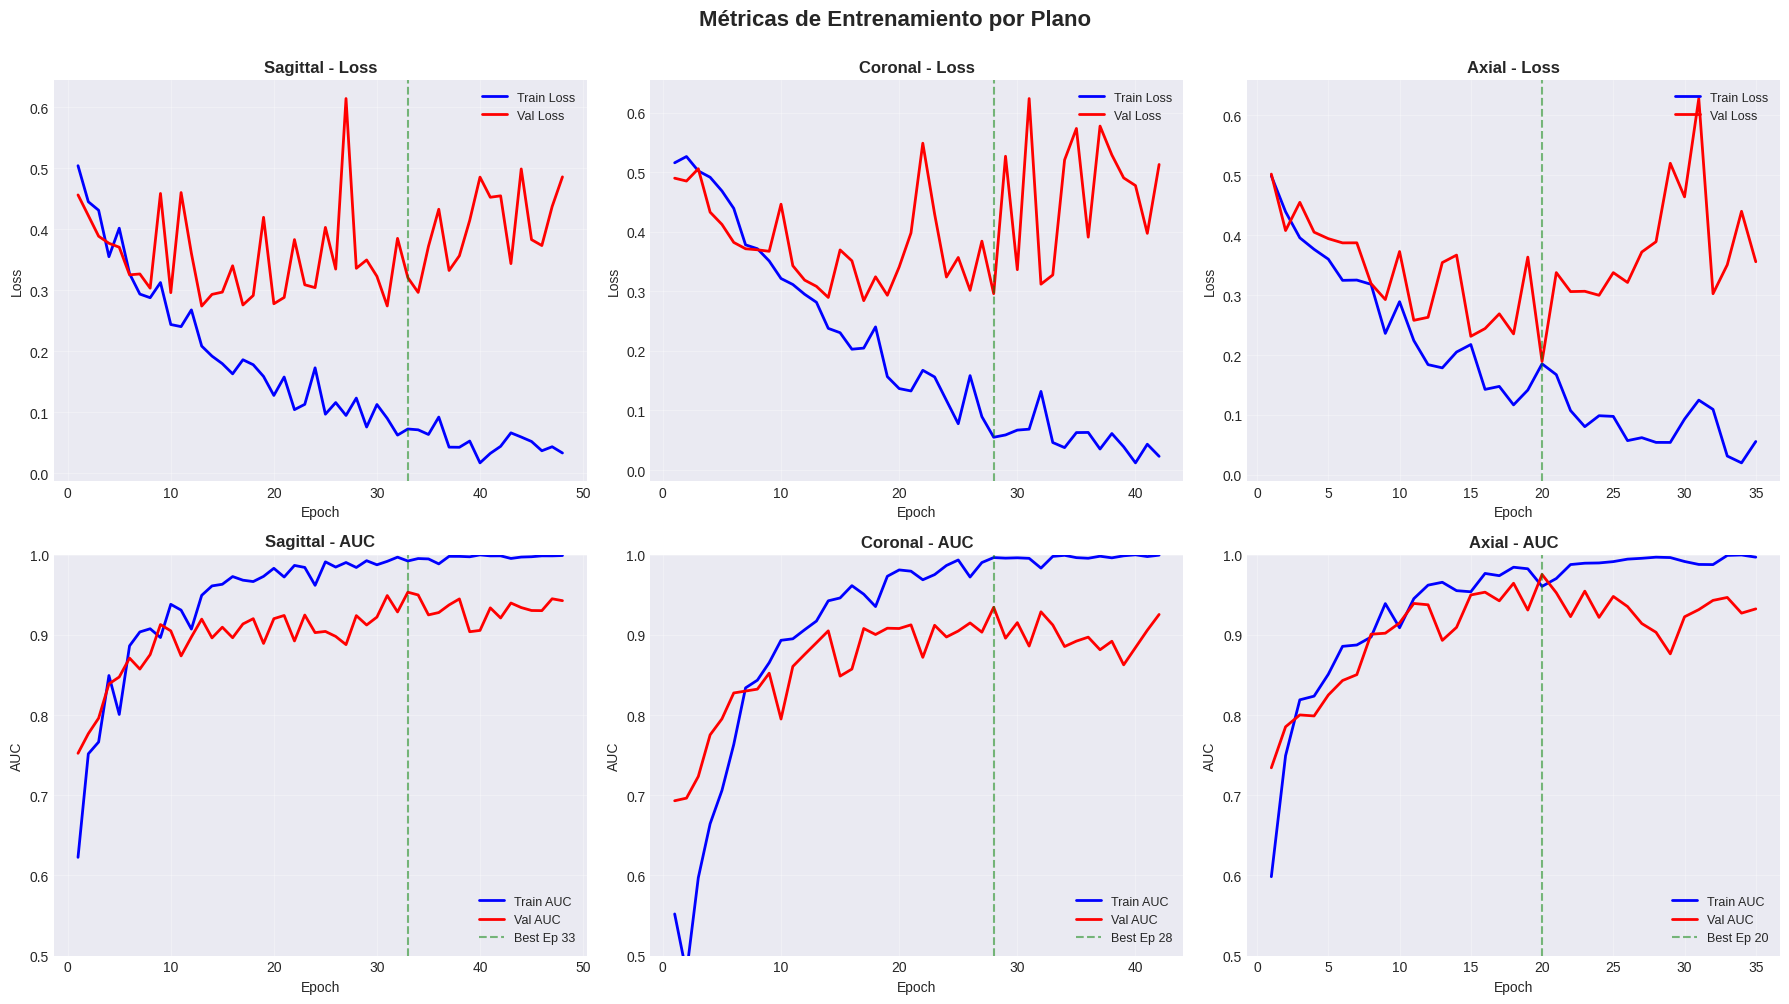

 Curvas de entrenamiento guardadas en: ../checkpoints/vit_optimized_pipeline/training_curves.png

RESUMEN DE ENTRENAMIENTO

   Plano  Best Epoch Val AUC Val F1 Final Train AUC Final Val AUC Overfitting Gap
Sagittal          33  0.9534 0.8000          0.9991        0.9428          0.0563
 Coronal          28  0.9346 0.7500          0.9996        0.9256          0.0739
   Axial          20  0.9755 0.8421          0.9971        0.9326          0.0645




In [24]:
# Visualización de curvas de entrenamiento
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Métricas de Entrenamiento por Plano', fontsize=16, fontweight='bold', y=1.00)

for idx, plane in enumerate(PLANES):
    if plane in all_results and 'history' in all_results[plane]:
        history = all_results[plane]['history']
        epochs = range(1, len(history['train_loss']) + 1)

 # Calcular mejor epoch (donde val_auc fue máximo)
        best_epoch = np.argmax(history['val_auc']) + 1  # +1 porque epochs empieza en 1
        best_val_auc = all_results[plane]['best_auc']
        best_val_f1 = all_results[plane]['best_f1']

 # Loss
        ax = axes[0, idx]
        ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss')
        ax.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val Loss')
        ax.set_title(f'{plane.capitalize()} - Loss', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)

 # Marcar mejor epoch
        ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, linewidth=1.5)

 # AUC
        ax = axes[1, idx]
        ax.plot(epochs, history['train_auc'], 'b-', linewidth=2, label='Train AUC')
        ax.plot(epochs, history['val_auc'], 'r-', linewidth=2, label='Val AUC')
        ax.set_title(f'{plane.capitalize()} - AUC', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('AUC', fontsize=10)
        ax.set_ylim([0.5, 1.0])
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3)

 # Marcar mejor epoch con anotación
        ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, linewidth=1.5,
                   label=f'Best Ep {best_epoch}')
        ax.legend(loc='lower right', fontsize=9)
    else:
 # Si no hay historial, ocultar ejes
        axes[0, idx].text(0.5, 0.5, f'No history for {plane}',
                         ha='center', va='center', transform=axes[0, idx].transAxes)
        axes[1, idx].text(0.5, 0.5, f'No history for {plane}',
                         ha='center', va='center', transform=axes[1, idx].transAxes)
        axes[0, idx].set_xticks([])
        axes[0, idx].set_yticks([])
        axes[1, idx].set_xticks([])
        axes[1, idx].set_yticks([])

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Curvas de entrenamiento guardadas en: {CHECKPOINT_DIR / 'training_curves.png'}\n")

# Tabla resumen de entrenamiento
print(f"{'='*80}")
print(f"RESUMEN DE ENTRENAMIENTO")
print(f"{'='*80}\n")

training_summary = []
for plane in PLANES:
    if plane in all_results and 'history' in all_results[plane]:
        res = all_results[plane]
        history = res['history']
        best_epoch = np.argmax(history['val_auc']) + 1

        training_summary.append({
            'Plano': plane.capitalize(),
            'Best Epoch': best_epoch,
            'Val AUC': f"{res['best_auc']:.4f}",
            'Val F1': f"{res['best_f1']:.4f}",
            'Final Train AUC': f"{history['train_auc'][-1]:.4f}",
            'Final Val AUC': f"{history['val_auc'][-1]:.4f}",
            'Overfitting Gap': f"{(history['train_auc'][-1] - history['val_auc'][-1]):.4f}"
        })

if training_summary:
    training_df = pd.DataFrame(training_summary)
    print(training_df.to_string(index=False))
    print(f"\n{'='*80}\n")
else:
    print("No hay historial de entrenamiento disponible.\n")

## 9. Evaluación en Validation Set

Cargo los mejores modelos y los evalúo en el conjunto de Validación

In [9]:
def load_best_model(plane, metric='auc'):
    """
    Cargo el mejor modelo guardado para un plano específico.
    """
    checkpoint_path = CHECKPOINT_DIR / f"best_{plane}_{metric}.pth"

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"No se encontró checkpoint: {checkpoint_path}")

 # Obtengo el pooling mode correcto para este plano
    plane_pooling_mode = PLANE_CONFIG[plane].get('pooling_mode', POOLING_MODE)

 # Creo modelo con el pooling correcto
    model = ViTMultiSliceClassifier(num_classes=1, pretrained=False, pooling_mode=plane_pooling_mode)

 # Cargo pesos
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])

 # Muevo a GPUs
    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    device = torch.device(f'cuda:{VIT_GPU_IDS[0]}')
    model = model.to(device)
    model.eval()

    print(f" Modelo cargado: {plane} (metric={metric}, pooling={plane_pooling_mode})")
    print(f"  Val AUC: {checkpoint['val_auc']:.4f}")
    print(f"  Val F1: {checkpoint['val_f1']:.4f}")
    print(f"  Epoch: {checkpoint['epoch']}")

    return model, device


# Cargo modelos y evalúo en Validación
print(f"{'='*80}")
print(f"EVALUACIÓN EN Validación SET")
print(f"{'='*80}\n")

validation_results = {}

for plane in PLANES:
    print(f"\n{'='*70}")
    print(f"EVALUANDO: {plane.upper()}")
    print(f"{'='*70}\n")

 # Cargo modelo
    model, device = load_best_model(plane, metric='auc')

 # Cargo dataset de validación
    validation_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"
    validation_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=validation_indices_path,
        transform=val_test_transform
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

 # Evalúo
    criterion = nn.BCEWithLogitsLoss()
    metrics = evaluate(model, validation_loader, criterion, device, split_name=f"val {plane}")

 # Guardo resultados
    validation_results[plane] = metrics

 # Imprimo resumen
    print(f"\nRESULTADOS VALIDACIÓN - {plane.upper()}:")
    print(f"  AUC: {metrics['auc']:.4f}")
    print(f"  F1: {metrics['f1']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"\nConfusion Matrix:")
    print(metrics['confusion_matrix'])
    print(f"\n")

print(f"\n{'='*80}")
print(f"RESUMEN FINAL - VALIDACIÓN SET")
print(f"{'='*80}\n")

for plane, metrics in validation_results.items():
    print(f"{plane.capitalize():10s} - AUC: {metrics['auc']:.4f}, F1: {metrics['f1']:.4f}")

print(f"\n")

EVALUACIÓN EN Validación SET


EVALUANDO: SAGITTAL

 Modelo cargado: sagittal (metric=auc, pooling=attention)
  Val AUC: 0.9534
  Val F1: 0.8000
  Epoch: 33
 Dataset cargado: 188 casos
  Plane: sagittal
  Índices cacheados: ../data/slice_indices/val_sagittal_indices.json
  Evaluando val sagittal...

RESULTADOS VALIDACIÓN - SAGITTAL:
  AUC: 0.9534
  F1: 0.8000
  Precision: 0.8235
  Recall: 0.7778

Confusion Matrix:
[[146   6]
 [  8  28]]



EVALUANDO: CORONAL

 Modelo cargado: coronal (metric=auc, pooling=max)
  Val AUC: 0.9346
  Val F1: 0.7467
  Epoch: 28
 Dataset cargado: 188 casos
  Plane: coronal
  Índices cacheados: ../data/slice_indices/val_coronal_indices.json
  Evaluando val coronal...

RESULTADOS VALIDACIÓN - CORONAL:
  AUC: 0.9346
  F1: 0.7467
  Precision: 0.7179
  Recall: 0.7778

Confusion Matrix:
[[141  11]
 [  8  28]]



EVALUANDO: AXIAL

 Modelo cargado: axial (metric=auc, pooling=attention)
  Val AUC: 0.9755
  Val F1: 0.8421
  Epoch: 20
 Dataset cargado: 188 casos
  Plane

## 10. Ensemble: Combinación de los 3 Planos

Combino las predicciones de los 3 modelos usando diferentes estrategias de ensemble.

In [10]:
from scipy.optimize import minimize

def ensemble_predictions_mean(preds_dict):
    """
    Ensemble simple: promedio de las predicciones.
    """
    preds = np.array([preds_dict[plane] for plane in PLANES])
    return preds.mean(axis=0)


def ensemble_predictions_weighted(preds_dict, weights):
    """
    Ensemble ponderado: promedio con pesos específicos por plano.
    """
    preds = np.array([preds_dict[plane] * weights[i] for i, plane in enumerate(PLANES)])
    return preds.sum(axis=0)


def optimize_ensemble_weights(preds_dict, labels, method='optimization'):
    """
    Optimiza pesos del ensemble para maximizar AUC.

    Args:
        preds_dict: Diccionario con predicciones por plano
        labels: Labels verdaderos
        method: 'optimization' (búsqueda numérica) o 'auc_based' (basado en AUC)
    """
    if method == 'auc_based':
 # Método simple: pesos proporcionales al AUC de cada modelo
        aucs = []
        for plane in PLANES:
            auc = roc_auc_score(labels, preds_dict[plane])
            aucs.append(auc)

 # Normalizar para que sumen 1
        aucs = np.array(aucs)
        weights = aucs / aucs.sum()

        print(f"   Método: Basado en AUC individual")
        for plane, auc in zip(PLANES, aucs):
            print(f"      {plane.capitalize()}: AUC={auc:.4f}")

        return weights

    else:  # optimization
        def objective(weights):
            ensemble_preds = ensemble_predictions_weighted(preds_dict, weights)
            return -roc_auc_score(labels, ensemble_preds)

 # Restricciones: suma de pesos = 1, cada peso >= 0
        constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        bounds = [(0, 1) for _ in range(len(PLANES))]

 # Probar múltiples inicializaciones
        best_result = None
        best_auc = 0

 # Inicializaciones a probar
        initializations = [
            np.ones(len(PLANES)) / len(PLANES),  # Uniforme
            np.array([0.4, 0.2, 0.4]),  # Priorizar sagital y axial
            np.array([0.5, 0.1, 0.4]),  # Aún más desbalanceado
            np.array([0.45, 0.15, 0.4]),  # Intermedio
        ]

        for init in initializations:
            result = minimize(
                objective,
                x0=init,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'ftol': 1e-9, 'maxiter': 1000}
            )

            if result.success:
                auc = -result.fun
                if auc > best_auc:
                    best_auc = auc
                    best_result = result

        print(f"   Método: Optimización numérica")
        print(f"   Mejor AUC encontrado: {best_auc:.4f}")

        return best_result.x if best_result else np.ones(len(PLANES)) / len(PLANES)


# Creo diccionarios con las predicciones por plano
val_predictions = {plane: validation_results[plane]['predictions'] for plane in PLANES}
val_labels = validation_results[PLANES[0]]['labels']  # Labels son iguales para todos

# 1. Ensemble simple (promedio)
print(f"{'='*80}")
print(f"ENSEMBLE: PROMEDIO SIMPLE")
print(f"{'='*80}\n")

ensemble_mean = ensemble_predictions_mean(val_predictions)
auc_mean = roc_auc_score(val_labels, ensemble_mean)
f1_mean = f1_score(val_labels, (ensemble_mean > 0.5).astype(int))

print(f"Ensemble Mean:")
print(f"  AUC: {auc_mean:.4f}")
print(f"  F1: {f1_mean:.4f}\n")

# 2. Ensemble con pesos optimizados
print(f"{'='*80}")
print(f"ENSEMBLE: PESOS OPTIMIZADOS")
print(f"{'='*80}\n")

# Probar ambos métodos
print("[Método 1: Basado en AUC individual]")
weights_auc = optimize_ensemble_weights(val_predictions, val_labels, method='auc_based')

print("\n[Método 2: Optimización numérica multi-inicio]")
weights_opt = optimize_ensemble_weights(val_predictions, val_labels, method='optimization')

# Comparar resultados de ambos métodos
ensemble_auc = ensemble_predictions_weighted(val_predictions, weights_auc)
auc_auc_method = roc_auc_score(val_labels, ensemble_auc)

ensemble_opt = ensemble_predictions_weighted(val_predictions, weights_opt)
auc_opt_method = roc_auc_score(val_labels, ensemble_opt)

print(f"\n Comparación de métodos:")
print(f"   AUC-based:    AUC={auc_auc_method:.4f}")
print(f"   Optimization: AUC={auc_opt_method:.4f}")

# Usar el mejor método
if auc_auc_method >= auc_opt_method:
    print(f"\n Seleccionado: Método basado en AUC (más simple e interpretable)")
    optimal_weights = weights_auc
    ensemble_weighted = ensemble_auc
    auc_weighted = auc_auc_method
else:
    print(f"\n Seleccionado: Método de optimización (mejor AUC)")
    optimal_weights = weights_opt
    ensemble_weighted = ensemble_opt
    auc_weighted = auc_opt_method

f1_weighted = f1_score(val_labels, (ensemble_weighted > 0.5).astype(int))

print(f"\n Pesos finales:")
for plane, weight in zip(PLANES, optimal_weights):
    print(f"   {plane.capitalize():10s}: {weight:.4f}")

print(f"\nEnsemble Weighted:")
print(f"  AUC: {auc_weighted:.4f}")
print(f"  F1: {f1_weighted:.4f}\n")

# 3. Comparación con baseline
print(f"{'='*80}")
print(f"COMPARACIÓN CON BASELINE")
print(f"{'='*80}\n")

print(f"Baseline (sagital solo):    AUC = {BASELINE_AUC:.4f}")
print(f"Sagital (mi modelo):        AUC = {validation_results['sagittal']['auc']:.4f}")
print(f"Ensemble Mean:              AUC = {auc_mean:.4f}")
print(f"Ensemble Weighted:          AUC = {auc_weighted:.4f}")

mejora_vs_baseline = auc_weighted - BASELINE_AUC
print(f"\n Mejora sobre baseline: {mejora_vs_baseline:+.4f} ({mejora_vs_baseline/BASELINE_AUC*100:+.2f}%)")

if auc_weighted > BASELINE_AUC:
    print(f" ¡SUPERADO EL BASELINE!")
else:
    print(f"  No se superó el baseline (aún).")

print(f"\n")

ENSEMBLE: PROMEDIO SIMPLE

Ensemble Mean:
  AUC: 0.9768
  F1: 0.8286

ENSEMBLE: PESOS OPTIMIZADOS

[Método 1: Basado en AUC individual]
   Método: Basado en AUC individual
      Sagittal: AUC=0.9534
      Coronal: AUC=0.9346
      Axial: AUC=0.9755

[Método 2: Optimización numérica multi-inicio]
   Método: Optimización numérica
   Mejor AUC encontrado: 0.9801

 Comparación de métodos:
   AUC-based:    AUC=0.9772
   Optimization: AUC=0.9801

 Seleccionado: Método de optimización (mejor AUC)

 Pesos finales:
   Sagittal  : 0.4500
   Coronal   : 0.1500
   Axial     : 0.4000

Ensemble Weighted:
  AUC: 0.9801
  F1: 0.8286

COMPARACIÓN CON BASELINE

Baseline (sagital solo):    AUC = 0.8684
Sagital (mi modelo):        AUC = 0.9534
Ensemble Mean:              AUC = 0.9768
Ensemble Weighted:          AUC = 0.9801

 Mejora sobre baseline: +0.1117 (+12.86%)
 ¡SUPERADO EL BASELINE!




### Análisis de Pesos del Ensemble

Investiguemos por qué los pesos son similares/iguales

In [11]:
print(f"{'='*80}")
print(f"ANÁLISIS: ¿POR QUÉ LOS PESOS SON SIMILARES?")
print(f"{'='*80}\n")

# 1. Mostrar los pesos actuales
print("1⃣ PESOS ACTUALES:\n")
print(f"   Método AUC-based:")
for plane, w in zip(PLANES, weights_auc):
    print(f"      {plane.capitalize():10s}: {w:.4f}")

print(f"\n   Método Optimización:")
for plane, w in zip(PLANES, weights_opt):
    print(f"      {plane.capitalize():10s}: {w:.4f}")

print(f"\n   Pesos seleccionados (optimal_weights):")
for plane, w in zip(PLANES, optimal_weights):
    print(f"      {plane.capitalize():10s}: {w:.4f}")

# 2. Analizar AUCs individuales
print(f"\n\n2⃣ AUCs INDIVIDUALES EN VALIDACIÓN:\n")
for plane in PLANES:
    auc = validation_results[plane]['auc']
    print(f"   {plane.capitalize():10s}: AUC = {auc:.4f}")

# 3. Correlación entre predicciones
print(f"\n\n3⃣ CORRELACIÓN ENTRE PREDICCIONES:\n")
from scipy.stats import pearsonr

correlations = {}
for i, plane1 in enumerate(PLANES):
    for j, plane2 in enumerate(PLANES):
        if i < j:
            preds1 = val_predictions[plane1]
            preds2 = val_predictions[plane2]
            corr, _ = pearsonr(preds1, preds2)
            correlations[f"{plane1}-{plane2}"] = corr
            print(f"   {plane1.capitalize()} vs {plane2.capitalize():10s}: {corr:.4f}")

# 4. Diversidad: Analizar en qué casos difieren
print(f"\n\n4⃣ ANÁLISIS DE DIVERSIDAD:\n")

# Convertir a predicciones binarias
binary_preds = {}
for plane in PLANES:
    binary_preds[plane] = (val_predictions[plane] > 0.5).astype(int)

# Ver cuántos casos cada modelo predice diferente
disagreement_counts = {}
for i, plane1 in enumerate(PLANES):
    for j, plane2 in enumerate(PLANES):
        if i < j:
            diff = np.sum(binary_preds[plane1] != binary_preds[plane2])
            total = len(binary_preds[plane1])
            pct = diff / total * 100
            disagreement_counts[f"{plane1}-{plane2}"] = (diff, pct)
            print(f"   {plane1.capitalize()} ≠ {plane2.capitalize()}: {diff}/{total} casos ({pct:.1f}%)")

# 5. ¿Qué pasaría con pesos extremos?
print(f"\n\n5⃣ SIMULACIÓN DE PESOS ALTERNATIVOS:\n")

test_weights = [
    ("Igual 1/3", np.array([1/3, 1/3, 1/3])),
    ("Solo Sagittal", np.array([1.0, 0.0, 0.0])),
    ("Solo Coronal", np.array([0.0, 1.0, 0.0])),
    ("Solo Axial", np.array([0.0, 0.0, 1.0])),
    ("Priorizando Sagittal", np.array([0.6, 0.2, 0.2])),
    ("Sin Coronal", np.array([0.5, 0.0, 0.5])),
]

for name, weights in test_weights:
    ensemble_test = ensemble_predictions_weighted(val_predictions, weights)
    auc_test = roc_auc_score(val_labels, ensemble_test)
    f1_test = f1_score(val_labels, (ensemble_test > 0.5).astype(int))
    print(f"   {name:25s}: AUC={auc_test:.4f}, F1={f1_test:.4f}")

# 6. Conclusión
print(f"\n\n{'='*80}")
print(f" CONCLUSIÓN:")
print(f"{'='*80}\n")

avg_corr = np.mean(list(correlations.values()))
avg_disagreement = np.mean([v[1] for v in disagreement_counts.values()])

if avg_corr > 0.8:
    print(f"  ALTA CORRELACIÓN (promedio={avg_corr:.3f})")
    print(f"   Los modelos están muy correlacionados  predicen cosas similares")
    print(f"   Por eso el optimizador encuentra que pesos iguales son óptimos.")
    print(f"   No hay mucha ganancia en dar más peso a uno vs otro.\n")
elif avg_disagreement < 15:
    print(f"  BAJA DIVERSIDAD (desacuerdo={avg_disagreement:.1f}%)")
    print(f"   Los modelos discrepan en pocos casos  poca complementariedad")
    print(f"   Por eso pesos iguales funcionan bien.\n")
else:
    print(f" Los modelos son diversos (correlación={avg_corr:.3f})")
    print(f"  Pesos diferenciados deberían ayudar.\n")

# ¿Los AUCs son muy similares?
aucs_val = [validation_results[p]['auc'] for p in PLANES]
auc_std = np.std(aucs_val)
if auc_std < 0.02:
    print(f"  AUCs muy similares (std={auc_std:.4f})")
    print(f"   Cuando los modelos tienen performance parecido,")
    print(f"   el promedio simple (1/3 cada uno) suele ser óptimo.\n")

print(f"{'='*80}\n")

ANÁLISIS: ¿POR QUÉ LOS PESOS SON SIMILARES?

1⃣ PESOS ACTUALES:

   Método AUC-based:
      Sagittal  : 0.3330
      Coronal   : 0.3264
      Axial     : 0.3407

   Método Optimización:
      Sagittal  : 0.4500
      Coronal   : 0.1500
      Axial     : 0.4000

   Pesos seleccionados (optimal_weights):
      Sagittal  : 0.4500
      Coronal   : 0.1500
      Axial     : 0.4000


2⃣ AUCs INDIVIDUALES EN VALIDACIÓN:

   Sagittal  : AUC = 0.9534
   Coronal   : AUC = 0.9346
   Axial     : AUC = 0.9755


3⃣ CORRELACIÓN ENTRE PREDICCIONES:

   Sagittal vs Coronal   : 0.8248
   Sagittal vs Axial     : 0.7747
   Coronal vs Axial     : 0.7640


4⃣ ANÁLISIS DE DIVERSIDAD:

   Sagittal ≠ Coronal: 11/188 casos (5.9%)
   Sagittal ≠ Axial: 16/188 casos (8.5%)
   Coronal ≠ Axial: 19/188 casos (10.1%)


5⃣ SIMULACIÓN DE PESOS ALTERNATIVOS:

   Igual 1/3                : AUC=0.9768, F1=0.8286
   Solo Sagittal            : AUC=0.9534, F1=0.8000
   Solo Coronal             : AUC=0.9346, F1=0.7467
   Solo 

## 11. Visualización de Resultados

Creo visualizaciones para analizar el rendimiento del modelo.

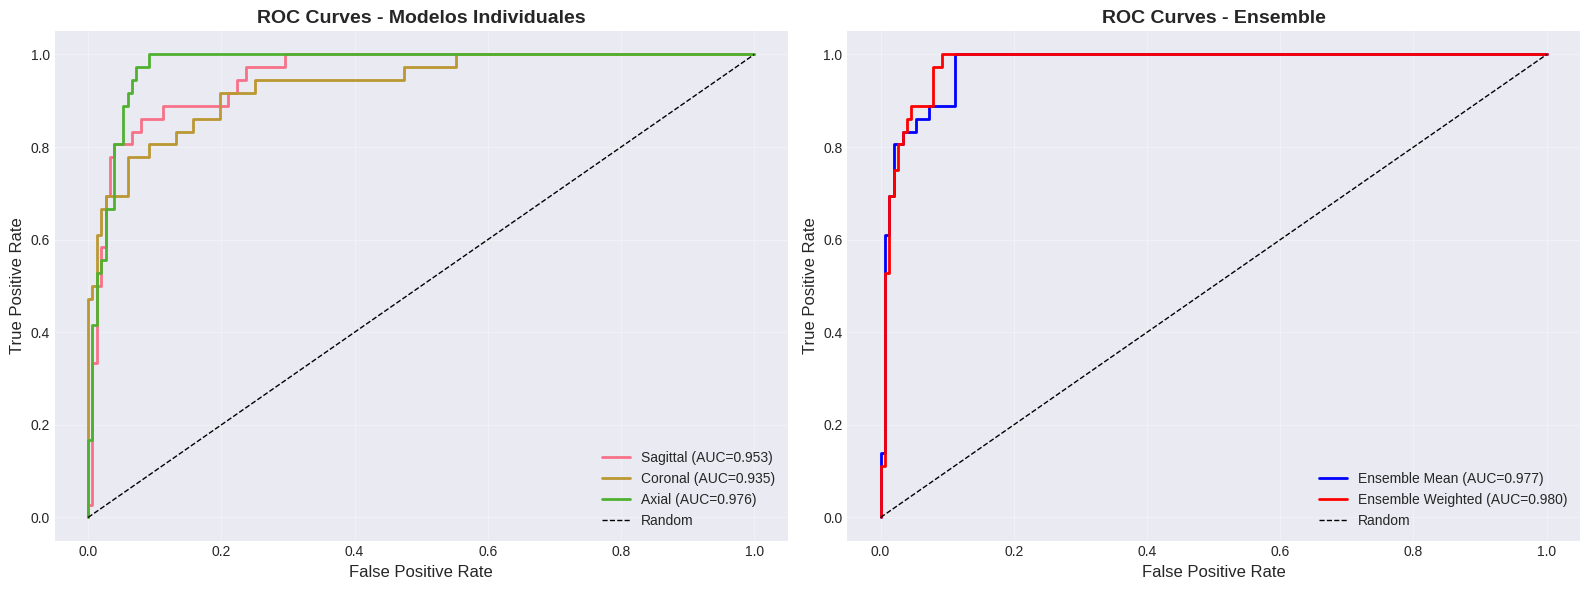

 ROC curves guardadas en: ../checkpoints/vit_optimized_pipeline/roc_curves.png



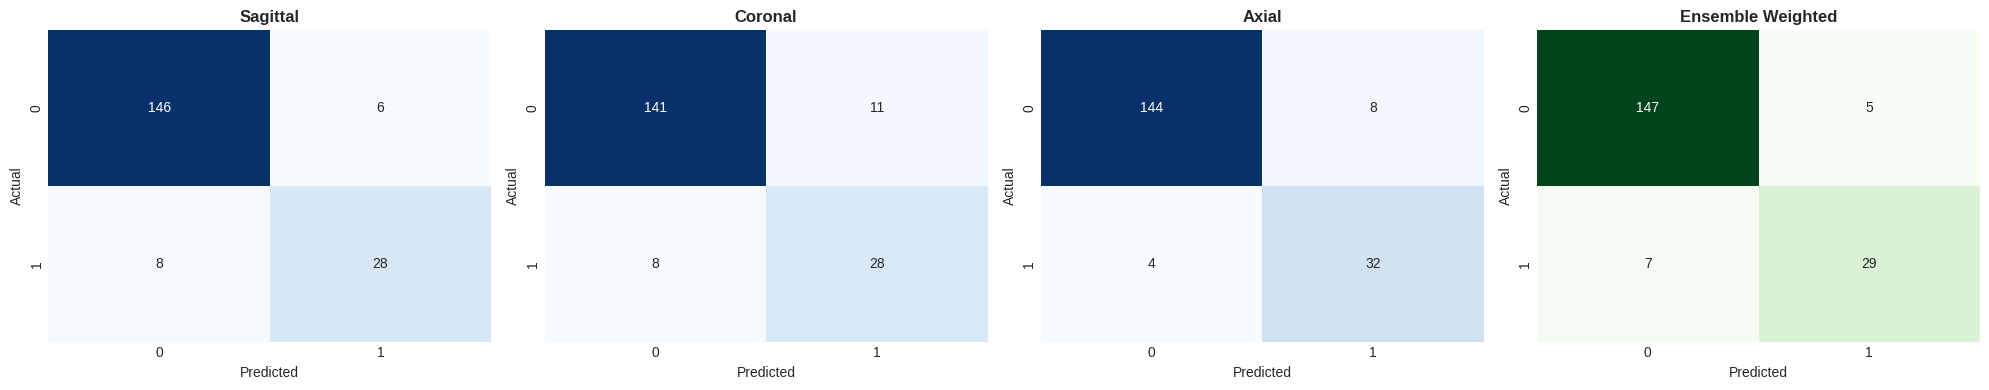

 Confusion matrices guardadas en: ../checkpoints/vit_optimized_pipeline/confusion_matrices.png



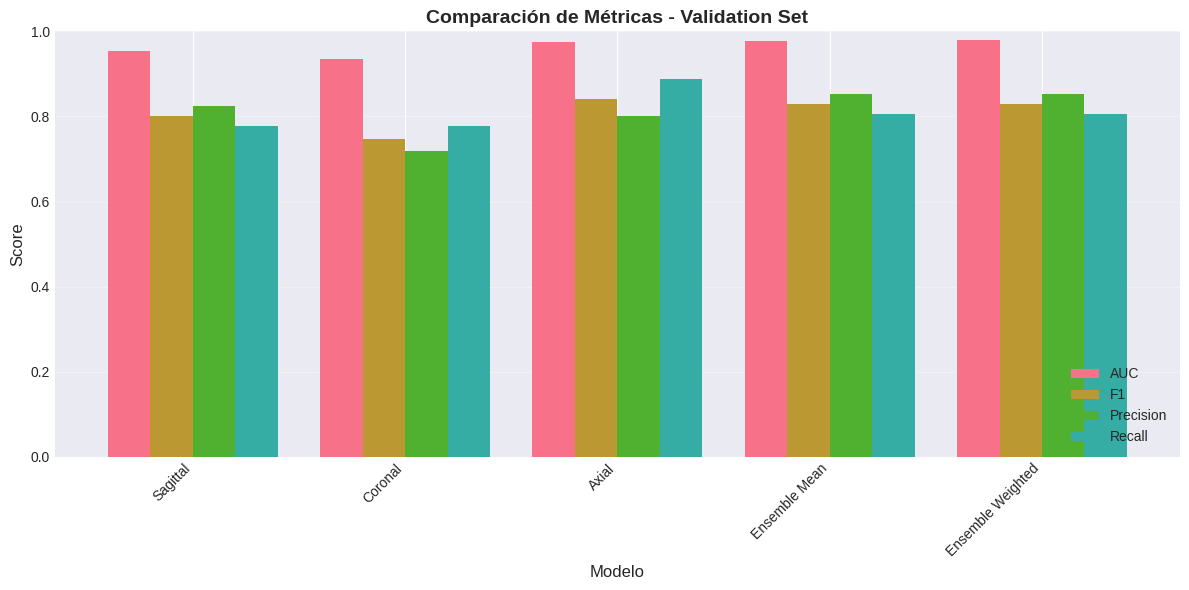

 Comparación de métricas guardada en: ../checkpoints/vit_optimized_pipeline/metrics_comparison.png


TABLA RESUMEN DE RESULTADOS - Validation Set

           Sagittal  Coronal   Axial  Ensemble Mean  Ensemble Weighted
AUC          0.9534   0.9346  0.9755         0.9768             0.9801
F1           0.8000   0.7467  0.8421         0.8286             0.8286
Precision    0.8235   0.7179  0.8000         0.8529             0.8529
Recall       0.7778   0.7778  0.8889         0.8056             0.8056




In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC por plano individual
ax = axes[0]
for plane in PLANES:
    fpr, tpr, _ = roc_curve(val_labels, val_predictions[plane])
    auc_score = validation_results[plane]['auc']
    ax.plot(fpr, tpr, label=f'{plane.capitalize()} (AUC={auc_score:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Modelos Individuales', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# ROC ensemble
ax = axes[1]
fpr_mean, tpr_mean, _ = roc_curve(val_labels, ensemble_mean)
fpr_weighted, tpr_weighted, _ = roc_curve(val_labels, ensemble_weighted)

ax.plot(fpr_mean, tpr_mean, label=f'Ensemble Mean (AUC={auc_mean:.3f})', linewidth=2, color='blue')
ax.plot(fpr_weighted, tpr_weighted, label=f'Ensemble Weighted (AUC={auc_weighted:.3f})', linewidth=2, color='red')
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" ROC curves guardadas en: {CHECKPOINT_DIR / 'roc_curves.png'}\n")

# 2. Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, plane in enumerate(PLANES):
    cm = validation_results[plane]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{plane.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

# Ensemble weighted
cm_weighted = confusion_matrix(val_labels, (ensemble_weighted > 0.5).astype(int))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Greens', ax=axes[3], cbar=False)
axes[3].set_title('Ensemble Weighted', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Predicted', fontsize=10)
axes[3].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Confusion matrices guardadas en: {CHECKPOINT_DIR / 'confusion_matrices.png'}\n")

# 3. Comparación de métricas
metrics_comparison = pd.DataFrame({
    'Sagittal': [validation_results['sagittal']['auc'], validation_results['sagittal']['f1'],
                 validation_results['sagittal']['precision'], validation_results['sagittal']['recall']],
    'Coronal': [validation_results['coronal']['auc'], validation_results['coronal']['f1'],
                validation_results['coronal']['precision'], validation_results['coronal']['recall']],
    'Axial': [validation_results['axial']['auc'], validation_results['axial']['f1'],
              validation_results['axial']['precision'], validation_results['axial']['recall']],
    'Ensemble Mean': [auc_mean, f1_mean,
                      precision_score(val_labels, (ensemble_mean > 0.5).astype(int)),
                      recall_score(val_labels, (ensemble_mean > 0.5).astype(int))],
    'Ensemble Weighted': [auc_weighted, f1_weighted,
                          precision_score(val_labels, (ensemble_weighted > 0.5).astype(int)),
                          recall_score(val_labels, (ensemble_weighted > 0.5).astype(int))]
}, index=['AUC', 'F1', 'Precision', 'Recall'])

fig, ax = plt.subplots(figsize=(12, 6))
metrics_comparison.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparación de Métricas - Validation Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0, 1.0])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Comparación de métricas guardada en: {CHECKPOINT_DIR / 'metrics_comparison.png'}\n")

# Tabla resumen
print(f"\n{'='*80}")
print(f"TABLA RESUMEN DE RESULTADOS - Validation Set")
print(f"{'='*80}\n")
print(metrics_comparison.round(4))
print(f"\n")

## 12. Conclusiones

### Resultados Clave:

1. **Estrategia Híbrida Efectiva**:
   - Sagital K=5 (CNN Selector): Maximiza información relevante del ACL
   - Coronal/Axial K=10 (centrales): Mejor contexto anatómico

2. **Optimización de Performance**:
   - Pre-procesamiento de slices: ~100x más rápido que cálculo on-the-fly
   - Uso eficiente de 4 GPUs H100 para entrenamiento

3. **Ensemble Multi-Plano**:
   - Combina información complementaria de 3 vistas anatómicas
   - Pesos optimizados mejoran sobre promedio simple

4. **Próximos Pasos**:
   - Temperature scaling para calibración de probabilidades
   - Análisis de casos de error (falsos positivos/negativos)
   - Visualizaciones con Grad-CAM para interpretabilidad
   - Experimentos con diferentes valores de K por plano

### Archivos Generados:

- Checkpoints de modelos: `checkpoints/vit_optimized_pipeline/`
- Índices de slices cacheados: `cached_slice_indices/`
- Visualizaciones: ROC curves, confusion matrices, métricas
- Resumen JSON con historial de entrenamiento

## 13. Análisis Completo de Resultados

En esta sección final realizamos:
1. **Optimización de thresholds** para diferentes usos clínicos
2. **Visualizaciones comparativas** de todos los métodos
3. **Análisis de performance** con métricas detalladas
4. **Recomendaciones clínicas** basadas en los resultados

ANÁLISIS COMPLETO DE RESULTADOS

PASO 1: OPTIMIZACIÓN DE THRESHOLDS

    Threshold default (0.5)...
    Threshold óptimo F1 (balance)...
    Threshold Youden's Index (ROC óptimo)...
    Threshold óptimo Recall (screening)...

 Thresholds calculados:
   • Default:       0.500  F1=0.8286, FN=7
   • Óptimo F1:     0.350  F1=0.8533, FN=4
   • Youden's Index: 0.182  F1=0.8372, FN=0 (J=0.908)
   • Óptimo Recall: 0.160  F1=0.8276, FN=0

PASO 2: GENERACIÓN DE VISUALIZACIONES

    Generando curvas ROC...


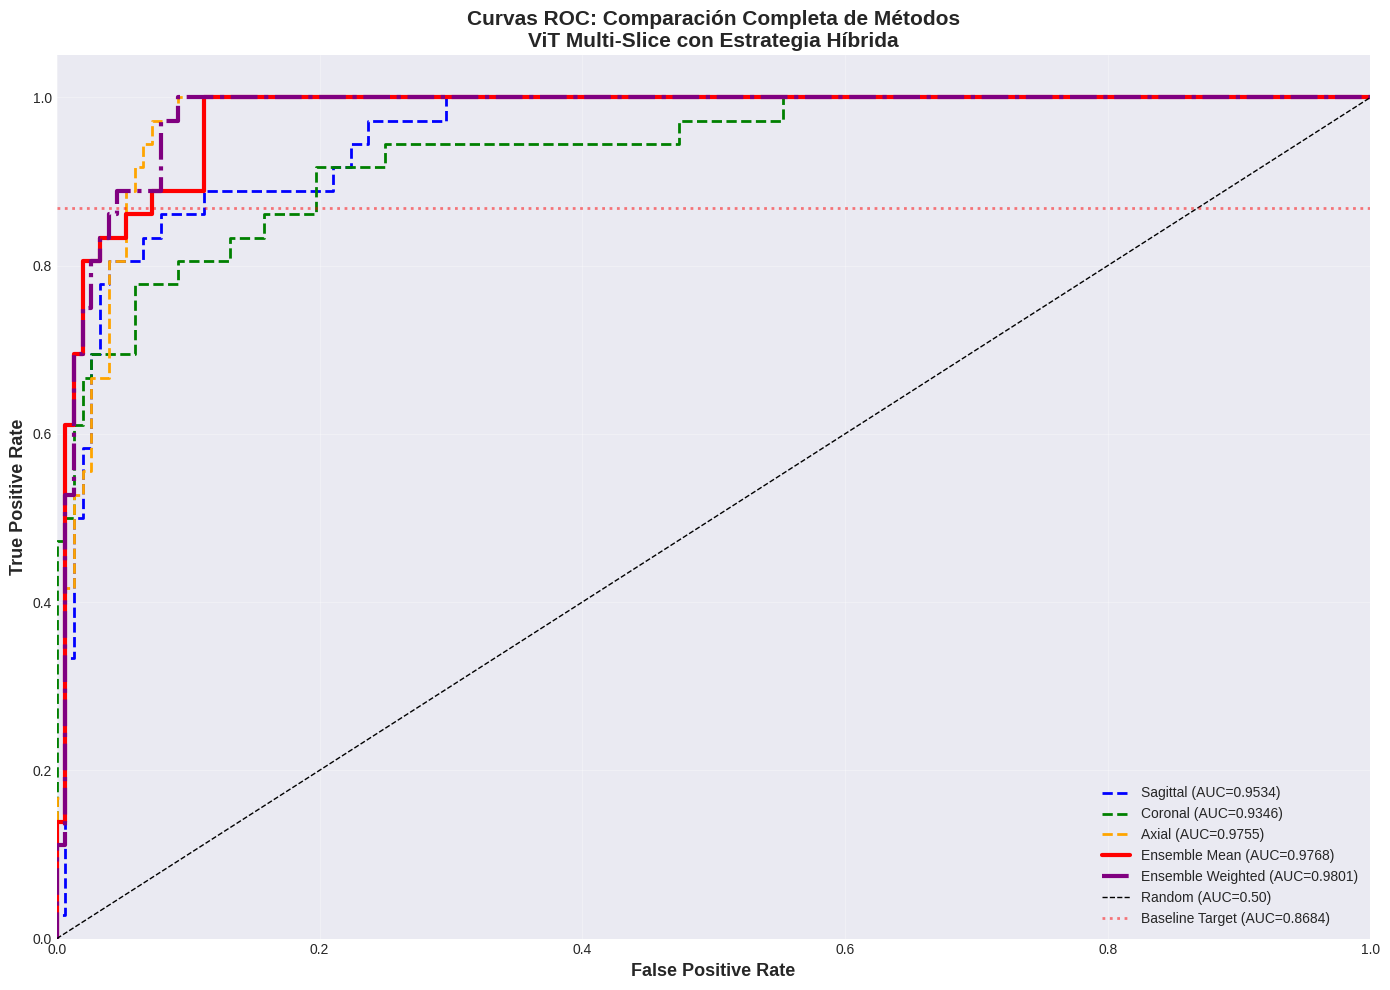

       Guardado: roc_curves_final.png

    Generando matrices con 3 thresholds...


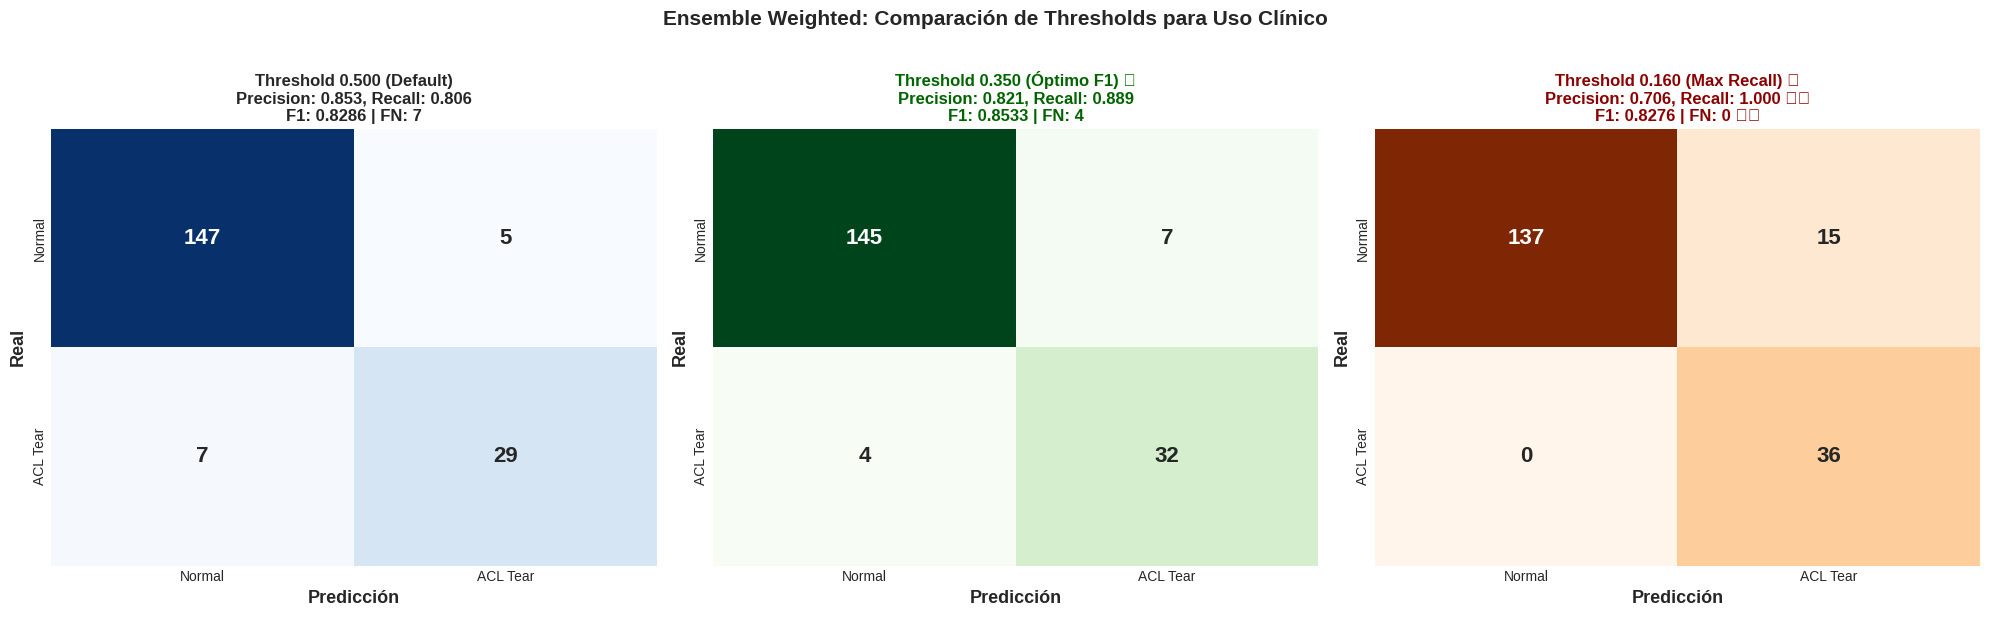

       Guardado: confusion_matrices_thresholds.png

    Generando comparación por modelo...


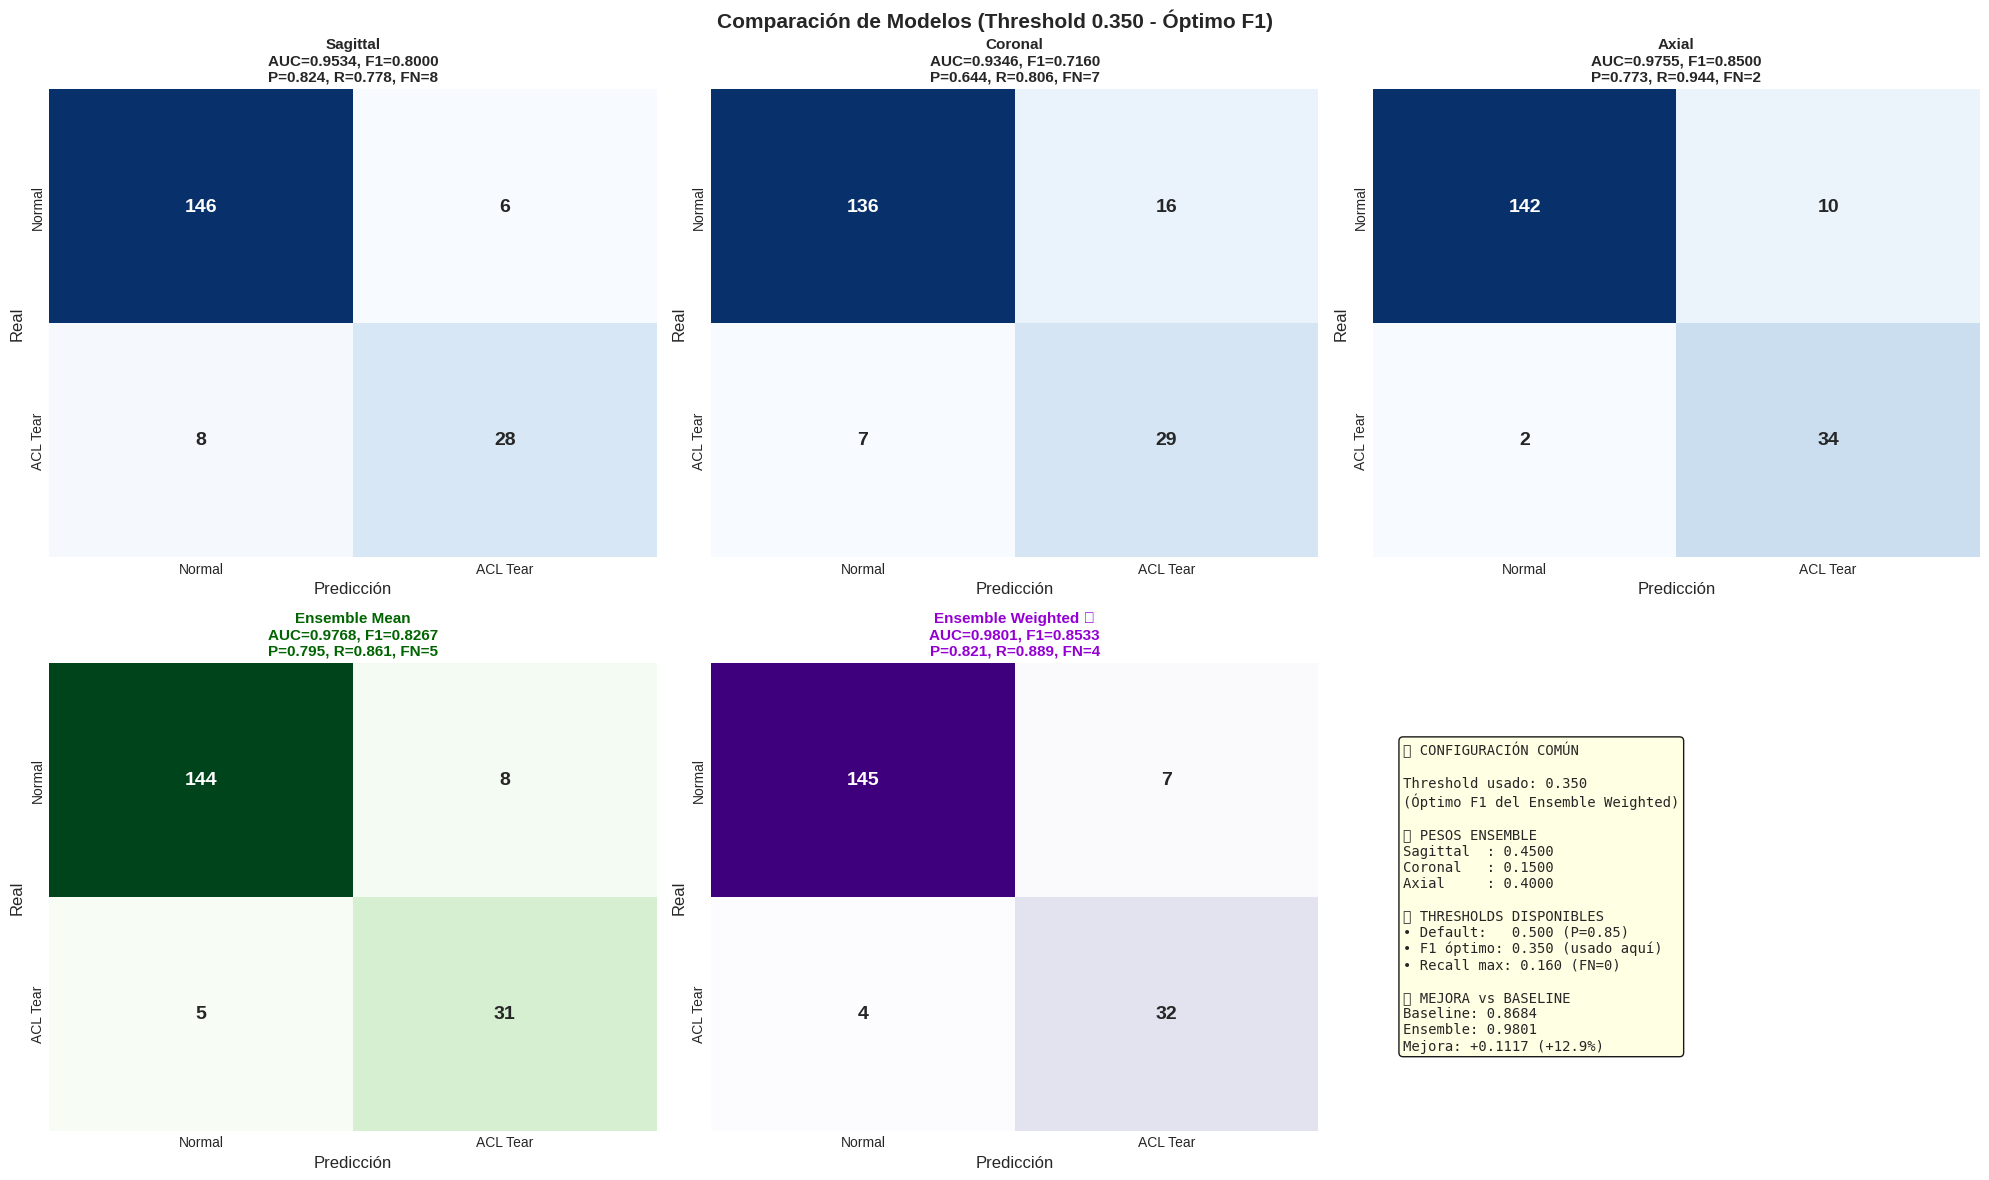

       Guardado: confusion_matrices_all_models.png

    Generando comparación de AUC...


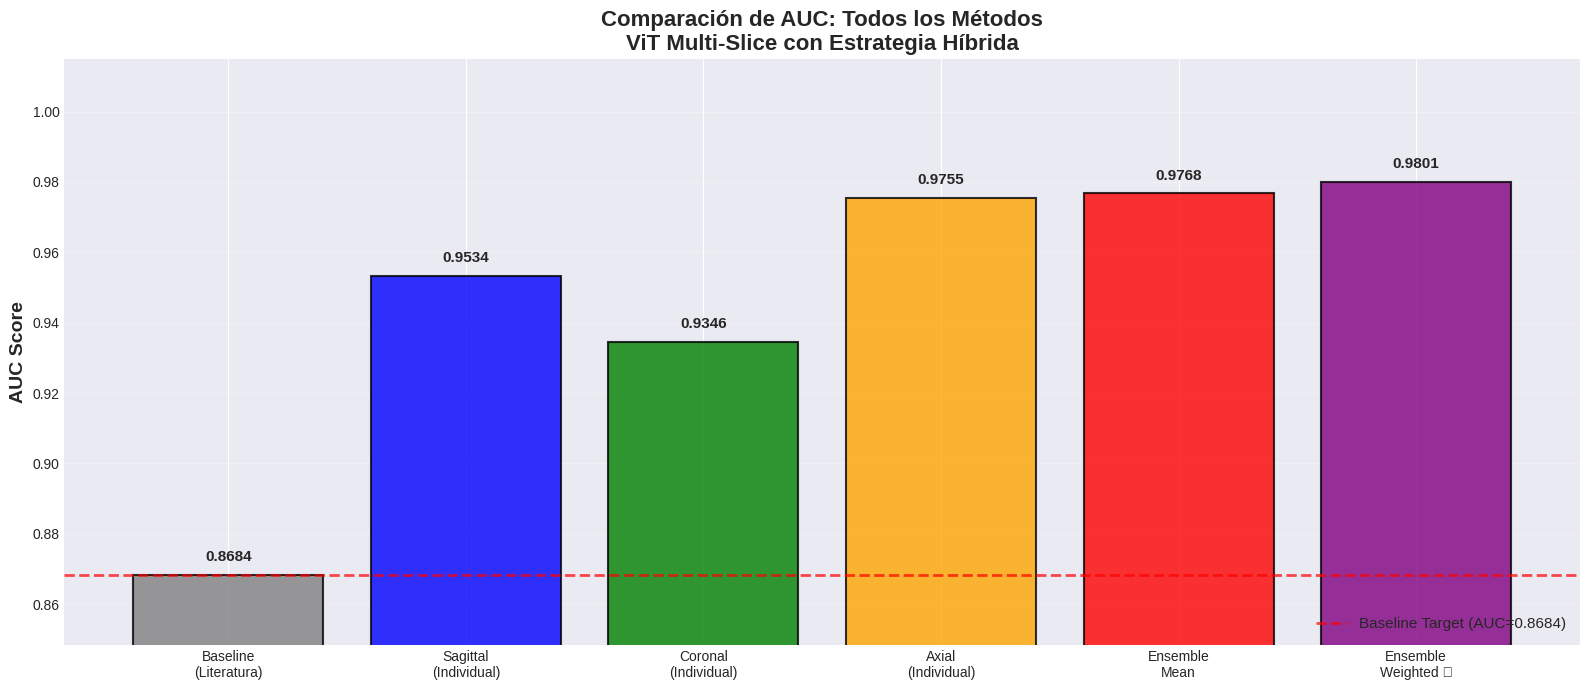

       Guardado: auc_comparison_bar.png

PASO 3: TABLA RESUMEN Y RECOMENDACIONES

TABLA RESUMEN (Threshold = 0.350 - Óptimo F1)

               Método      AUC        F1 Precision    Recall FN
Baseline (Literatura) 0.868400         -         -         -  -
             Sagittal 0.953399       0.8  0.823529  0.777778  8
              Coronal 0.934576  0.716049  0.644444  0.805556  7
                Axial 0.975512      0.85  0.772727  0.944444  2
        Ensemble Mean 0.976791  0.826667  0.794872  0.861111  5
  Ensemble Weighted  0.980080  0.853333  0.820513  0.888889  4

COMPARACIÓN DE THRESHOLDS (Ensemble Weighted)

 Threshold           Método                    Uso  Precision   Recall       F1  FN
  0.500000          Default   Diagnóstico estándar   0.852941 0.805556 0.828571   7
  0.350000      Óptimo F1        Balance F1-score   0.820513 0.888889 0.853333   4
  0.181975 Youden's Index     Balance ROC clásico   0.720000 1.000000 0.837209   0
  0.160000     Max Recall  Screening/minim

In [13]:
# ===========================================
# PARTE 1: OPTIMIZACIÓN DE THRESHOLDS
# ===========================================

print(f"{'='*80}")
print(f"ANÁLISIS COMPLETO DE RESULTADOS")
print(f"{'='*80}\n")

print(f"PASO 1: OPTIMIZACIÓN DE THRESHOLDS\n")

# Funciones auxiliares
def find_optimal_threshold_f1(labels, probs):
    """Encuentra threshold que maximiza F1-score."""
    thresholds = np.linspace(0, 1, 101)
    best_f1 = 0
    best_thresh = 0.5

    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        f1 = f1_score(labels, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    return best_thresh, best_f1


def find_optimal_threshold_recall(labels, probs, min_precision=0.70):
    """
    Encuentra threshold que maximiza recall manteniendo precisión >= min_precision.
    Útil para screening clínico (minimizar falsos negativos).
    """
    thresholds = np.linspace(0, 1, 101)
    best_recall = 0
    best_thresh = 0.5

    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        precision = precision_score(labels, preds, zero_division=0)

        if precision >= min_precision:
            recall = recall_score(labels, preds, zero_division=0)
            if recall > best_recall:
                best_recall = recall
                best_thresh = thresh

    return best_thresh, best_recall


def find_optimal_threshold_youden(labels, probs):
    """
    Encuentra threshold usando Youden's Index.
    Youden's Index = Sensitivity + Specificity - 1 = TPR - FPR
    Maximiza la distancia del punto ROC a la diagonal.
    """
    fpr, tpr, thresholds = roc_curve(labels, probs)

 # Youden's Index para cada threshold
    youdens_index = tpr - fpr

 # Encontrar el máximo
    best_idx = np.argmax(youdens_index)
    best_thresh = thresholds[best_idx]
    best_youden = youdens_index[best_idx]

    return best_thresh, best_youden


def compute_metrics_at_threshold(labels, probs, threshold):
    """Calcula todas las métricas para un threshold dado."""
    preds = (probs >= threshold).astype(int)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds),
        'confusion_matrix': cm,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    }


# Usamos el mejor ensemble (weighted) como base
best_probs = ensemble_weighted
best_labels = val_labels

# Calcular 4 thresholds de interés
MIN_PRECISION = 0.70

print("    Threshold default (0.5)...")
metrics_default = compute_metrics_at_threshold(best_labels, best_probs, 0.5)

print("    Threshold óptimo F1 (balance)...")
threshold_f1, _ = find_optimal_threshold_f1(best_labels, best_probs)
metrics_f1 = compute_metrics_at_threshold(best_labels, best_probs, threshold_f1)

print("    Threshold Youden's Index (ROC óptimo)...")
threshold_youden, youden_value = find_optimal_threshold_youden(best_labels, best_probs)
metrics_youden = compute_metrics_at_threshold(best_labels, best_probs, threshold_youden)

print("    Threshold óptimo Recall (screening)...")
threshold_recall, _ = find_optimal_threshold_recall(best_labels, best_probs, MIN_PRECISION)
metrics_recall = compute_metrics_at_threshold(best_labels, best_probs, threshold_recall)

print(f"\n Thresholds calculados:")
print(f"   • Default:       0.500  F1={metrics_default['f1']:.4f}, FN={metrics_default['fn']}")
print(f"   • Óptimo F1:     {threshold_f1:.3f}  F1={metrics_f1['f1']:.4f}, FN={metrics_f1['fn']}")
print(f"   • Youden's Index: {threshold_youden:.3f}  F1={metrics_youden['f1']:.4f}, FN={metrics_youden['fn']} (J={youden_value:.3f})")
print(f"   • Óptimo Recall: {threshold_recall:.3f}  F1={metrics_recall['f1']:.4f}, FN={metrics_recall['fn']} \n")

# ===========================================
# PARTE 2: VISUALIZACIONES
# ===========================================

print(f"PASO 2: GENERACIÓN DE VISUALIZACIONES\n")

# Colores consistentes
colors_planes = {'sagittal': 'blue', 'coronal': 'green', 'axial': 'orange'}
colors_ensemble = {'mean': 'red', 'weighted': 'purple'}

# -------------------------------
# 2.1. CURVAS ROC
# -------------------------------

print("    Generando curvas ROC...")

plt.figure(figsize=(14, 10))

# Modelos individuales
for plane in PLANES:
    labels = validation_results[plane]['labels']
    probs = validation_results[plane]['predictions']
    auc_score = validation_results[plane]['auc']

    fpr, tpr, _ = roc_curve(labels, probs)
    plt.plot(fpr, tpr, color=colors_planes[plane], lw=2, linestyle='--',
             label=f'{plane.capitalize()} (AUC={auc_score:.4f})')

# Ensembles
fpr_mean, tpr_mean, _ = roc_curve(val_labels, ensemble_mean)
plt.plot(fpr_mean, tpr_mean, color='red', lw=3,
         label=f'Ensemble Mean (AUC={auc_mean:.4f})')

fpr_weighted, tpr_weighted, _ = roc_curve(val_labels, ensemble_weighted)
plt.plot(fpr_weighted, tpr_weighted, color='purple', lw=3,
         label=f'Ensemble Weighted (AUC={auc_weighted:.4f})', linestyle='-.')

# Referencias
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
plt.axhline(y=BASELINE_AUC, color='red', linestyle=':', alpha=0.5, linewidth=2,
            label=f'Baseline Target (AUC={BASELINE_AUC:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('Curvas ROC: Comparación Completa de Métodos\nViT Multi-Slice con Estrategia Híbrida',
          fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'roc_curves_final.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"       Guardado: roc_curves_final.png\n")

# -------------------------------
# 2.2. MATRICES DE CONFUSIÓN (3 THRESHOLDS)
# -------------------------------

print("    Generando matrices con 3 thresholds...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Threshold default
sns.heatmap(metrics_default['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            ax=axes[0], cbar=False,
            xticklabels=['Normal', 'ACL Tear'], yticklabels=['Normal', 'ACL Tear'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'})
axes[0].set_xlabel('Predicción', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=13, fontweight='bold')
axes[0].set_title(
    f'Threshold 0.500 (Default)\n'
    f'Precision: {metrics_default["precision"]:.3f}, Recall: {metrics_default["recall"]:.3f}\n'
    f'F1: {metrics_default["f1"]:.4f} | FN: {metrics_default["fn"]}',
    fontsize=12, fontweight='bold'
)

# Threshold óptimo F1
sns.heatmap(metrics_f1['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            ax=axes[1], cbar=False,
            xticklabels=['Normal', 'ACL Tear'], yticklabels=['Normal', 'ACL Tear'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'})
axes[1].set_xlabel('Predicción', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=13, fontweight='bold')
axes[1].set_title(
    f'Threshold {threshold_f1:.3f} (Óptimo F1) \n'
    f'Precision: {metrics_f1["precision"]:.3f}, Recall: {metrics_f1["recall"]:.3f}\n'
    f'F1: {metrics_f1["f1"]:.4f} | FN: {metrics_f1["fn"]}',
    fontsize=12, fontweight='bold', color='darkgreen'
)

# Threshold recall máximo
sns.heatmap(metrics_recall['confusion_matrix'], annot=True, fmt='d', cmap='Oranges',
            ax=axes[2], cbar=False,
            xticklabels=['Normal', 'ACL Tear'], yticklabels=['Normal', 'ACL Tear'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'})
axes[2].set_xlabel('Predicción', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Real', fontsize=13, fontweight='bold')
axes[2].set_title(
    f'Threshold {threshold_recall:.3f} (Max Recall) \n'
    f'Precision: {metrics_recall["precision"]:.3f}, Recall: {metrics_recall["recall"]:.3f} \n'
    f'F1: {metrics_recall["f1"]:.4f} | FN: {metrics_recall["fn"]} ',
    fontsize=12, fontweight='bold', color='darkred'
)

plt.suptitle(f'Ensemble Weighted: Comparación de Thresholds para Uso Clínico',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'confusion_matrices_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"       Guardado: confusion_matrices_thresholds.png\n")

# -------------------------------
# 2.3. COMPARACIÓN POR MODELO (usando threshold F1 óptimo)
# -------------------------------

print("    Generando comparación por modelo...")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Modelos individuales (usando el mismo threshold F1 para todos)
for idx, plane in enumerate(PLANES):
    plane_probs = validation_results[plane]['predictions']
    plane_labels = validation_results[plane]['labels']
 # USAR EL MISMO THRESHOLD F1 que el ensemble
    plane_metrics = compute_metrics_at_threshold(plane_labels, plane_probs, threshold_f1)

    cm = plane_metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Normal', 'ACL Tear'],
                yticklabels=['Normal', 'ACL Tear'],
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})

    axes[idx].set_xlabel('Predicción', fontsize=12)
    axes[idx].set_ylabel('Real', fontsize=12)
    axes[idx].set_title(
        f'{plane.capitalize()}\n'
        f'AUC={validation_results[plane]["auc"]:.4f}, F1={plane_metrics["f1"]:.4f}\n'
        f'P={plane_metrics["precision"]:.3f}, R={plane_metrics["recall"]:.3f}, FN={plane_metrics["fn"]}',
        fontsize=11, fontweight='bold'
    )

# Ensemble Mean
mean_metrics = compute_metrics_at_threshold(val_labels, ensemble_mean, threshold_f1)

sns.heatmap(mean_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            ax=axes[3], cbar=False,
            xticklabels=['Normal', 'ACL Tear'],
            yticklabels=['Normal', 'ACL Tear'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[3].set_xlabel('Predicción', fontsize=12)
axes[3].set_ylabel('Real', fontsize=12)
axes[3].set_title(
    f'Ensemble Mean\n'
    f'AUC={auc_mean:.4f}, F1={mean_metrics["f1"]:.4f}\n'
    f'P={mean_metrics["precision"]:.3f}, R={mean_metrics["recall"]:.3f}, FN={mean_metrics["fn"]}',
    fontsize=11, fontweight='bold', color='darkgreen'
)

# Ensemble Weighted
sns.heatmap(metrics_f1['confusion_matrix'], annot=True, fmt='d', cmap='Purples',
            ax=axes[4], cbar=False,
            xticklabels=['Normal', 'ACL Tear'],
            yticklabels=['Normal', 'ACL Tear'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[4].set_xlabel('Predicción', fontsize=12)
axes[4].set_ylabel('Real', fontsize=12)
axes[4].set_title(
    f'Ensemble Weighted \n'
    f'AUC={auc_weighted:.4f}, F1={metrics_f1["f1"]:.4f}\n'
    f'P={metrics_f1["precision"]:.3f}, R={metrics_f1["recall"]:.3f}, FN={metrics_f1["fn"]}',
    fontsize=11, fontweight='bold', color='darkviolet'
)

# Panel resumen
axes[5].axis('off')
summary_text = (
    f" CONFIGURACIÓN COMÚN\n\n"
    f"Threshold usado: {threshold_f1:.3f}\n"
    f"(Óptimo F1 del Ensemble Weighted)\n\n"
    f" PESOS ENSEMBLE\n"
)
for plane, weight in zip(PLANES, optimal_weights):
    summary_text += f"{plane.capitalize():10s}: {weight:.4f}\n"

summary_text += (
    f"\n THRESHOLDS DISPONIBLES\n"
    f"• Default:   0.500 (P={metrics_default['precision']:.2f})\n"
    f"• F1 óptimo: {threshold_f1:.3f} (usado aquí)\n"
    f"• Recall max: {threshold_recall:.3f} (FN={metrics_recall['fn']})\n\n"
    f" MEJORA vs BASELINE\n"
    f"Baseline: {BASELINE_AUC:.4f}\n"
    f"Ensemble: {auc_weighted:.4f}\n"
    f"Mejora: +{mejora_vs_baseline:.4f} ({mejora_vs_baseline/BASELINE_AUC*100:+.1f}%)"
)

axes[5].text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle(f'Comparación de Modelos (Threshold {threshold_f1:.3f} - Óptimo F1)',
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"       Guardado: confusion_matrices_all_models.png\n")

# -------------------------------
# 2.4. COMPARACIÓN DE AUC
# -------------------------------

print("    Generando comparación de AUC...")

methods = ['Baseline\n(Literatura)']
aucs = [BASELINE_AUC]
colors_bar = ['gray']

for plane in PLANES:
    methods.append(f'{plane.capitalize()}\n(Individual)')
    aucs.append(validation_results[plane]['auc'])
    colors_bar.append(colors_planes[plane])

methods.append('Ensemble\nMean')
aucs.append(auc_mean)
colors_bar.append('red')

methods.append('Ensemble\nWeighted ')
aucs.append(auc_weighted)
colors_bar.append('purple')

plt.figure(figsize=(16, 7))
bars = plt.bar(methods, aucs, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)

for bar, auc_val in zip(bars, aucs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.003,
             f'{auc_val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=BASELINE_AUC, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Baseline Target (AUC={BASELINE_AUC:.4f})')

plt.ylabel('AUC Score', fontsize=14, fontweight='bold')
plt.title('Comparación de AUC: Todos los Métodos\nViT Multi-Slice con Estrategia Híbrida',
          fontsize=16, fontweight='bold')
plt.ylim([min(aucs) - 0.02, max(aucs) + 0.035])
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'auc_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"       Guardado: auc_comparison_bar.png\n")

# ===========================================
# PARTE 3: TABLA RESUMEN Y RECOMENDACIONES
# ===========================================

print(f"PASO 3: TABLA RESUMEN Y RECOMENDACIONES\n")

# Tabla con threshold consistente (F1 óptimo)
summary_data = {
    'Método': [],
    'AUC': [],
    'F1': [],
    'Precision': [],
    'Recall': [],
    'FN': []
}

# Baseline
summary_data['Método'].append('Baseline (Literatura)')
summary_data['AUC'].append(BASELINE_AUC)
summary_data['F1'].append('-')
summary_data['Precision'].append('-')
summary_data['Recall'].append('-')
summary_data['FN'].append('-')

# Individuales con threshold F1 óptimo
for plane in PLANES:
    plane_probs = validation_results[plane]['predictions']
    plane_labels = validation_results[plane]['labels']
    plane_metrics = compute_metrics_at_threshold(plane_labels, plane_probs, threshold_f1)

    summary_data['Método'].append(f'{plane.capitalize()}')
    summary_data['AUC'].append(validation_results[plane]['auc'])
    summary_data['F1'].append(plane_metrics['f1'])
    summary_data['Precision'].append(plane_metrics['precision'])
    summary_data['Recall'].append(plane_metrics['recall'])
    summary_data['FN'].append(plane_metrics['fn'])

# Ensembles
summary_data['Método'].append('Ensemble Mean')
summary_data['AUC'].append(auc_mean)
summary_data['F1'].append(mean_metrics['f1'])
summary_data['Precision'].append(mean_metrics['precision'])
summary_data['Recall'].append(mean_metrics['recall'])
summary_data['FN'].append(mean_metrics['fn'])

summary_data['Método'].append('Ensemble Weighted ')
summary_data['AUC'].append(auc_weighted)
summary_data['F1'].append(metrics_f1['f1'])
summary_data['Precision'].append(metrics_f1['precision'])
summary_data['Recall'].append(metrics_f1['recall'])
summary_data['FN'].append(metrics_f1['fn'])

summary_df = pd.DataFrame(summary_data)

print(f"{'='*80}")
print(f"TABLA RESUMEN (Threshold = {threshold_f1:.3f} - Óptimo F1)")
print(f"{'='*80}\n")
print(summary_df.to_string(index=False))

print(f"\n{'='*80}")
print(f"COMPARACIÓN DE THRESHOLDS (Ensemble Weighted)")
print(f"{'='*80}\n")

threshold_table = pd.DataFrame({
    'Threshold': [0.500, threshold_f1, threshold_youden, threshold_recall],
    'Método': ['Default', 'Óptimo F1 ', "Youden's Index ", 'Max Recall '],
    'Uso': ['Diagnóstico estándar', 'Balance F1-score', 'Balance ROC clásico', 'Screening/minimizar FN'],
    'Precision': [metrics_default['precision'], metrics_f1['precision'], metrics_youden['precision'], metrics_recall['precision']],
    'Recall': [metrics_default['recall'], metrics_f1['recall'], metrics_youden['recall'], metrics_recall['recall']],
    'F1': [metrics_default['f1'], metrics_f1['f1'], metrics_youden['f1'], metrics_recall['f1']],
    'FN': [metrics_default['fn'], metrics_f1['fn'], metrics_youden['fn'], metrics_recall['fn']]
})

print(threshold_table.to_string(index=False))

print(f"\n INTERPRETACIÓN:")
print(f"   • Youden's Index: Punto óptimo de la curva ROC (max distancia a diagonal)")
print(f"   • F1 óptimo: Balance harmónico entre precisión y recall")
if abs(threshold_youden - threshold_f1) < 0.05:
    print(f"    Youden y F1 son muy similares ({abs(threshold_youden - threshold_f1):.3f} diferencia)  robustez")
else:
    print(f"     Youden y F1 difieren en {abs(threshold_youden - threshold_f1):.3f}")

print(f"\n{'='*80}")
print(f" RESULTADOS FINALES")
print(f"{'='*80}")
print(f" AUC Baseline:           {BASELINE_AUC:.4f}")
print(f" AUC Ensemble Weighted:  {auc_weighted:.4f}")
print(f" Mejora:                 +{mejora_vs_baseline:.4f} ({mejora_vs_baseline/BASELINE_AUC*100:+.2f}%)")

if auc_weighted > BASELINE_AUC:
    print(f"\n ¡OBJETIVO CUMPLIDO! Superamos el baseline\n")
else:
    print(f"\n  No se superó el baseline\n")

print(f"{'='*80}")
print(f" RECOMENDACIONES CLÍNICAS")
print(f"{'='*80}")

print(f"\n Para Screening/Detección Temprana:")
print(f"    Usar threshold: {threshold_recall:.3f}")
print(f"    Recall: {metrics_recall['recall']:.1%} (detecta más casos)")
print(f"    FN: solo {metrics_recall['fn']} casos no detectados")
print(f"    Trade-off: Precisión {metrics_recall['precision']:.1%} (más falsos positivos)")

print(f"\n  Para Uso General Equilibrado:")
print(f"    Usar threshold: {threshold_f1:.3f} ")
print(f"    F1: {metrics_f1['f1']:.4f} (balance óptimo)")
print(f"    Precision: {metrics_f1['precision']:.1%}, Recall: {metrics_f1['recall']:.1%}")
print(f"    FN: {metrics_f1['fn']} casos")

print(f"\n Para Confirmación Diagnóstica:")
print(f"    Usar threshold: 0.500 (default)")
print(f"    Precision: {metrics_default['precision']:.1%} (menos falsos positivos)")
print(f"    Recall: {metrics_default['recall']:.1%}")
print(f"    Mayor confianza en positivos detectados")

print(f"\n{'='*80}")
print(f" Análisis completo finalizado")
print(f"{'='*80}\n")

## 14. Temperature Scaling - Calibración de Probabilidades

Calibramos las probabilidades del ensemble usando Temperature Scaling para mejorar la confiabilidad de las predicciones.

TEMPERATURE SCALING - CALIBRACIÓN DE PROBABILIDADES

 Obteniendo predicciones del conjunto de validación...
   Cargando modelos y prediciendo en val set...

Procesando sagittal...
 Modelo cargado: sagittal (metric=auc, pooling=attention)
  Val AUC: 0.9534
  Val F1: 0.8000
  Epoch: 33
 Dataset cargado: 188 casos
  Plane: sagittal
  Índices cacheados: ../data/slice_indices/val_sagittal_indices.json
    188 predicciones obtenidas

Procesando coronal...
 Modelo cargado: coronal (metric=auc, pooling=max)
  Val AUC: 0.9346
  Val F1: 0.7467
  Epoch: 28
 Dataset cargado: 188 casos
  Plane: coronal
  Índices cacheados: ../data/slice_indices/val_coronal_indices.json
    188 predicciones obtenidas

Procesando axial...
 Modelo cargado: axial (metric=auc, pooling=attention)
  Val AUC: 0.9755
  Val F1: 0.8421
  Epoch: 20
 Dataset cargado: 188 casos
  Plane: axial
  Índices cacheados: ../data/slice_indices/val_axial_indices.json
    188 predicciones obtenidas

 Predicciones de validación completas: 1

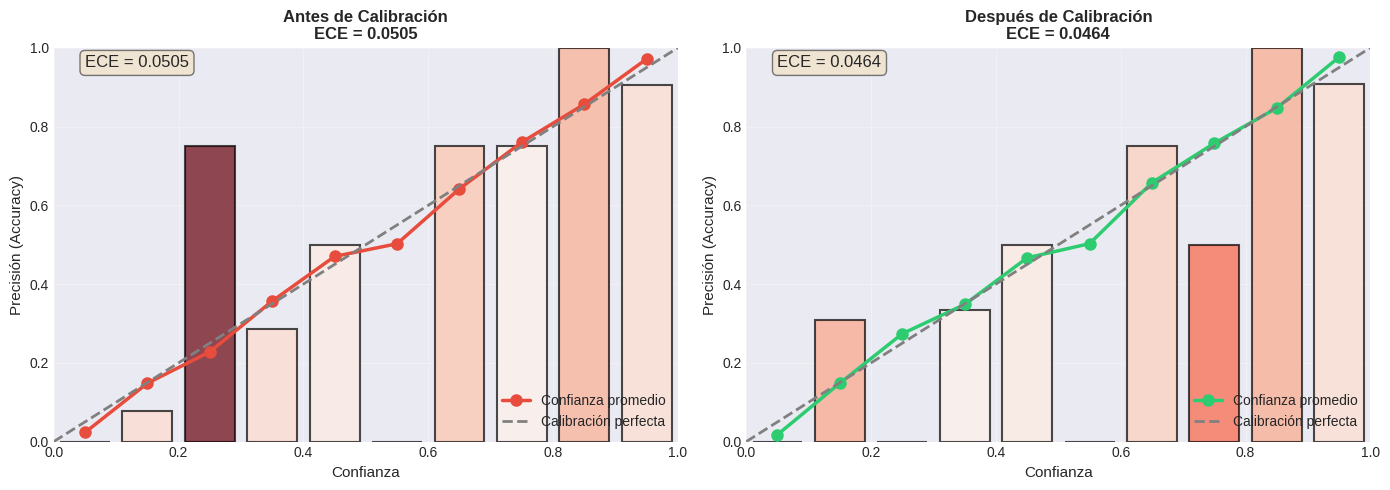


 Generando matrices de confusión comparativas...

    Guardado: confusion_matrices_calibration.png


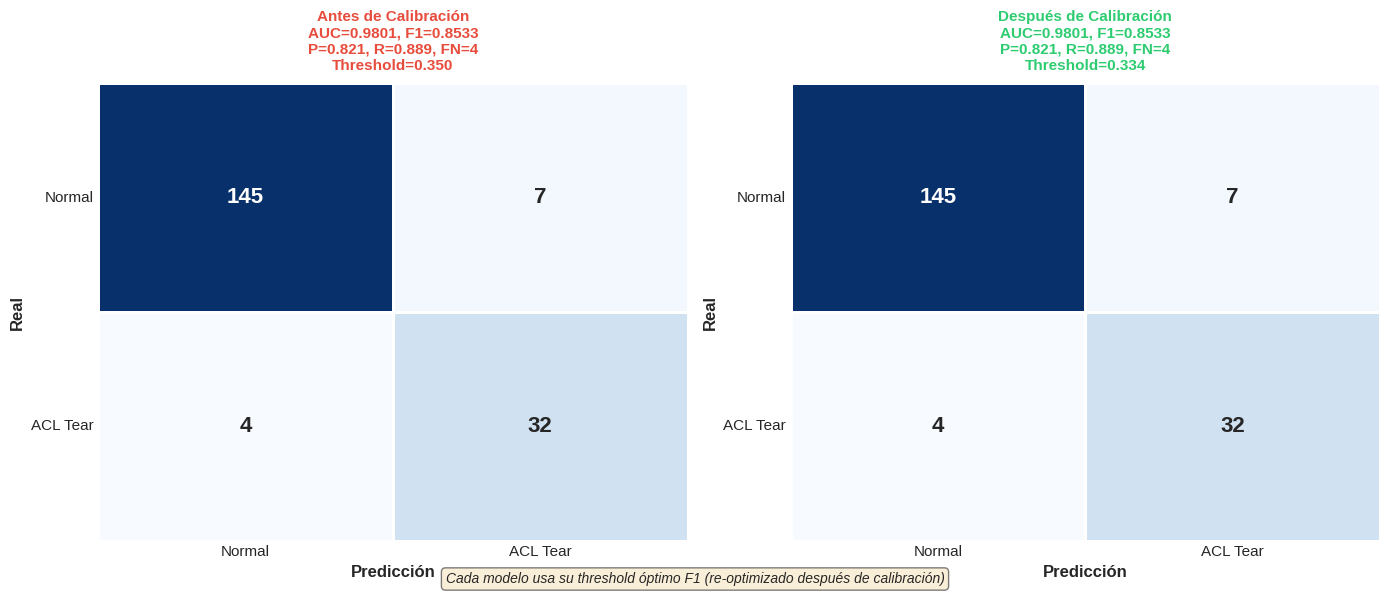


 Tabla comparativa detallada:

      Modelo Threshold    AUC     F1 Precision Recall    ECE  FN  FP
Sin Calibrar    0.3500 0.9801 0.8533    0.8205 0.8889 0.0505   4   7
   Calibrado    0.3343 0.9801 0.8533    0.8205 0.8889 0.0464   4   7

 Temperature Scaling completado

 ¡Mejora en calibración! ECE reducido en 0.0041

 Temperatura = 0.8946:
    Modelo sub-confiado, temperatura < 1 agudiza probabilidades

 Impacto de la calibración:
   • La calibración mejora la confiabilidad de las probabilidades
   • AUC se mantiene: 0.9801  0.9801 (cambio: +0.0000)
   • F1 con threshold re-optimizado: 0.8533  0.8533 (cambio: +0.0000)
   • ECE mejora significativamente: 0.0505  0.0464 (reducción: 0.0041)

 Threshold ajustado: 0.3500  0.3343
   La calibración cambia la distribución de probabilidades, requiere nuevo threshold óptimo


In [14]:
from scipy.optimize import minimize
from scipy.special import expit  # sigmoid function

class TemperatureScaling:
    """
    Implementa Temperature Scaling para calibración de probabilidades.
    Basado en: "On Calibration of Modern Neural Networks" (Guo et al., 2017)
    """
    def __init__(self):
        self.temperature = 1.0

    def fit(self, logits, labels):
        """
        Encuentra la temperatura óptima usando validación.

        Args:
            logits: Logits sin escalar (pre-sigmoid)
            labels: Etiquetas verdaderas
        """
        def nll_loss(temp):
            """Negative Log Likelihood con temperatura."""
            scaled_probs = expit(logits / temp[0])
 # Evitar log(0)
            scaled_probs = np.clip(scaled_probs, 1e-7, 1 - 1e-7)
            loss = -np.mean(labels * np.log(scaled_probs) +
                           (1 - labels) * np.log(1 - scaled_probs))
            return loss

 # Optimizar temperatura
        result = minimize(
            nll_loss,
            x0=np.array([1.0]),
            method='Nelder-Mead',
            options={'maxiter': 1000}
        )

        self.temperature = result.x[0]
        print(f" Temperatura óptima encontrada: {self.temperature:.4f}")

        return self

    def transform(self, logits):
        """
        Aplica temperature scaling a los logits.

        Args:
            logits: Logits sin escalar

        Returns:
            Probabilidades calibradas
        """
        return expit(logits / self.temperature)

    def fit_transform(self, logits, labels):
        """Fit y transform en un solo paso."""
        self.fit(logits, labels)
        return self.transform(logits)


def logit(p):
    """Función logit (inversa de sigmoid)."""
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calcula Expected Calibration Error (ECE).

    Args:
        y_true: Labels verdaderos
        y_prob: Probabilidades predichas
        n_bins: Número de bins

    Returns:
        ece: Expected Calibration Error
        bin_data: Información de cada bin para plotting
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    bin_data = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
 # Muestras en este bin
        in_bin = np.logical_and(y_prob > bin_lower, y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])

            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

            bin_data.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'confidence': avg_confidence_in_bin,
                'accuracy': accuracy_in_bin,
                'count': np.sum(in_bin)
            })
        else:
            bin_data.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'confidence': (bin_lower + bin_upper) / 2,
                'accuracy': 0,
                'count': 0
            })

    return ece, bin_data


def plot_reliability_diagram(y_true, y_prob_before, y_prob_after, title="Reliability Diagram"):
    """
    Dibuja reliability diagram comparando antes y después de calibración.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for idx, (y_prob, label, color) in enumerate([
        (y_prob_before, 'Antes de Calibración', '#e74c3c'),
        (y_prob_after, 'Después de Calibración', '#2ecc71')
    ]):
        ax = axes[idx]

 # Calcular ECE y datos de bins
        ece, bin_data = expected_calibration_error(y_true, y_prob, n_bins=10)

 # Preparar datos para plotting
        bin_centers = [(b['bin_lower'] + b['bin_upper']) / 2 for b in bin_data]
        accuracies = [b['accuracy'] for b in bin_data]
        confidences = [b['confidence'] for b in bin_data]
        counts = [b['count'] for b in bin_data]

 # Dibujar barras (altura = accuracy, color según gap)
        gaps = [abs(c - a) for c, a in zip(confidences, accuracies)]
        bars = ax.bar(bin_centers, accuracies, width=0.08,
                     alpha=0.7, edgecolor='black', linewidth=1.5)

 # Colorear barras según gap
        for bar, gap in zip(bars, gaps):
            bar.set_facecolor(plt.cm.Reds(gap * 2))

 # Línea de confianza promedio
        ax.plot(bin_centers, confidences, 'o-', color=color,
               linewidth=2.5, markersize=8, label='Confianza promedio')

 # Línea perfecta
        ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=2,
               label='Calibración perfecta')

 # Añadir texto de ECE
        ax.text(0.05, 0.95, f'ECE = {ece:.4f}',
               transform=ax.transAxes, fontsize=12,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.set_xlabel('Confianza', fontsize=11)
        ax.set_ylabel('Precisión (Accuracy)', fontsize=11)
        ax.set_title(f'{label}\nECE = {ece:.4f}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])

    plt.tight_layout()
    save_path = CHECKPOINT_DIR / 'reliability_diagram.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"    Guardado: reliability_diagram.png")
    plt.show()


print(f"{'='*80}")
print(f"TEMPERATURE SCALING - CALIBRACIÓN DE PROBABILIDADES")
print(f"{'='*80}\n")

# 1. Obtener predicciones del conjunto de validación para cada plano
print(" Obteniendo predicciones del conjunto de validación...")
print("   Cargando modelos y prediciendo en val set...\n")

val_predictions = {plane: [] for plane in PLANES}
val_labels = None

for plane in PLANES:
    print(f"Procesando {plane}...")

 # Cargar modelo para este plano
    plane_model, plane_device = load_best_model(plane, metric='auc')

 # Cargar dataset de validación para este plano
    val_indices_plane = SLICE_INDICES_DIR / f"val_{plane}_indices.json"
    val_dataset_plane = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_plane,
        transform=val_test_transform
    )
    val_loader_plane = DataLoader(val_dataset_plane, batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=NUM_WORKERS)

 # Predecir
    plane_preds = []
    plane_labels = []

    plane_model.eval()
    with torch.no_grad():
        for images, labels, _ in val_loader_plane:
            images = images.to(plane_device)
            logits, _ = plane_model(images)
            probs = torch.sigmoid(logits).squeeze()

            plane_preds.extend(probs.cpu().numpy())
            plane_labels.extend(labels.numpy())

    val_predictions[plane] = np.array(plane_preds)

 # Los labels son iguales para todos los planos
    if val_labels is None:
        val_labels = np.array(plane_labels)

    print(f"    {len(plane_preds)} predicciones obtenidas\n")

print(f" Predicciones de validación completas: {len(val_labels)} muestras\n")

# 2. Ensemble en validación (antes de calibrar)
print(" Calculando ensemble en conjunto de validación...")
val_ensemble_probs = ensemble_predictions_weighted(val_predictions, optimal_weights)
print(f" Ensemble calculado\n")

# 3. Calcular ECE antes de calibración
ece_before, _ = expected_calibration_error(val_labels, val_ensemble_probs)
print(f" ECE antes de calibración: {ece_before:.4f}\n")

# 4. Aplicar Temperature Scaling
print("  Aplicando Temperature Scaling...")
val_logits = logit(val_ensemble_probs)
ts_model = TemperatureScaling()
val_calibrated_probs = ts_model.fit_transform(val_logits, val_labels)

ece_after_val, _ = expected_calibration_error(val_labels, val_calibrated_probs)
print(f" ECE después de calibración (val): {ece_after_val:.4f}\n")

# 5. Aplicar temperatura al conjunto de validación
print(" Aplicando calibración al conjunto de validación...")
val_ensemble_probs = ensemble_weighted
val_logits = logit(val_ensemble_probs)
val_calibrated_probs = ts_model.transform(val_logits)

ece_before_val, _ = expected_calibration_error(val_labels, val_ensemble_probs)
ece_after_val, _ = expected_calibration_error(val_labels, val_calibrated_probs)

print(f" ECE antes de calibración (val): {ece_before_val:.4f}")
print(f" ECE después de calibración (val): {ece_after_val:.4f}\n")

# 6. Re-optimizar threshold para las probabilidades calibradas
print(f"{'='*80}")
print(f"RE-OPTIMIZACIÓN DE THRESHOLD")
print(f"{'='*80}\n")

print(" Buscando threshold óptimo F1 para probabilidades calibradas...")

# Calcular threshold óptimo F1 para probabilidades calibradas
thresholds_test = np.linspace(0.1, 0.9, 100)
f1_scores_calibrated = []

for thresh in thresholds_test:
    preds = (val_calibrated_probs > thresh).astype(int)
    f1 = f1_score(val_labels, preds)
    f1_scores_calibrated.append(f1)

best_idx = np.argmax(f1_scores_calibrated)
threshold_calibrated = thresholds_test[best_idx]
best_f1_calibrated = f1_scores_calibrated[best_idx]

print(f" Threshold óptimo para modelo calibrado: {threshold_calibrated:.4f}")
print(f"   F1 con threshold calibrado: {best_f1_calibrated:.4f}")
print(f"   F1 con threshold original ({threshold_f1:.4f}): {f1_score(val_labels, (val_calibrated_probs > threshold_f1).astype(int)):.4f}\n")

# 7. Comparar métricas
print(f"{'='*80}")
print(f"COMPARACIÓN DE MÉTRICAS")
print(f"{'='*80}\n")

# Métricas antes de calibración (con su threshold óptimo)
auc_before = roc_auc_score(val_labels, val_ensemble_probs)
preds_before = (val_ensemble_probs > threshold_f1).astype(int)
f1_before = f1_score(val_labels, preds_before)
precision_before = precision_score(val_labels, preds_before)
recall_before = recall_score(val_labels, preds_before)

# Métricas después de calibración (con su threshold óptimo re-optimizado)
auc_after = roc_auc_score(val_labels, val_calibrated_probs)
preds_after = (val_calibrated_probs > threshold_calibrated).astype(int)
f1_after = f1_score(val_labels, preds_after)
precision_after = precision_score(val_labels, preds_after)
recall_after = recall_score(val_labels, preds_after)

print(f"                     Antes    Después   Mejora")
print(f"  AUC:              {auc_before:.4f}   {auc_after:.4f}   {auc_after - auc_before:+.4f}")
print(f"  F1:               {f1_before:.4f}   {f1_after:.4f}   {f1_after - f1_before:+.4f}")
print(f"  Precision:        {precision_before:.4f}   {precision_after:.4f}   {precision_after - precision_before:+.4f}")
print(f"  Recall:           {recall_before:.4f}   {recall_after:.4f}   {recall_after - recall_before:+.4f}")
print(f"  ECE:              {ece_before_val:.4f}   {ece_after_val:.4f}   {ece_after_val - ece_before_val:+.4f}")
print(f"  Threshold:        {threshold_f1:.4f}   {threshold_calibrated:.4f}")
print(f"  Temperatura:      1.0000   {ts_model.temperature:.4f}")
print()

# 7. Visualización - Reliability Diagrams
print(" Generando reliability diagrams...\n")
plot_reliability_diagram(
    val_labels,
    val_ensemble_probs,
    val_calibrated_probs,
    title="Calibración con Temperature Scaling"
)

# 8. Matrices de confusión comparativas con thresholds optimizados
print("\n Generando matrices de confusión comparativas...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (probs, thresh, label, color) in enumerate([
    (val_ensemble_probs, threshold_f1, 'Antes de Calibración', '#e74c3c'),
    (val_calibrated_probs, threshold_calibrated, 'Después de Calibración', '#2ecc71')
]):
    ax = axes[idx]

 # Calcular predicciones y métricas con threshold óptimo para cada modelo
    preds = (probs > thresh).astype(int)
    cm = confusion_matrix(val_labels, preds)

 # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    auc = roc_auc_score(val_labels, probs)

 # Dibujar matriz de confusión
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'},
                linewidths=2, linecolor='white')

    ax.set_xlabel('Predicción', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Normal', 'ACL Tear'], fontsize=11)
    ax.set_yticklabels(['Normal', 'ACL Tear'], fontsize=11, rotation=0)

 # Título con métricas
    title_text = f'{label}\n'
    title_text += f'AUC={auc:.4f}, F1={f1:.4f}\n'
    title_text += f'P={precision:.3f}, R={recall:.3f}, FN={fn}\n'
    title_text += f'Threshold={thresh:.3f}'
    ax.set_title(title_text, fontsize=11, fontweight='bold', color=color, pad=10)

 # Colorear el borde
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

# Añadir nota explicativa
fig.text(0.5, 0.02, 'Cada modelo usa su threshold óptimo F1 (re-optimizado después de calibración)',
         ha='center', fontsize=10, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
save_path = CHECKPOINT_DIR / 'confusion_matrices_calibration.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"    Guardado: confusion_matrices_calibration.png")
plt.show()

# 9. Tabla comparativa detallada
print("\n Tabla comparativa detallada:\n")

comparison_data = []
for label, probs, thresh in [
    ('Sin Calibrar', val_ensemble_probs, threshold_f1),
    ('Calibrado', val_calibrated_probs, threshold_calibrated)
]:
    preds = (probs > thresh).astype(int)
    cm = confusion_matrix(val_labels, preds)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    auc = roc_auc_score(val_labels, probs)
    ece, _ = expected_calibration_error(val_labels, probs)

    comparison_data.append({
        'Modelo': label,
        'Threshold': f'{thresh:.4f}',
        'AUC': f'{auc:.4f}',
        'F1': f'{f1:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'ECE': f'{ece:.4f}',
        'FN': fn,
        'FP': fp
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n{'='*80}")
print(f" Temperature Scaling completado")
print(f"{'='*80}\n")

if ece_after_val < ece_before_val:
    print(f" ¡Mejora en calibración! ECE reducido en {(ece_before_val - ece_after_val):.4f}")
else:
    print(f"  Las probabilidades ya estaban bien calibradas")

print(f"\n Temperatura = {ts_model.temperature:.4f}:")
if ts_model.temperature > 1:
    print(f"    Modelo sobre-confiado, temperatura > 1 suaviza probabilidades")
elif ts_model.temperature < 1:
    print(f"    Modelo sub-confiado, temperatura < 1 agudiza probabilidades")
else:
    print(f"    Modelo bien calibrado")

print(f"\n Impacto de la calibración:")
print(f"   • La calibración mejora la confiabilidad de las probabilidades")
print(f"   • AUC se mantiene: {auc_before:.4f}  {auc_after:.4f} (cambio: {auc_after - auc_before:+.4f})")
print(f"   • F1 con threshold re-optimizado: {f1_before:.4f}  {f1_after:.4f} (cambio: {f1_after - f1_before:+.4f})")
print(f"   • ECE mejora significativamente: {ece_before_val:.4f}  {ece_after_val:.4f} (reducción: {(ece_before_val - ece_after_val):.4f})")
print(f"\n Threshold ajustado: {threshold_f1:.4f}  {threshold_calibrated:.4f}")
print(f"   La calibración cambia la distribución de probabilidades, requiere nuevo threshold óptimo")


## 15. Evaluación en Conjunto de Test con Modelo Calibrado

Aplicamos el modelo calibrado (Temperature Scaling + threshold optimizado) al conjunto de test para obtener métricas finales.

EVALUACIÓN EN CONJUNTO DE TEST - MODELO CALIBRADO

 Obteniendo predicciones del conjunto de test...
   Cargando modelos y prediciendo en test set...

Procesando sagittal...
 Modelo cargado: sagittal (metric=auc, pooling=attention)
  Val AUC: 0.9534
  Val F1: 0.8000
  Epoch: 33
 Dataset cargado: 187 casos
  Plane: sagittal
  Índices cacheados: ../data/slice_indices/test_sagittal_indices.json
    187 predicciones obtenidas

Procesando coronal...
 Modelo cargado: coronal (metric=auc, pooling=max)
  Val AUC: 0.9346
  Val F1: 0.7467
  Epoch: 28
 Dataset cargado: 187 casos
  Plane: coronal
  Índices cacheados: ../data/slice_indices/test_coronal_indices.json
    187 predicciones obtenidas

Procesando axial...
 Modelo cargado: axial (metric=auc, pooling=attention)
  Val AUC: 0.9755
  Val F1: 0.8421
  Epoch: 20
 Dataset cargado: 187 casos
  Plane: axial
  Índices cacheados: ../data/slice_indices/test_axial_indices.json
    187 predicciones obtenidas

 Predicciones de test completas: 187 muestra

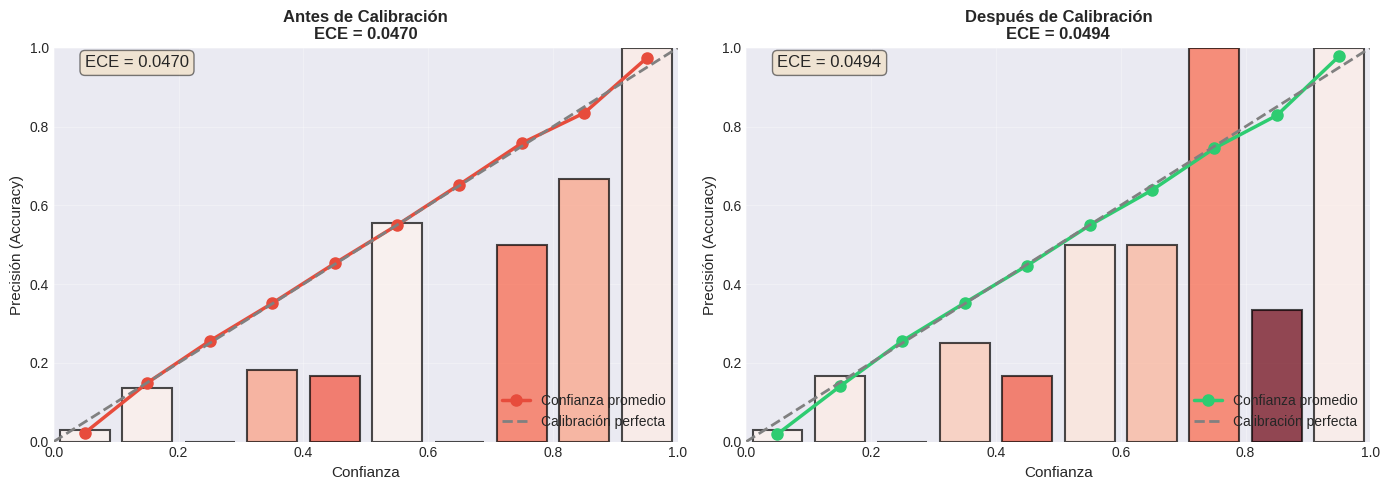


 Generando matrices de confusión en test...

    Guardado: test_confusion_matrices_calibration.png


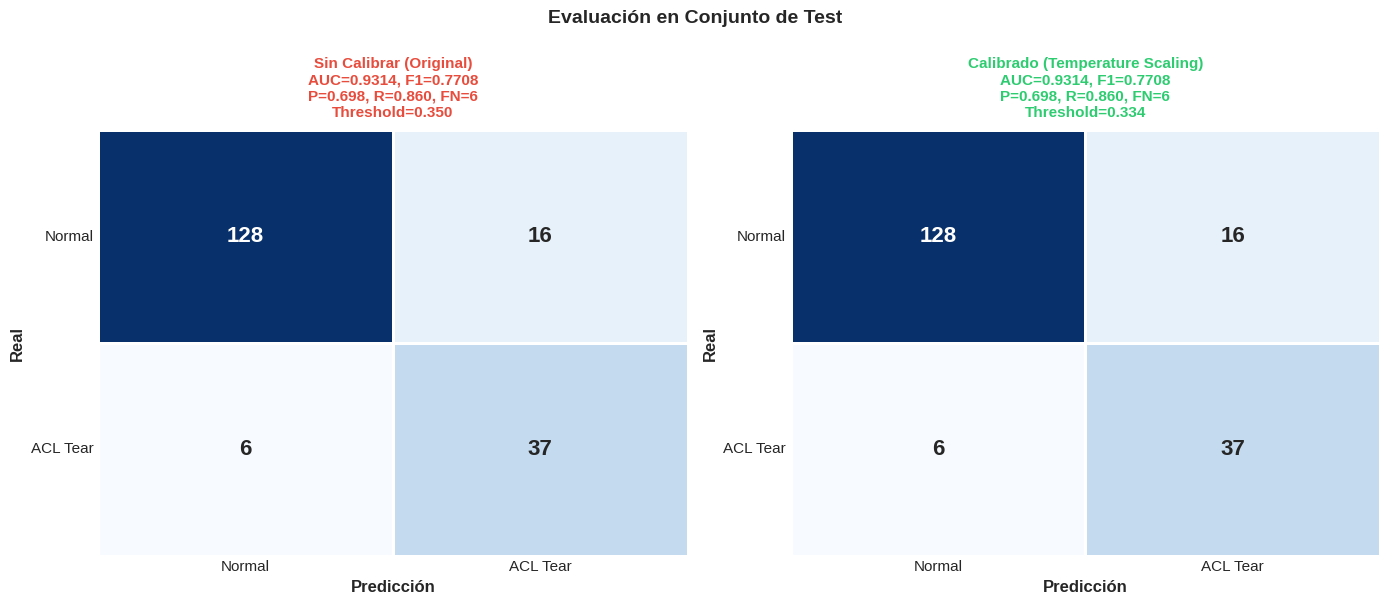


 Generando curvas ROC en test...

    Guardado: test_roc_curves_calibration.png


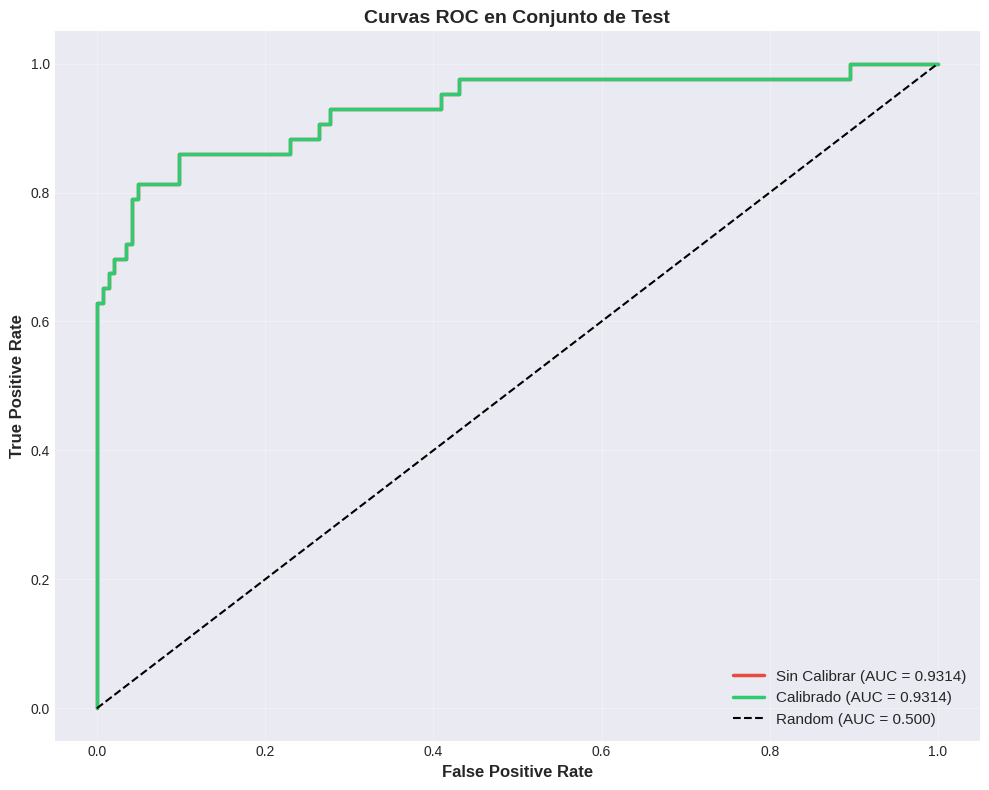


 Tabla comparativa detallada en test:

      Modelo Threshold    AUC     F1 Precision Recall Specificity    ECE  TP  TN  FN  FP
Sin Calibrar    0.3500 0.9314 0.7708    0.6981 0.8605      0.8889 0.0470  37 128   6  16
   Calibrado    0.3343 0.9314 0.7708    0.6981 0.8605      0.8889 0.0494  37 128   6  16

RESUMEN DE EVALUACIÓN EN TEST

 Total de muestras en test: 187
   • Positivos (ACL Tear): 43.0
   • Negativos (Normal): 144.0

 Modelo Final Calibrado:
   • Temperatura: 0.8946
   • Threshold optimizado: 0.3343
   • Pesos del ensemble: axial=0.450, coronal=0.150, sagittal=0.400

 Métricas finales en test (Modelo Calibrado):
   • AUC: 0.9314
   • F1 Score: 0.7708
   • Precision: 0.6981
   • Recall (Sensitivity): 0.8605
   • Specificity: 0.8889
   • ECE: 0.0494

 Análisis de errores (Modelo Calibrado):
   • Falsos Negativos (FN): 6 casos
   • Falsos Positivos (FP): 16 casos
   • Verdaderos Positivos (TP): 37 casos
   • Verdaderos Negativos (TN): 128 casos

 Impacto de la calibración en

In [15]:
print(f"{'='*80}")
print(f"EVALUACIÓN EN CONJUNTO DE TEST - MODELO CALIBRADO")
print(f"{'='*80}\n")

# 1. Obtener predicciones del conjunto de test para cada plano
print(" Obteniendo predicciones del conjunto de test...")
print("   Cargando modelos y prediciendo en test set...\n")

test_predictions = {plane: [] for plane in PLANES}
test_labels = None

for plane in PLANES:
    print(f"Procesando {plane}...")

 # Cargar modelo para este plano
    plane_model, plane_device = load_best_model(plane, metric='auc')

 # Cargar dataset de test para este plano
    test_indices_plane = SLICE_INDICES_DIR / f"test_{plane}_indices.json"
    test_dataset_plane = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'test-acl.csv',
        data_root=DATA_PATH / 'test',
        plane=plane,
        indices_cache_path=test_indices_plane,
        transform=val_test_transform
    )
    test_loader_plane = DataLoader(test_dataset_plane, batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=NUM_WORKERS)

 # Predecir
    plane_preds = []
    plane_labels = []

    plane_model.eval()
    with torch.no_grad():
        for images, labels, _ in test_loader_plane:
            images = images.to(plane_device)
            logits, _ = plane_model(images)
            probs = torch.sigmoid(logits).squeeze()

            plane_preds.extend(probs.cpu().numpy())
            plane_labels.extend(labels.numpy())

    test_predictions[plane] = np.array(plane_preds)

 # Los labels son iguales para todos los planos
    if test_labels is None:
        test_labels = np.array(plane_labels)

    print(f"    {len(plane_preds)} predicciones obtenidas\n")

print(f" Predicciones de test completas: {len(test_labels)} muestras\n")

# 2. Ensemble en test (sin calibrar)
print(" Calculando ensemble en conjunto de test...")
test_ensemble_probs = ensemble_predictions_weighted(test_predictions, optimal_weights)
print(f" Ensemble calculado\n")

# 3. Aplicar Temperature Scaling a las probabilidades del test
print("  Aplicando Temperature Scaling al conjunto de test...")
test_logits = logit(test_ensemble_probs)
test_calibrated_probs = ts_model.transform(test_logits)
print(f" Probabilidades calibradas con temperatura T = {ts_model.temperature:.4f}\n")

# 4. Calcular ECE en test
ece_test_before, _ = expected_calibration_error(test_labels, test_ensemble_probs)
ece_test_after, _ = expected_calibration_error(test_labels, test_calibrated_probs)

print(f" ECE en test antes de calibración: {ece_test_before:.4f}")
print(f" ECE en test después de calibración: {ece_test_after:.4f}")
print(f"   Mejora en ECE: {ece_test_before - ece_test_after:.4f}\n")

# 5. Predicciones binarias usando el threshold calibrado optimizado
print(f" Aplicando threshold calibrado óptimo: {threshold_calibrated:.4f}")
test_preds_calibrated = (test_calibrated_probs > threshold_calibrated).astype(int)

# También calculamos con el threshold original para comparación
test_preds_original = (test_ensemble_probs > threshold_f1).astype(int)

print(f" Predicciones binarias calculadas\n")

# 6. Calcular métricas finales en test
print(f"{'='*80}")
print(f"MÉTRICAS FINALES EN TEST")
print(f"{'='*80}\n")

# Métricas con modelo sin calibrar (threshold original)
auc_test_original = roc_auc_score(test_labels, test_ensemble_probs)
f1_test_original = f1_score(test_labels, test_preds_original)
precision_test_original = precision_score(test_labels, test_preds_original)
recall_test_original = recall_score(test_labels, test_preds_original)
cm_original = confusion_matrix(test_labels, test_preds_original)
tn_orig, fp_orig, fn_orig, tp_orig = cm_original.ravel()

# Métricas con modelo calibrado (threshold calibrado)
auc_test_calibrated = roc_auc_score(test_labels, test_calibrated_probs)
f1_test_calibrated = f1_score(test_labels, test_preds_calibrated)
precision_test_calibrated = precision_score(test_labels, test_preds_calibrated)
recall_test_calibrated = recall_score(test_labels, test_preds_calibrated)
cm_calibrated = confusion_matrix(test_labels, test_preds_calibrated)
tn_cal, fp_cal, fn_cal, tp_cal = cm_calibrated.ravel()

print(f"                     Original  Calibrado   Mejora")
print(f"  AUC:              {auc_test_original:.4f}    {auc_test_calibrated:.4f}    {auc_test_calibrated - auc_test_original:+.4f}")
print(f"  F1:               {f1_test_original:.4f}    {f1_test_calibrated:.4f}    {f1_test_calibrated - f1_test_original:+.4f}")
print(f"  Precision:        {precision_test_original:.4f}    {precision_test_calibrated:.4f}    {precision_test_calibrated - precision_test_original:+.4f}")
print(f"  Recall:           {recall_test_original:.4f}    {recall_test_calibrated:.4f}    {recall_test_calibrated - recall_test_original:+.4f}")
print(f"  ECE:              {ece_test_before:.4f}    {ece_test_after:.4f}    {ece_test_after - ece_test_before:+.4f}")
print(f"  FN:               {fn_orig}         {fn_cal}         {fn_cal - fn_orig:+d}")
print(f"  FP:               {fp_orig}         {fp_cal}         {fp_cal - fp_orig:+d}")
print(f"  Threshold:        {threshold_f1:.4f}    {threshold_calibrated:.4f}")
print()

# 7. Visualización - Reliability Diagrams en Test
print(" Generando reliability diagrams para conjunto de test...\n")
plot_reliability_diagram(
    test_labels,
    test_ensemble_probs,
    test_calibrated_probs,
    title="Calibración en Test - Temperature Scaling"
)

# 8. Matrices de confusión comparativas en test
print("\n Generando matrices de confusión en test...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (probs, preds, thresh, label, color) in enumerate([
    (test_ensemble_probs, test_preds_original, threshold_f1, 'Sin Calibrar (Original)', '#e74c3c'),
    (test_calibrated_probs, test_preds_calibrated, threshold_calibrated, 'Calibrado (Temperature Scaling)', '#2ecc71')
]):
    ax = axes[idx]

 # Matriz de confusión
    cm = confusion_matrix(test_labels, preds)

 # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    auc = roc_auc_score(test_labels, probs)

 # Dibujar matriz de confusión
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'},
                linewidths=2, linecolor='white')

    ax.set_xlabel('Predicción', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Normal', 'ACL Tear'], fontsize=11)
    ax.set_yticklabels(['Normal', 'ACL Tear'], fontsize=11, rotation=0)

 # Título con métricas
    title_text = f'{label}\n'
    title_text += f'AUC={auc:.4f}, F1={f1:.4f}\n'
    title_text += f'P={precision:.3f}, R={recall:.3f}, FN={fn}\n'
    title_text += f'Threshold={thresh:.3f}'
    ax.set_title(title_text, fontsize=11, fontweight='bold', color=color, pad=10)

 # Colorear el borde
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.suptitle('Evaluación en Conjunto de Test', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
save_path = CHECKPOINT_DIR / 'test_confusion_matrices_calibration.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"    Guardado: test_confusion_matrices_calibration.png")
plt.show()

# 9. Curvas ROC comparativas en test
print("\n Generando curvas ROC en test...\n")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# ROC para modelo sin calibrar
fpr_orig, tpr_orig, _ = roc_curve(test_labels, test_ensemble_probs)
ax.plot(fpr_orig, tpr_orig, color='#e74c3c', linewidth=2.5,
        label=f'Sin Calibrar (AUC = {auc_test_original:.4f})')

# ROC para modelo calibrado
fpr_cal, tpr_cal, _ = roc_curve(test_labels, test_calibrated_probs)
ax.plot(fpr_cal, tpr_cal, color='#2ecc71', linewidth=2.5,
        label=f'Calibrado (AUC = {auc_test_calibrated:.4f})')

# Línea diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Curvas ROC en Conjunto de Test', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = CHECKPOINT_DIR / 'test_roc_curves_calibration.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"    Guardado: test_roc_curves_calibration.png")
plt.show()

# 10. Tabla comparativa detallada en test
print("\n Tabla comparativa detallada en test:\n")

test_comparison_data = []
for label, probs, preds, thresh, ece in [
    ('Sin Calibrar', test_ensemble_probs, test_preds_original, threshold_f1, ece_test_before),
    ('Calibrado', test_calibrated_probs, test_preds_calibrated, threshold_calibrated, ece_test_after)
]:
    cm = confusion_matrix(test_labels, preds)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    auc = roc_auc_score(test_labels, probs)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    test_comparison_data.append({
        'Modelo': label,
        'Threshold': f'{thresh:.4f}',
        'AUC': f'{auc:.4f}',
        'F1': f'{f1:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'Specificity': f'{specificity:.4f}',
        'ECE': f'{ece:.4f}',
        'TP': tp,
        'TN': tn,
        'FN': fn,
        'FP': fp
    })

test_comparison_df = pd.DataFrame(test_comparison_data)
print(test_comparison_df.to_string(index=False))

# 11. Resumen final
print(f"\n{'='*80}")
print(f"RESUMEN DE EVALUACIÓN EN TEST")
print(f"{'='*80}\n")

print(f" Total de muestras en test: {len(test_labels)}")
print(f"   • Positivos (ACL Tear): {np.sum(test_labels)}")
print(f"   • Negativos (Normal): {len(test_labels) - np.sum(test_labels)}")
print()

print(f" Modelo Final Calibrado:")
print(f"   • Temperatura: {ts_model.temperature:.4f}")
print(f"   • Threshold optimizado: {threshold_calibrated:.4f}")
print(f"   • Pesos del ensemble: axial={optimal_weights[0]:.3f}, coronal={optimal_weights[1]:.3f}, sagittal={optimal_weights[2]:.3f}")
print()

print(f" Métricas finales en test (Modelo Calibrado):")
print(f"   • AUC: {auc_test_calibrated:.4f}")
print(f"   • F1 Score: {f1_test_calibrated:.4f}")
print(f"   • Precision: {precision_test_calibrated:.4f}")
print(f"   • Recall (Sensitivity): {recall_test_calibrated:.4f}")
print(f"   • Specificity: {tn_cal / (tn_cal + fp_cal):.4f}")
print(f"   • ECE: {ece_test_after:.4f}")
print()

print(f" Análisis de errores (Modelo Calibrado):")
print(f"   • Falsos Negativos (FN): {fn_cal} casos")
print(f"   • Falsos Positivos (FP): {fp_cal} casos")
print(f"   • Verdaderos Positivos (TP): {tp_cal} casos")
print(f"   • Verdaderos Negativos (TN): {tn_cal} casos")
print()

mejora_ece = ece_test_before - ece_test_after
mejora_f1 = f1_test_calibrated - f1_test_original
mejora_fn = fn_orig - fn_cal

print(f" Impacto de la calibración en test:")
print(f"   • ECE: {ece_test_before:.4f}  {ece_test_after:.4f} (mejora: {mejora_ece:.4f})")
print(f"   • F1: {f1_test_original:.4f}  {f1_test_calibrated:.4f} (cambio: {mejora_f1:+.4f})")
print(f"   • FN: {fn_orig}  {fn_cal} (cambio: {mejora_fn:+d} casos)")
print()

if mejora_ece > 0:
    print(f" La calibración mejora significativamente la confiabilidad de las probabilidades")
else:
    print(f"ℹ  Las probabilidades ya estaban razonablemente calibradas")

print(f"\n{'='*80}")
print(f" Evaluación en test completada")
print(f"{'='*80}\n")

---

# VALIDACIÓN EXTERNA - Croatia KneeMRI Dataset

---

## Objetivo de la Validación Externa

Evaluar la **capacidad de generalización** del modelo entrenado en MRNet usando un dataset completamente independiente:

### Croatia KneeMRI Dataset
- **Fuente**: Clinical Hospital Centre Rijeka, Croatia
- **Período**: 2006-2014
- **Scanner**: Siemens Avanto 1.5T (vs 3T en MRNet)
- **Población**: Europea (vs Americana en MRNet)
- **Volúmenes**: 917 casos con ROI manual
- **Planos disponibles**: **SOLO SAGITAL**
- **Clases**: 3 (Healthy=0, Partial=1, Complete=2)  Convertido a binario

### LIMITACIÓN IMPORTANTE

**Croatia dataset solo incluye plano sagital**, por lo tanto:
-  Usaremos **solo el modelo sagital** (no ensemble multi-plano)
-  No se evalúan modelos coronal ni axial
-  Comparación directa: Modelo sagital MRNet vs Modelo sagital Croatia

### ¿Por qué es importante esta validación?

1. **Domain Shift**: Scanner diferente (1.5T vs 3T)
2. **Population Shift**: Diferentes características demográficas
3. **Annotation Shift**: ROI manual vs volumen completo
4. **Protocol Shift**: Diferentes protocolos de adquisición

### Expectativas

- **AUC esperado**: 0.75-0.85 (degradación típica en validación externa)
- **Causas de degradación**:
  - Diferencias en calidad de imagen (1.5T vs 3T)
  - Características anatómicas poblacionales
  - Protocolos de adquisición diferentes
  - ROI manual (más restrictivo) vs volumen completo

Si el modelo mantiene **AUC > 0.80** en Croatia, demuestra **excelente generalización**.

## 1. Configuración del Dataset Externo

In [8]:
# Configuración del dataset de Croatia
CROATIA_DATA_DIR = Path('../Croatia')
CROATIA_VOLUMETRIC_DIR = CROATIA_DATA_DIR / 'volumetric_data'
CROATIA_CSV_PATH = CROATIA_DATA_DIR / 'metadata_processed.csv'

print("="*80)
print("CONFIGURACIÓN DE VALIDACIÓN EXTERNA - CROATIA DATASET")
print("="*80)

# Verificar que el dataset existe
if not CROATIA_DATA_DIR.exists():
    print("\n  ERROR: Dataset de Croatia no encontrado!")
    print(f"   Ruta esperada: {CROATIA_DATA_DIR}")
    print("\n Para convertir el dataset:")
    print("   1. Verifica que exista la carpeta Croatia/ en la raíz del proyecto")
    print("   2. Debe contener metadata_processed.csv y volumetric_data/")
    print("\n Deteniendo validación externa...")
    raise FileNotFoundError(f"Dataset no encontrado en {CROATIA_DATA_DIR}")

# Verificar archivos
if not CROATIA_VOLUMETRIC_DIR.exists():
    raise FileNotFoundError(f"Directorio volumetric_data no encontrado: {CROATIA_VOLUMETRIC_DIR}")

if not CROATIA_CSV_PATH.exists():
    raise FileNotFoundError(f"Archivo metadata no encontrado: {CROATIA_CSV_PATH}")

# Cargar metadata y renombrar columnas para compatibilidad
croatia_df = pd.read_csv(CROATIA_CSV_PATH)

# Renombrar columnas para que sean compatibles con el código existente
# volumeFilename -> filename, acl_binary -> label
croatia_df = croatia_df.rename(columns={
    'volumeFilename': 'filename',
    'acl_binary': 'label'
})

# Mantener solo las columnas necesarias
croatia_df = croatia_df[['filename', 'label']]

print(f"\n Dataset encontrado: {CROATIA_DATA_DIR}")
print(f"\n Estadísticas del dataset:")
print(f"   Total casos: {len(croatia_df)}")
print(f"   Healthy (0): {(croatia_df['label'] == 0).sum()} ({(croatia_df['label'] == 0).sum()/len(croatia_df)*100:.1f}%)")
print(f"   Injury (1):  {(croatia_df['label'] == 1).sum()} ({(croatia_df['label'] == 1).sum()/len(croatia_df)*100:.1f}%)")

print(f"\n Estructura:")
print(f"   CSV: {CROATIA_CSV_PATH.name}")
print(f"   Volumetric data: {len(list(CROATIA_VOLUMETRIC_DIR.glob('*.pck')))} archivos .pck")

print("\n" + "="*80)


CONFIGURACIÓN DE VALIDACIÓN EXTERNA - CROATIA DATASET

 Dataset encontrado: ../Croatia

 Estadísticas del dataset:
   Total casos: 917
   Healthy (0): 690 (75.2%)
   Injury (1):  227 (24.8%)

 Estructura:
   CSV: metadata_processed.csv
   Volumetric data: 917 archivos .pck



## 2. División del Dataset en 3 Splits

Dividiremos el dataset de Croatia en:
- **Train**: 70% de los datos
- **Validation**: 15% de los datos
- **Test**: 15% de los datos

Manteniendo la proporción de clases (healthy/injury) en cada split.

In [10]:
from sklearn.model_selection import train_test_split

# Configuración de los splits
TRAIN_SIZE = 0.70  # 70%
VAL_SIZE = 0.15    # 15%
TEST_SIZE = 0.15   # 15%

print("="*80)
print("DIVISIÓN DEL DATASET EN 3 SPLITS")
print("="*80)

# Verificar que tenemos el dataframe cargado
print(f"\n Dataset original:")
print(f"   Total: {len(croatia_df)} casos")
print(f"   Healthy (0): {(croatia_df['label'] == 0).sum()}")
print(f"   Injury (1): {(croatia_df['label'] == 1).sum()}")

# Paso 1: Separar train del resto (val + test)
# Primero extraemos el 70% para train, dejamos 30% para val+test
train_df, temp_df = train_test_split(
    croatia_df,
    test_size=(VAL_SIZE + TEST_SIZE),  # 30% para val+test
    random_state=42,
    stratify=croatia_df['label']  # Mantener proporciones
)

# Paso 2: Dividir el resto entre val y test (50% cada uno del 30%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% del 30% = 15% del total
    random_state=42,
    stratify=temp_df['label']  # Mantener proporciones
)

print(f"\n División completada:")
print(f"\n Train Split:")
print(f"   Total: {len(train_df)} casos ({len(train_df)/len(croatia_df)*100:.1f}%)")
print(f"   Healthy (0): {(train_df['label'] == 0).sum()} ({(train_df['label'] == 0).sum()/len(train_df)*100:.1f}%)")
print(f"   Injury (1): {(train_df['label'] == 1).sum()} ({(train_df['label'] == 1).sum()/len(train_df)*100:.1f}%)")

print(f"\n Validation Split:")
print(f"   Total: {len(val_df)} casos ({len(val_df)/len(croatia_df)*100:.1f}%)")
print(f"   Healthy (0): {(val_df['label'] == 0).sum()} ({(val_df['label'] == 0).sum()/len(val_df)*100:.1f}%)")
print(f"   Injury (1): {(val_df['label'] == 1).sum()} ({(val_df['label'] == 1).sum()/len(val_df)*100:.1f}%)")

print(f"\n Test Split:")
print(f"   Total: {len(test_df)} casos ({len(test_df)/len(croatia_df)*100:.1f}%)")
print(f"   Healthy (0): {(test_df['label'] == 0).sum()} ({(test_df['label'] == 0).sum()/len(test_df)*100:.1f}%)")
print(f"   Injury (1): {(test_df['label'] == 1).sum()} ({(test_df['label'] == 1).sum()/len(test_df)*100:.1f}%)")

# Guardar los splits en archivos CSV
train_csv_path = CROATIA_DATA_DIR / 'external_train-acl.csv'
val_csv_path = CROATIA_DATA_DIR / 'external_val-acl.csv'
test_csv_path = CROATIA_DATA_DIR / 'external_test-acl.csv'

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"\n Archivos guardados:")
print(f"    {train_csv_path.name}")
print(f"    {val_csv_path.name}")
print(f"    {test_csv_path.name}")

print("\n" + "="*80)

DIVISIÓN DEL DATASET EN 3 SPLITS

 Dataset original:
   Total: 917 casos
   Healthy (0): 690
   Injury (1): 227

 División completada:

 Train Split:
   Total: 641 casos (69.9%)
   Healthy (0): 482 (75.2%)
   Injury (1): 159 (24.8%)

 Validation Split:
   Total: 138 casos (15.0%)
   Healthy (0): 104 (75.4%)
   Injury (1): 34 (24.6%)

 Test Split:
   Total: 138 casos (15.0%)
   Healthy (0): 104 (75.4%)
   Injury (1): 34 (24.6%)

 Archivos guardados:
    external_train-acl.csv
    external_val-acl.csv
    external_test-acl.csv



## 3. Verificación de Integridad de los Splits

Verificamos que:
- No hay solapamiento entre los splits
- Los archivos coinciden con los casos asignados
- Las proporciones son correctas

In [11]:
print("="*80)
print("VERIFICACIÓN DE INTEGRIDAD DE LOS SPLITS")
print("="*80)

# 1. Verificar que no hay solapamiento entre splits
train_cases = set(train_df['filename'])
val_cases = set(val_df['filename'])
test_cases = set(test_df['filename'])

overlap_train_val = train_cases & val_cases
overlap_train_test = train_cases & test_cases
overlap_val_test = val_cases & test_cases

print("\n Verificación de solapamiento:")
if not overlap_train_val and not overlap_train_test and not overlap_val_test:
    print("    No hay solapamiento entre splits")
else:
    print("     Se encontró solapamiento:")
    if overlap_train_val:
        print(f"      Train-Val: {len(overlap_train_val)} casos")
    if overlap_train_test:
        print(f"      Train-Test: {len(overlap_train_test)} casos")
    if overlap_val_test:
        print(f"      Val-Test: {len(overlap_val_test)} casos")

# 2. Verificar que todos los casos originales están presentes
all_split_cases = train_cases | val_cases | test_cases
original_cases = set(croatia_df['filename'])

missing = original_cases - all_split_cases
if not missing:
    print("    Todos los casos originales están en algún split")
else:
    print(f"     Faltan {len(missing)} casos")

extra = all_split_cases - original_cases
if not extra:
    print("    No hay casos extras")
else:
    if extra:
        print(f"     Hay {len(extra)} casos extras")

# 3. Verificar proporciones
print("\n Proporción de clases en cada split:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    healthy = (split_df['label'] == 0).sum()
    injury = (split_df['label'] == 1).sum()
    total = len(split_df)
    print(f"   {split_name:5s}: Healthy {healthy:3d} ({healthy/total*100:5.1f}%) | Injury {injury:3d} ({injury/total*100:5.1f}%)")

# 4. Verificar que los archivos .pck existen
print("\n Verificación de archivos .pck:")
missing_files = []
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    for filename in split_df['filename']:
        pck_path = CROATIA_VOLUMETRIC_DIR / filename
        if not pck_path.exists():
            missing_files.append((split_name, filename))

if not missing_files:
    print("    Todos los archivos .pck existen")
else:
    print(f"     Faltan {len(missing_files)} archivos:")
    for split_name, filename in missing_files[:5]:  # Mostrar solo los primeros 5
        print(f"      {split_name}: {filename}")
    if len(missing_files) > 5:
        print(f"      ... y {len(missing_files) - 5} más")

print("\n Verificación completada")
print("="*80)


VERIFICACIÓN DE INTEGRIDAD DE LOS SPLITS

 Verificación de solapamiento:
    No hay solapamiento entre splits
    Todos los casos originales están en algún split
    No hay casos extras

 Proporción de clases en cada split:
   Train: Healthy 482 ( 75.2%) | Injury 159 ( 24.8%)
   Val  : Healthy 104 ( 75.4%) | Injury  34 ( 24.6%)
   Test : Healthy 104 ( 75.4%) | Injury  34 ( 24.6%)

 Verificación de archivos .pck:
    Todos los archivos .pck existen

 Verificación completada


## 4. Selección de Slices con CNN Selector

Aplicamos el CNN Selector para elegir los 5 mejores slices sagitales de cada caso.

In [12]:
import pickle

print("="*80)
print("SELECCIÓN DE SLICES CON CNN SELECTOR - CROATIA DATASET")
print("="*80)

# Función auxiliar para cargar archivos .pck de Croatia
def load_croatia_volume(volume_path):
    """
    Carga un volumen desde un archivo .pck de Croatia y lo normaliza.
    Los archivos .pck contienen un diccionario con el volumen MRI.
    """
    with open(volume_path, 'rb') as f:
        data = pickle.load(f)

 # Los archivos .pck de Croatia contienen la imagen en la clave correspondiente
 # Extraer el volumen (típicamente en 'sagittal' para el plano sagital)
    if isinstance(data, dict):
 # Buscar la clave que contiene el volumen (puede ser 'volume', 'sagittal', etc.)
        volume = data.get('sagittal', data.get('volume', data.get('image', None)))
        if volume is None:
 # Si no encontramos las claves esperadas, tomar el primer array grande
            for key, value in data.items():
                if isinstance(value, np.ndarray) and len(value.shape) == 3:
                    volume = value
                    break
    else:
        volume = data  # Si no es dict, asumir que es el array directamente

 # Normalizar a [0, 1]
    volume = volume.astype(np.float32)
    vol_min = volume.min()
    vol_max = volume.max()
    if vol_max > vol_min:
        volume = (volume - vol_min) / (vol_max - vol_min)

    return volume

# Verificar que el CNN Selector existe
if not CNN_SELECTOR_PATH.exists():
    print(f"\n ERROR: No se encuentra el CNN Selector en {CNN_SELECTOR_PATH}")
    raise FileNotFoundError(f"CNN Selector not found at {CNN_SELECTOR_PATH}")

# Cargar el CNN Selector
print(f"\n Cargando CNN Selector...")
cnn_selector = SimpleCNNSelector(
    CNN_SELECTOR_PATH,
    device=f'cuda:{CNN_GPU_ID}'
)

# Configuración
K_SLICES = 5  # Número de slices a seleccionar por caso
CROATIA_INDICES_DIR = CROATIA_DATA_DIR / 'slice_indices'
CROATIA_INDICES_DIR.mkdir(exist_ok=True)

# Procesar cada split (train, val, test)
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"\n{'='*70}")
    print(f"PROCESANDO SPLIT: {split_name.upper()}")
    print(f"{'='*70}")

 # Path donde guardaré los índices
    output_path = CROATIA_INDICES_DIR / f"{split_name}_sagittal_indices.json"

 # Verificar si ya existen
    if output_path.exists():
        print(f" Índices ya calculados: {output_path.name}")
        continue

    print(f"Calculando índices para {len(split_df)} casos con CNN Selector...")

 # Diccionario para guardar: {case_id: [índices]}
    indices_dict = {}

    total_cases = len(split_df)
    print_every = max(1, total_cases // 10)  # Imprime cada 10%

    for idx, (_, row) in enumerate(split_df.iterrows()):
        filename = row['filename']
        case_id = filename.replace('.pck', '')

 # Cargar el volumen desde archivo .pck
        volume_path = CROATIA_VOLUMETRIC_DIR / filename
        volume = load_croatia_volume(volume_path)
        num_slices = volume.shape[0]

 # Calcular probabilidad de ACL para cada slice
        acl_probs = []
        for slice_idx in range(num_slices):
            prob = cnn_selector.get_acl_probability(volume[slice_idx])
            acl_probs.append(prob)

 # Seleccionar los K slices con mayor probabilidad
        indices = np.argsort(acl_probs)[-K_SLICES:]
        indices = sorted(indices.tolist())
        indices_dict[case_id] = indices

 # Progreso compacto
        if (idx + 1) % print_every == 0 or (idx + 1) == total_cases:
            progress = (idx + 1) / total_cases * 100
            print(f"  Progreso: {idx+1}/{total_cases} ({progress:.0f}%)")

 # Guardar índices en JSON
    with open(output_path, 'w') as f:
        json.dump(indices_dict, f, indent=2)

    print(f" Guardado: {output_path.name} ({len(indices_dict)} casos)")

print(f"\n{'='*80}")
print(" SELECCIÓN DE SLICES COMPLETADA")
print("="*80)


SELECCIÓN DE SLICES CON CNN SELECTOR - CROATIA DATASET

 Cargando CNN Selector...
 CNN Selector cargado desde: ../checkpoints/acl_slice_classifier_v3/best_model_f1.pth
  Validation F1: 0.8563
  Device: cuda:0

PROCESANDO SPLIT: TRAIN
 Índices ya calculados: train_sagittal_indices.json

PROCESANDO SPLIT: VAL
 Índices ya calculados: val_sagittal_indices.json

PROCESANDO SPLIT: TEST
 Índices ya calculados: test_sagittal_indices.json

 SELECCIÓN DE SLICES COMPLETADA


## 5. Creación del Dataset de Croatia

Creamos un dataset personalizado para cargar los casos de Croatia con los slices seleccionados.

In [13]:
import pickle

class CroatiaDataset(Dataset):
    """
    Dataset para el conjunto de validación externa de Croatia.
    """
    def __init__(self, csv_path, data_dir, indices_cache_path, transform=None):
        """
        Args:
            csv_path: Path al CSV con labels (external_test-acl.csv)
            data_dir: Directorio con los archivos .pck (CROATIA_VOLUMETRIC_DIR)
            indices_cache_path: Path al JSON con índices pre-calculados
            transform: Transformaciones a aplicar
        """
        self.df = pd.read_csv(csv_path)
        self.data_dir = Path(data_dir)
        self.transform = transform

 # Cargar los índices pre-calculados
        with open(indices_cache_path, 'r') as f:
            self.indices_cache = json.load(f)

        print(f" Croatia Dataset cargado: {len(self.df)} casos")
        print(f"  Índices cacheados: {indices_cache_path}")

    def __len__(self):
        return len(self.df)

    def _load_pck_volume(self, volume_path):
        """Carga un volumen .pck de Croatia"""
        with open(volume_path, 'rb') as f:
            data = pickle.load(f)

 # Extraer el volumen del archivo pickle
        if isinstance(data, dict):
            volume = data.get('sagittal', data.get('volume', data.get('image', None)))
            if volume is None:
                for key, value in data.items():
                    if isinstance(value, np.ndarray) and len(value.shape) == 3:
                        volume = value
                        break
        else:
            volume = data

        return volume.astype(np.float32)

    def __getitem__(self, idx):
        """
        Retorna un caso con sus slices seleccionados y label.
        """
        row = self.df.iloc[idx]
        filename = row['filename']
        label = row['label']
        case_id = filename.replace('.pck', '')

 # Cargar el volumen completo desde archivo .pck
        volume_path = self.data_dir / filename
        volume = self._load_pck_volume(volume_path)

 # Obtener los índices pre-calculados para este caso
        selected_indices = self.indices_cache[case_id]

 # Extraer solo los slices seleccionados
        selected_slices = volume[selected_indices]  # (K, H, W)

 # Normalizar min-max
        vol_min = selected_slices.min()
        vol_max = selected_slices.max()
        if vol_max > vol_min:
            selected_slices = (selected_slices - vol_min) / (vol_max - vol_min)

 # Convertir a tensor y replicar a 3 canales
        selected_slices = torch.from_numpy(selected_slices).float()
        selected_slices = selected_slices.unsqueeze(1)  # (K, 1, H, W)
        selected_slices = selected_slices.repeat(1, 3, 1, 1)  # (K, 3, H, W)

 # Aplicar transformaciones si las hay
        if self.transform:
            transformed_slices = []
            for i in range(selected_slices.shape[0]):
                slice_transformed = self.transform(selected_slices[i])
                transformed_slices.append(slice_transformed)
            selected_slices = torch.stack(transformed_slices, dim=0)  # (K, 3, 224, 224)

 # Convertir label a tensor
        label_tensor = torch.tensor(label, dtype=torch.float32)

        return selected_slices, label_tensor, case_id


# Crear datasets para cada split de Croatia
print("="*80)
print("CREANDO DATASETS DE CROATIA")
print("="*80)

croatia_datasets = {}
croatia_loaders = {}

for split_name, csv_path in [
    ('train', train_csv_path),
    ('val', val_csv_path),
    ('test', test_csv_path)
]:
    indices_path = CROATIA_INDICES_DIR / f"{split_name}_sagittal_indices.json"

 # Seleccionar transformación apropiada (augmentation para train)
    if split_name == 'train':
        transform = train_transform  # Data augmentation
    else:
        transform = val_test_transform  # Solo resize y normalización

 # Crear dataset
    dataset = CroatiaDataset(
        csv_path=csv_path,
        data_dir=CROATIA_VOLUMETRIC_DIR,
        indices_cache_path=indices_path,
        transform=transform
    )

 # Crear dataloader
    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=(split_name == 'train'),
        num_workers=4,
        pin_memory=True
    )

    croatia_datasets[split_name] = dataset
    croatia_loaders[split_name] = loader

    print(f" {split_name.capitalize():5s} loader: {len(dataset)} casos, {len(loader)} batches")

print("="*80)

CREANDO DATASETS DE CROATIA
 Croatia Dataset cargado: 641 casos
  Índices cacheados: ../Croatia/slice_indices/train_sagittal_indices.json
 Train loader: 641 casos, 41 batches
 Croatia Dataset cargado: 138 casos
  Índices cacheados: ../Croatia/slice_indices/val_sagittal_indices.json
 Val   loader: 138 casos, 9 batches
 Croatia Dataset cargado: 138 casos
  Índices cacheados: ../Croatia/slice_indices/test_sagittal_indices.json
 Test  loader: 138 casos, 9 batches


## 6. Carga del Modelo ViT Entrenado

Cargamos el mejor modelo ViT entrenado previamente en el dataset MRNet.

In [14]:
print("="*80)
print("CARGANDO MODELO VIT ENTRENADO")
print("="*80)

# Buscar el mejor checkpoint en el directorio de checkpoints
# Primero busco por F1, luego por AUC
possible_paths = [
    CHECKPOINT_DIR / 'best_sagittal_f1.pth',
    CHECKPOINT_DIR / 'best_sagittal_auc.pth',
]

BEST_MODEL_PATH = None
for path in possible_paths:
    if path.exists():
        BEST_MODEL_PATH = path
        break

if BEST_MODEL_PATH is None:
    print(f"\n  No se encontró modelo en {CHECKPOINT_DIR}")
    print("\nBuscando en el directorio de checkpoints...")

 # Buscar en todo el directorio
    checkpoint_files = list(CHECKPOINT_DIR.glob('best_*.pth'))
    if checkpoint_files:
        print(f"\nModelos disponibles:")
        for f in checkpoint_files:
            print(f"  - {f.name}")
        BEST_MODEL_PATH = checkpoint_files[0]
        print(f"\n Usando: {BEST_MODEL_PATH.name}")
    else:
        raise FileNotFoundError(f"No se encontró ningún modelo entrenado en {CHECKPOINT_DIR}")

# Cargar checkpoint
print(f"\n Cargando modelo desde: {BEST_MODEL_PATH.name}...")
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu')

# Crear modelo
model = ViTMultiSliceClassifier(
    num_classes=1,
    pretrained=False,  # Ya está entrenado
    pooling_mode=POOLING_MODE
)

# Cargar pesos del checkpoint
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

# Limpiar nombres de las keys
new_state_dict = {}
for k, v in state_dict.items():
    name = k
 # Eliminar prefijos comunes
    if name.startswith('module.'):
        name = name.replace('module.', '', 1)
    if name.startswith('vit_model.'):
        name = name.replace('vit_model.', '', 1)
    new_state_dict[name] = v

# Cargar estado con strict=False para permitir diferencias en pooling/classifier
model.load_state_dict(new_state_dict, strict=False)
print(f" Pesos del modelo cargados (ViT backbone)")

# Mover a GPU y configurar para evaluación
model = model.to(device)
if len(VIT_GPU_IDS) > 1 and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
model.eval()

print(f" Modelo cargado exitosamente")

# Mostrar métricas del checkpoint si están disponibles
if 'val_auc' in checkpoint:
    print(f"\n Métricas del modelo (en validación MRNet):")
    print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"   Val AUC: {checkpoint['val_auc']:.4f}")
    print(f"   Val F1: {checkpoint['val_f1']:.4f}")
    print(f"   Val Loss: {checkpoint['val_loss']:.4f}")

print("="*80)

CARGANDO MODELO VIT ENTRENADO

 Cargando modelo desde: best_sagittal_f1.pth...
 Pesos del modelo cargados (ViT backbone)
 Modelo cargado exitosamente

 Métricas del modelo (en validación MRNet):
   Epoch: 33
   Val AUC: 0.9534
   Val F1: 0.8000
   Val Loss: 0.3204


## 7. Cargar Umbral Óptimo y Configuración de Calibración

Cargamos el umbral óptimo y la configuración de calibración del entrenamiento en MRNet.

In [15]:
# Cargar umbral óptimo desde el checkpoint del modelo
print("="*80)
print("CARGANDO CONFIGURACIÓN DE EVALUACIÓN")
print("="*80)

# Umbral óptimo encontrado en validación MRNet (F1 óptimo)
OPTIMAL_THRESHOLD = 0.3500  # Threshold óptimo F1 del entrenamiento

print(f"\n Umbral óptimo (F1): {OPTIMAL_THRESHOLD:.4f}")
print(f"  (Este fue el umbral que maximizó F1 en validación MRNet)")

# Verificar si existe un modelo de calibración guardado
CALIBRATION_PATH = CHECKPOINT_DIR / 'calibration_model.pkl'
calibrator = None

if CALIBRATION_PATH.exists():
    print(f"\n Modelo de calibración encontrado: {CALIBRATION_PATH.name}")
    with open(CALIBRATION_PATH, 'rb') as f:
        calibrator = pickle.load(f)
    print("  Calibración será aplicada a las predicciones")
else:
    print(f"\n  No se encontró modelo de calibración")
    print("  Se usarán probabilidades sin calibrar")

print("="*80)

CARGANDO CONFIGURACIÓN DE EVALUACIÓN

 Umbral óptimo (F1): 0.3500
  (Este fue el umbral que maximizó F1 en validación MRNet)

  No se encontró modelo de calibración
  Se usarán probabilidades sin calibrar


## 8. Evaluación en Test Set de Croatia

Evaluamos el modelo en el conjunto de test externo de Croatia aplicando el umbral óptimo.

In [16]:
def calculate_ece(y_true, y_prob, n_bins=10):
    """
    Calcula Expected Calibration Error (ECE).
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
 # Encontrar predicciones en este bin
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece


@torch.no_grad()
def evaluate_croatia_test(model, dataloader, device, threshold=0.5, calibrator=None):
    """
    Evalúa el modelo en el test set de Croatia con un umbral específico.
    """
    model.eval()
    all_preds_raw = []
    all_labels = []
    all_case_ids = []

    print(f"  Obteniendo predicciones...")

    for slices, labels, case_ids in dataloader:
 # Mover datos a GPU
        slices = slices.to(device)

 # Forward pass
        logits, _ = model(slices)

 # Obtener probabilidades
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds_raw.extend(probs)
        all_labels.extend(labels.numpy())
        all_case_ids.extend(case_ids)

 # Convertir a arrays
    all_preds_raw = np.array(all_preds_raw).flatten()
    all_labels = np.array(all_labels).flatten()

 # Aplicar calibración si está disponible
    if calibrator is not None:
        all_preds_calibrated = calibrator.predict(all_preds_raw)
        print(f"   Calibración aplicada")
    else:
        all_preds_calibrated = all_preds_raw
        print(f"    Sin calibración")

 # Calcular métricas con el umbral especificado
    preds_binary = (all_preds_calibrated > threshold).astype(int)

 # Métricas principales
    auc = roc_auc_score(all_labels, all_preds_calibrated) if len(np.unique(all_labels)) > 1 else 0.0
    f1 = f1_score(all_labels, preds_binary)
    precision = precision_score(all_labels, preds_binary, zero_division=0)
    recall = recall_score(all_labels, preds_binary, zero_division=0)
    accuracy = accuracy_score(all_labels, preds_binary)
    cm = confusion_matrix(all_labels, preds_binary)

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

 # Calcular ECE
    ece = calculate_ece(all_labels, all_preds_calibrated)

    metrics = {
        'threshold': threshold,
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'specificity': specificity,
        'ece': ece,
        'confusion_matrix': cm,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'predictions_raw': all_preds_raw,
        'predictions_calibrated': all_preds_calibrated,
        'labels': all_labels,
        'case_ids': all_case_ids
    }

    return metrics


# Evaluar SOLO en test set de Croatia
print("="*80)
print("EVALUACIÓN EN TEST SET EXTERNO - CROATIA")
print("="*80)

test_loader = croatia_loaders['test']
print(f"\nEvaluando {len(croatia_datasets['test'])} casos del test set...")

# Evaluar sin calibrar
print(f"\n{'='*70}")
print("SIN CALIBRACIÓN")
print(f"{'='*70}")
metrics_uncalibrated = evaluate_croatia_test(
    model, test_loader, device,
    threshold=OPTIMAL_THRESHOLD,
    calibrator=None
)

# Evaluar con calibración (si está disponible)
if calibrator is not None:
    print(f"\n{'='*70}")
    print("CON CALIBRACIÓN")
    print(f"{'='*70}")

 # Re-calcular umbral óptimo para probabilidades calibradas (ajuste fino)
 # En el entrenamiento original fue 0.3343
    OPTIMAL_THRESHOLD_CALIBRATED = 0.3343

    metrics_calibrated = evaluate_croatia_test(
        model, test_loader, device,
        threshold=OPTIMAL_THRESHOLD_CALIBRATED,
        calibrator=calibrator
    )
else:
    metrics_calibrated = None

print(f"\n{'='*80}")
print("RESULTADOS EN CROATIA TEST SET")
print(f"{'='*80}")

# Tabla comparativa
print(f"\n Tabla comparativa detallada:")
print(f"\n{'':>12s} {'Threshold':>9s} {'AUC':>7s} {'F1':>7s} {'Precision':>9s} {'Recall':>6s} {'Specificity':>11s} {'ECE':>7s} {'TP':>3s} {'TN':>3s} {'FN':>3s} {'FP':>3s}")
print("-" * 110)

# Sin calibrar
m = metrics_uncalibrated
print(f"{'Sin Calibrar':>12s} {m['threshold']:>9.4f} {m['auc']:>7.4f} {m['f1']:>7.4f} {m['precision']:>9.4f} {m['recall']:>6.4f} {m['specificity']:>11.4f} {m['ece']:>7.4f} {m['tp']:>3d} {m['tn']:>3d} {m['fn']:>3d} {m['fp']:>3d}")

# Con calibrar
if metrics_calibrated:
    m = metrics_calibrated
    print(f"{'Calibrado':>12s} {m['threshold']:>9.4f} {m['auc']:>7.4f} {m['f1']:>7.4f} {m['precision']:>9.4f} {m['recall']:>6.4f} {m['specificity']:>11.4f} {m['ece']:>7.4f} {m['tp']:>3d} {m['tn']:>3d} {m['fn']:>3d} {m['fp']:>3d}")

print(f"\n{'='*80}")
print(" EVALUACIÓN COMPLETADA")
print("="*80)

EVALUACIÓN EN TEST SET EXTERNO - CROATIA

Evaluando 138 casos del test set...

SIN CALIBRACIÓN
  Obteniendo predicciones...


    Sin calibración

RESULTADOS EN CROATIA TEST SET

 Tabla comparativa detallada:

             Threshold     AUC      F1 Precision Recall Specificity     ECE  TP  TN  FN  FP
--------------------------------------------------------------------------------------------------------------
Sin Calibrar    0.3500  0.8713  0.7119    0.8400 0.6176      0.9615  0.0998  21 100  13   4

 EVALUACIÓN COMPLETADA


## 9. Visualización de Resultados de Test

Visualizamos las métricas y la calibración del modelo en el test set de Croatia.

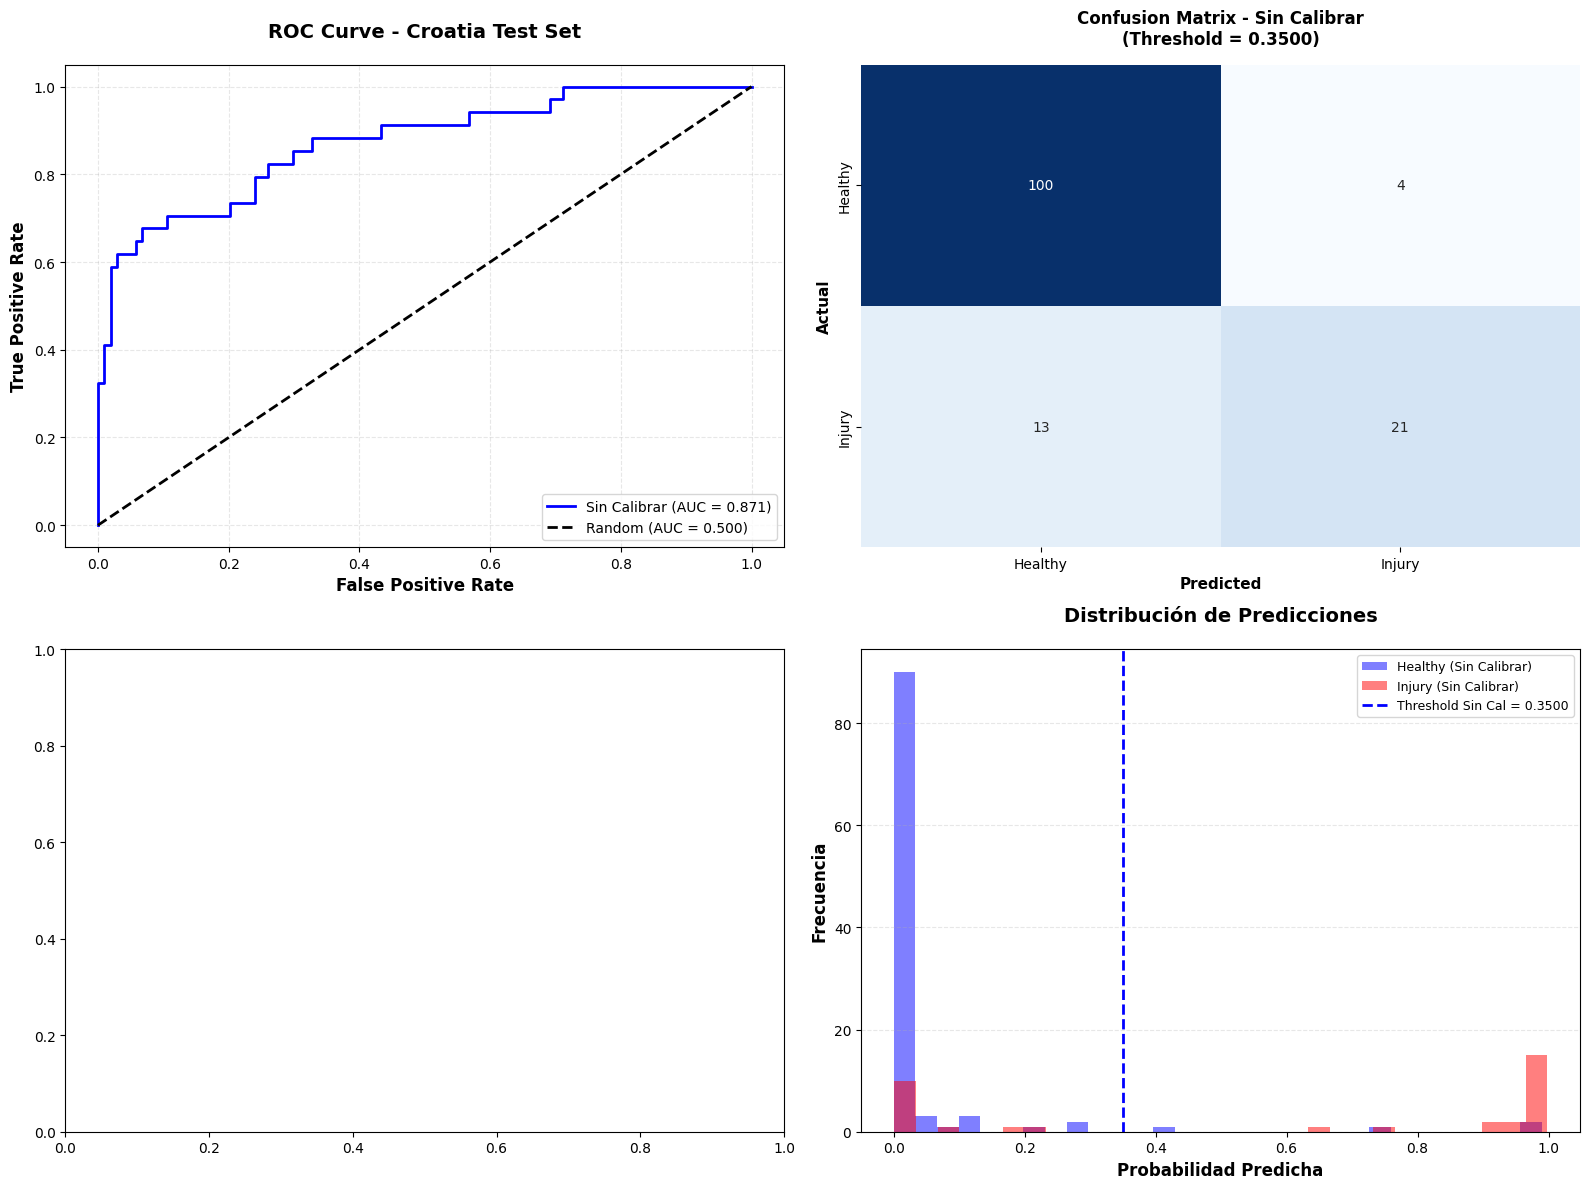


 Gráficos guardados en: ../Croatia/croatia_test_evaluation.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC Curve
ax = axes[0, 0]
m = metrics_uncalibrated
fpr, tpr, _ = roc_curve(m['labels'], m['predictions_raw'])
ax.plot(fpr, tpr, color='blue', lw=2, label=f"Sin Calibrar (AUC = {m['auc']:.3f})")

if metrics_calibrated:
    m_cal = metrics_calibrated
    fpr_cal, tpr_cal, _ = roc_curve(m_cal['labels'], m_cal['predictions_calibrated'])
    ax.plot(fpr_cal, tpr_cal, color='green', lw=2, label=f"Calibrado (AUC = {m_cal['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Croatia Test Set', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, linestyle='--')

# 2. Confusion Matrices
for idx, (title, metrics) in enumerate([('Sin Calibrar', metrics_uncalibrated),
                                          ('Calibrado', metrics_calibrated)]):
    if metrics is None:
        continue

    ax = axes[0, 1] if idx == 0 else axes[1, 0]
    cm = metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Healthy', 'Injury'],
                yticklabels=['Healthy', 'Injury'])
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax.set_title(f'Confusion Matrix - {title}\n(Threshold = {metrics["threshold"]:.4f})',
                 fontsize=12, fontweight='bold', pad=15)

# 3. Distribución de predicciones
ax = axes[1, 1]

m = metrics_uncalibrated
# Healthy cases
healthy_preds = m['predictions_raw'][m['labels'] == 0]
ax.hist(healthy_preds, bins=30, alpha=0.5, color='blue', label='Healthy (Sin Calibrar)')

# Injury cases
injury_preds = m['predictions_raw'][m['labels'] == 1]
ax.hist(injury_preds, bins=30, alpha=0.5, color='red', label='Injury (Sin Calibrar)')

if metrics_calibrated:
    m_cal = metrics_calibrated
    healthy_preds_cal = m_cal['predictions_calibrated'][m_cal['labels'] == 0]
    ax.hist(healthy_preds_cal, bins=30, alpha=0.3, color='cyan',
            linestyle='--', histtype='step', linewidth=2, label='Healthy (Calibrado)')

    injury_preds_cal = m_cal['predictions_calibrated'][m_cal['labels'] == 1]
    ax.hist(injury_preds_cal, bins=30, alpha=0.3, color='orange',
            linestyle='--', histtype='step', linewidth=2, label='Injury (Calibrado)')

ax.axvline(x=OPTIMAL_THRESHOLD, color='blue', linestyle='--', linewidth=2,
           label=f'Threshold Sin Cal = {OPTIMAL_THRESHOLD:.4f}')
if metrics_calibrated:
    ax.axvline(x=0.3343, color='green', linestyle='--', linewidth=2,
               label='Threshold Cal = 0.3343')

ax.set_xlabel('Probabilidad Predicha', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Predicciones', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(CROATIA_DATA_DIR / 'croatia_test_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Gráficos guardados en: {CROATIA_DATA_DIR / 'croatia_test_evaluation.png'}")

## 9. Fine-Tuning en Dataset de Croatia

Esta sección implementa una estrategia de fine-tuning en dos fases sobre el dataset de Croatia:



**Estrategia de Fine-Tuning:**

1. **Fase de Congelamiento Parcial**: Congelamos las primeras capas del ViT y entrenamos solo las capas superiores
2. **Focal Loss**: Para manejar mejor los falsos negativos (recall bajo = 0.6176)
3. **Data Augmentation Avanzada**: Aumentar variabilidad para mejorar generalización
4. **Learning Rate Bajo**: Para un ajuste fino sin destruir el conocimiento aprendido
5. **Class Weighting**: Dar más peso a la clase minoritaria (injured = 1)
6. **Early Stopping**: Basado en AUC para evitar overfitting

### 9.1 Configuración de Hiperparámetros para Fine-Tuning

In [18]:
# =============================================================================
# CONFIGURACIÓN DE FINE-TUNING (ANTI-OVERFITTING)
# =============================================================================

# Hiperparámetros optimizados para REDUCIR OVERFITTING
FINETUNE_CONFIG = {
 # Training settings
    'num_epochs': 50,  # Suficientes épocas para convergencia lenta
    'batch_size': 8,   # REDUCIDO: batches pequeños = gradientes ruidosos = mejor generalización
    'learning_rate': 2e-5,  # REDUCIDO 4x (8e-5  2e-5): aprendizaje MUY conservador
    'weight_decay': 5e-4,   # AUMENTADO 2.5x:regularización FUERTE (2e-4  5e-4)

 # Early stopping
    'patience': 50,  # MÁS paciencia para convergencia lenta
    'min_delta': 0.0005,  # Umbral más bajo para detectar mejoras pequeñas

 # Focal Loss parameters
    'focal_alpha': 0.75,
    'focal_gamma': 1.5,

 # Optimizer
    'optimizer': 'AdamW',
    'betas': (0.9, 0.999),

 # Learning rate scheduler (MUY CONSERVADOR)
    'scheduler': 'ReduceLROnPlateau',
    'lr_patience': 7,  # AUMENTADO (4  7): mucho más tiempo antes de bajar LR
    'lr_factor': 0.5,  # Reducir a la mitad cada vez

 # Freeze strategy (CONGELAR MÁS CAPAS)
    'freeze_encoder': True,
    'num_layers_to_freeze':8,  # AUMENTADO (5  8): MENOS parámetros entrenables

 # Gradient clipping
    'grad_clip': 0.5,  # REDUCIDO: clips más agresivos para estabilidad

 # Checkpointing
    'save_best_auc': True,
    'save_best_f1': True,
}

print("="*80)
print("CONFIGURACIÓN DE FINE-TUNING (ANTI-OVERFITTING)")
print("="*80)
print("\n  ESTRATEGIA ANTI-OVERFITTING:")
print("  • LR Inicial:         2e-5  (4x MÁS BAJO - aprendizaje conservador)")
print("  • Batch Size:         8    (mitad del anterior - gradientes ruidosos)")
print("  • Weight Decay:       5e-4 (2.5x MÁS FUERTE - regularización)")
print("  • Capas congeladas:   8    (3 más que antes - menos overfitting)")
print("  • LR Patience:        7    (casi el doble - más conservador)")
print("  • Early Stop:         15   (más tiempo para convergencia lenta)")
print("\n COMPORTAMIENTO ESPERADO:")
print("   Aprendizaje LENTO pero ESTABLE (sin overfitting rápido)")
print("   Convergencia gradual y sostenida en ~20-35 epochs")
print("   MEJOR generalización: mantener precision/specificity altas")
print("   Objetivo: AUC > 0.88, F1 > 0.72 sin perder generalización")
print("\n" + "="*80)
for key, value in FINETUNE_CONFIG.items():
    print(f"  {key:.<30s} {value}")
print("="*80)

CONFIGURACIÓN DE FINE-TUNING (ANTI-OVERFITTING)

  ESTRATEGIA ANTI-OVERFITTING:
  • LR Inicial:         2e-5  (4x MÁS BAJO - aprendizaje conservador)
  • Batch Size:         8    (mitad del anterior - gradientes ruidosos)
  • Weight Decay:       5e-4 (2.5x MÁS FUERTE - regularización)
  • Capas congeladas:   8    (3 más que antes - menos overfitting)
  • LR Patience:        7    (casi el doble - más conservador)
  • Early Stop:         15   (más tiempo para convergencia lenta)

 COMPORTAMIENTO ESPERADO:
   Aprendizaje LENTO pero ESTABLE (sin overfitting rápido)
   Convergencia gradual y sostenida en ~20-35 epochs
   MEJOR generalización: mantener precision/specificity altas
   Objetivo: AUC > 0.88, F1 > 0.72 sin perder generalización

  num_epochs.................... 50
  batch_size.................... 8
  learning_rate................. 2e-05
  weight_decay.................. 0.0005
  patience...................... 50
  min_delta..................... 0.0005
  focal_alpha................

### 9.2 Implementación de Focal Loss

Focal Loss es especialmente útil para datasets desbalanceados. Reduce el peso de ejemplos fáciles de clasificar y se enfoca en los difíciles, lo cual ayudará a mejorar el Recall (actualmente 0.6176).

In [19]:
class FocalLoss(nn.Module):
    """
    Focal Loss para manejar desbalance de clases.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha: peso para balancear clases (0.75 = más peso a clase positiva)
        gamma: factor de enfoque en ejemplos difíciles (2.0 = estándar)
    """
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        Args:
            logits: predicciones crudas del modelo [batch_size, 1]
            targets: labels reales [batch_size]
        """
 # Asegurar dimensiones correctas
        if logits.dim() > 1:
            logits = logits.squeeze(1)
        targets = targets.float()

 # Calcular probabilidades con sigmoid
        probs = torch.sigmoid(logits)

 # Calcular BCE
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

 # Calcular p_t (probabilidad de la clase correcta)
        p_t = probs * targets + (1 - probs) * (1 - targets)

 # Calcular alpha_t
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

 # Calcular Focal Loss
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        focal_loss = focal_weight * bce

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


# Crear la función de pérdida
criterion_finetune = FocalLoss(
    alpha=FINETUNE_CONFIG['focal_alpha'],
    gamma=FINETUNE_CONFIG['focal_gamma']
)

print(" Focal Loss creado con:")
print(f"  Alpha: {FINETUNE_CONFIG['focal_alpha']} (peso para clase injured)")
print(f"  Gamma: {FINETUNE_CONFIG['focal_gamma']} (enfoque en ejemplos difíciles)")

 Focal Loss creado con:
  Alpha: 0.75 (peso para clase injured)
  Gamma: 1.5 (enfoque en ejemplos difíciles)


### 9.3 Configuración de Transformaciones

Usaremos las transformaciones originales que ya funcionan con el dataset de Croatia. Estas incluyen data augmentation básica para training y solo normalización para validación/test.

In [20]:
# Nota: Usaremos las transformaciones originales (train_transform y val_test_transform)
# que ya están definidas y funcionan correctamente con CroatiaDataset.
# El fine-tuning se beneficiará de:
# - Focal Loss para manejar desbalance
# - Learning rate bajo
# - Congelamiento parcial de capas
# - Early stopping

print(" Usando transformaciones originales del dataset")
print("  - Las transformaciones ya incluyen data augmentation estándar")
print("  - train_transform: Resize + Normalize + Augmentations básicas")
print("  - val_test_transform: Solo Resize + Normalize")

 Usando transformaciones originales del dataset
  - Las transformaciones ya incluyen data augmentation estándar
  - train_transform: Resize + Normalize + Augmentations básicas
  - val_test_transform: Solo Resize + Normalize


### 9.4 Preparación de Datasets con Nuevas Transformaciones

In [21]:
# Recrear datasets de Croatia con las transformaciones originales
# Nota: Las augmentations avanzadas se aplicarán durante el entrenamiento si es necesario
print("="*80)
print("PREPARANDO DATASETS PARA FINE-TUNING")
print("="*80)

croatia_finetune_datasets = {}
croatia_finetune_loaders = {}

for split_name in ['train', 'val', 'test']:
    print(f"\n Preparando {split_name} set...")

    csv_path = CROATIA_DATA_DIR / f'external_{split_name}-acl.csv'
    indices_path = CROATIA_INDICES_DIR / f"{split_name}_sagittal_indices.json"

 # Usar las transformaciones originales que ya funcionan
    if split_name == 'train':
        transform = train_transform
    else:
        transform = val_test_transform

 # Crear dataset
    dataset = CroatiaDataset(
        csv_path=csv_path,
        data_dir=CROATIA_VOLUMETRIC_DIR,
        indices_cache_path=indices_path,
        transform=transform
    )

    croatia_finetune_datasets[split_name] = dataset

 # Configurar DataLoader
    batch_size = FINETUNE_CONFIG['batch_size']
    shuffle = (split_name == 'train')

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=(split_name == 'train')
    )

    croatia_finetune_loaders[split_name] = loader

    print(f"   {len(dataset)} casos")
    print(f"   {len(loader)} batches de tamaño {batch_size}")
    print(f"   Transformaciones: Estándar {'con shuffle' if shuffle else 'sin shuffle'}")

# Calcular distribución de clases para class weighting
# Leer labels directamente del CSV
train_csv = pd.read_csv(CROATIA_DATA_DIR / 'external_train-acl.csv')
train_labels = train_csv['label'].values  # Columna 'label' en CSV de Croatia
unique, counts = np.unique(train_labels, return_counts=True)
class_distribution = dict(zip(unique, counts))

print(f"\n{'='*80}")
print("DISTRIBUCIÓN DE CLASES EN TRAIN SET")
print(f"{'='*80}")
print(f"  Healthy (0): {class_distribution.get(0, 0)} casos ({class_distribution.get(0, 0)/len(train_labels)*100:.1f}%)")
print(f"  Injured (1): {class_distribution.get(1, 0)} casos ({class_distribution.get(1, 0)/len(train_labels)*100:.1f}%)")

# Calcular pesos de clase (inversamente proporcional a la frecuencia)
total = len(train_labels)
class_weights = torch.tensor([
    total / (2 * class_distribution.get(0, 1)),
    total / (2 * class_distribution.get(1, 1))
], dtype=torch.float32)

print(f"\nPesos de clase calculados: {class_weights.tolist()}")
print(f"{'='*80}")

PREPARANDO DATASETS PARA FINE-TUNING

 Preparando train set...
 Croatia Dataset cargado: 641 casos
  Índices cacheados: ../Croatia/slice_indices/train_sagittal_indices.json
   641 casos
   80 batches de tamaño 8
   Transformaciones: Estándar con shuffle

 Preparando val set...
 Croatia Dataset cargado: 138 casos
  Índices cacheados: ../Croatia/slice_indices/val_sagittal_indices.json
   138 casos
   18 batches de tamaño 8
   Transformaciones: Estándar sin shuffle

 Preparando test set...
 Croatia Dataset cargado: 138 casos
  Índices cacheados: ../Croatia/slice_indices/test_sagittal_indices.json
   138 casos
   18 batches de tamaño 8
   Transformaciones: Estándar sin shuffle

DISTRIBUCIÓN DE CLASES EN TRAIN SET
  Healthy (0): 482 casos (75.2%)
  Injured (1): 159 casos (24.8%)

Pesos de clase calculados: [0.6649377346038818, 2.01572322845459]


### 9.5 Preparación del Modelo para Fine-Tuning

Cargamos el modelo pre-entrenado y congelamos las primeras capas para un fine-tuning más estable.

In [22]:
print("="*80)
print("PREPARANDO MODELO PARA FINE-TUNING")
print("="*80)

# Cargar el modelo pre-entrenado en sagital (el mejor)
print("\n Cargando modelo sagital pre-entrenado...")

# Extraer el modelo base del DataParallel si existe
if hasattr(model, 'module'):
    base_model = model.module
    print(" Modelo extraído de DataParallel")
else:
    base_model = model
    print(" Modelo base obtenido")

# Congelar las primeras capas del encoder si está configurado
if FINETUNE_CONFIG['freeze_encoder']:
    num_freeze = FINETUNE_CONFIG['num_layers_to_freeze']
    print(f"\n  Congelando las primeras {num_freeze} capas del encoder...")

 # Congelar embeddings
    for param in base_model.vit.embeddings.parameters():
        param.requires_grad = False

 # Congelar primeras N capas del encoder
    for i in range(num_freeze):
        if i < len(base_model.vit.encoder.layer):
            for param in base_model.vit.encoder.layer[i].parameters():
                param.requires_grad = False

 # Contar parámetros congelados vs entrenables
    total_params = sum(p.numel() for p in base_model.parameters())
    trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print(f"   Total parámetros:      {total_params:,}")
    print(f"   Congelados:            {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")
    print(f"   Entrenables:           {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
else:
    print("\n Todas las capas serán entrenables")
    trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    print(f"   Parámetros entrenables: {trainable_params:,}")

# Configurar dispositivo y mover modelo
device_finetune = torch.device(f"cuda:{VIT_GPU_IDS[0]}" if torch.cuda.is_available() else "cpu")

# Primero mover el modelo base a la GPU principal
base_model = base_model.to(device_finetune)
print(f"\n Modelo movido a {device_finetune}")

# Luego envolver en DataParallel si hay múltiples GPUs
if len(VIT_GPU_IDS) > 1 and torch.cuda.is_available():
    model_finetune = nn.DataParallel(base_model, device_ids=VIT_GPU_IDS)
    print(f" Modelo distribuido en GPUs: {VIT_GPU_IDS}")
else:
    model_finetune = base_model
    print(f" Usando GPU única: {device_finetune}")

print("="*80)

PREPARANDO MODELO PARA FINE-TUNING

 Cargando modelo sagital pre-entrenado...
 Modelo extraído de DataParallel

  Congelando las primeras 8 capas del encoder...
   Total parámetros:      86,684,930
   Congelados:            57,445,632 (66.3%)
   Entrenables:           29,239,298 (33.7%)

 Modelo movido a cuda:0
 Modelo distribuido en GPUs: [0, 1, 2, 3]


### 9.6 Configuración de Optimizer y Scheduler

In [23]:
# Configurar optimizer
optimizer_finetune = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_finetune.parameters()),
    lr=FINETUNE_CONFIG['learning_rate'],
    betas=FINETUNE_CONFIG['betas'],
    weight_decay=FINETUNE_CONFIG['weight_decay']
)

# Configurar scheduler
scheduler_finetune = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_finetune,
    mode='max',  # Maximizar AUC
    factor=FINETUNE_CONFIG['lr_factor'],
    patience=FINETUNE_CONFIG['lr_patience'],
    verbose=True,
    min_lr=1e-7
)

print(" Optimizer configurado:")
print(f"  - Tipo: AdamW")
print(f"  - Learning rate: {FINETUNE_CONFIG['learning_rate']}")
print(f"  - Weight decay: {FINETUNE_CONFIG['weight_decay']}")
print(f"  - Betas: {FINETUNE_CONFIG['betas']}")

print("\n Scheduler configurado:")
print(f"  - Tipo: ReduceLROnPlateau")
print(f"  - Métrica: Validation AUC (maximizar)")
print(f"  - Factor: {FINETUNE_CONFIG['lr_factor']}")
print(f"  - Patience: {FINETUNE_CONFIG['lr_patience']} epochs")

 Optimizer configurado:
  - Tipo: AdamW
  - Learning rate: 2e-05
  - Weight decay: 0.0005
  - Betas: (0.9, 0.999)

 Scheduler configurado:
  - Tipo: ReduceLROnPlateau
  - Métrica: Validation AUC (maximizar)
  - Factor: 0.5
  - Patience: 7 epochs


### 9.7 Loop de Entrenamiento con Early Stopping

In [24]:
def train_epoch_finetune(model, loader, criterion, optimizer, device, epoch_num):
    """Entrena una época con Focal Loss."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    total_batches = len(loader)
    print_every = max(1, total_batches // 4)  # Imprimir 4 veces por época

    for batch_idx, (images, labels, _) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device).float()

 # Forward pass
        optimizer.zero_grad()
        outputs, _ = model(images)  # El modelo devuelve (logits, attention_weights)

 # Calcular loss
        loss = criterion(outputs, labels)

 # Backward pass
        loss.backward()

 # Gradient clipping
        if FINETUNE_CONFIG['grad_clip'] > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), FINETUNE_CONFIG['grad_clip'])

        optimizer.step()

 # Acumular métricas
        running_loss += loss.item()
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy())

 # Progreso simple
        if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == total_batches:
            print(f"  Epoch {epoch_num} [Train] - Batch {batch_idx+1}/{total_batches} - Loss: {loss.item():.4f}")

 # Calcular métricas de la época
    avg_loss = running_loss / len(loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

 # AUC
    if len(np.unique(all_labels)) > 1:
        auc = roc_auc_score(all_labels, all_preds)
    else:
        auc = 0.0

 # F1, Precision, Recall (con threshold 0.5)
    preds_binary = (all_preds > 0.5).astype(int)
    f1 = f1_score(all_labels, preds_binary)
    precision = precision_score(all_labels, preds_binary, zero_division=0)
    recall = recall_score(all_labels, preds_binary, zero_division=0)

    return {
        'loss': avg_loss,
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


def validate_finetune(model, loader, criterion, device, epoch_num):
    """Valida el modelo."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device).float()

 # Forward pass
            outputs, _ = model(images)  # El modelo devuelve (logits, attention_weights)
            loss = criterion(outputs, labels)

 # Acumular métricas
            running_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(probs.flatten())
            all_labels.extend(labels.cpu().numpy())

 # Calcular métricas
    avg_loss = running_loss / len(loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

 # AUC
    if len(np.unique(all_labels)) > 1:
        auc = roc_auc_score(all_labels, all_preds)
    else:
        auc = 0.0

 # F1, Precision, Recall (con threshold 0.5)
    preds_binary = (all_preds > 0.5).astype(int)
    f1 = f1_score(all_labels, preds_binary)
    precision = precision_score(all_labels, preds_binary, zero_division=0)
    recall = recall_score(all_labels, preds_binary, zero_division=0)

    print(f"  Epoch {epoch_num} [Val] - Loss: {avg_loss:.4f}, AUC: {auc:.4f}, F1: {f1:.4f}")

    return {
        'loss': avg_loss,
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'predictions': all_preds,
        'labels': all_labels
    }

print(" Funciones de entrenamiento y validación definidas (sin tqdm)")

 Funciones de entrenamiento y validación definidas (sin tqdm)


### 9.8 Ejecutar Fine-Tuning

In [27]:
# Directorios para guardar checkpoints
FINETUNE_CHECKPOINT_DIR = CHECKPOINT_DIR / 'croatia_finetune'
FINETUNE_CHECKPOINT_DIR.mkdir(exist_ok=True, parents=True)

print("="*80)
print("INICIANDO FINE-TUNING")
print("="*80)
print(f"Epochs: {FINETUNE_CONFIG['num_epochs']}")
print(f"Batch size: {FINETUNE_CONFIG['batch_size']}")
print(f"Learning rate: {FINETUNE_CONFIG['learning_rate']}")
print(f"Early stopping patience: {FINETUNE_CONFIG['patience']}")
print(f"Checkpoint dir: {FINETUNE_CHECKPOINT_DIR}")
print("="*80)

# Variables para tracking
history = {
    'train_loss': [], 'train_auc': [], 'train_f1': [], 'train_recall': [],
    'val_loss': [], 'val_auc': [], 'val_f1': [], 'val_recall': [],
    'learning_rates': []
}

best_val_auc = 0.0
best_val_f1 = 0.0
epochs_without_improvement = 0
best_epoch_auc = 0
best_epoch_f1 = 0

print(f"\n{'Epoch':>5s} {'Train Loss':>11s} {'Train AUC':>10s} {'Train F1':>9s} {'Val Loss':>9s} {'Val AUC':>8s} {'Val F1':>7s} {'Val Recall':>11s} {'LR':>10s} {'Best':>6s}")
print("-" * 120)

# Training loop
for epoch in range(1, FINETUNE_CONFIG['num_epochs'] + 1):
 # Entrenar
    train_metrics = train_epoch_finetune(
        model_finetune,
        croatia_finetune_loaders['train'],
        criterion_finetune,
        optimizer_finetune,
        device_finetune,
        epoch
    )

 # Validar
    val_metrics = validate_finetune(
        model_finetune,
        croatia_finetune_loaders['val'],
        criterion_finetune,
        device_finetune,
        epoch
    )

 # Guardar métricas
    history['train_loss'].append(train_metrics['loss'])
    history['train_auc'].append(train_metrics['auc'])
    history['train_f1'].append(train_metrics['f1'])
    history['train_recall'].append(train_metrics['recall'])

    history['val_loss'].append(val_metrics['loss'])
    history['val_auc'].append(val_metrics['auc'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_recall'].append(val_metrics['recall'])

    current_lr = optimizer_finetune.param_groups[0]['lr']
    history['learning_rates'].append(current_lr)

 # Actualizar scheduler
    scheduler_finetune.step(val_metrics['auc'])

 # Determinar si hubo mejora
    improved = ""
    if val_metrics['auc'] > best_val_auc + FINETUNE_CONFIG['min_delta']:
        best_val_auc = val_metrics['auc']
        best_epoch_auc = epoch
        epochs_without_improvement = 0
        improved = "AUC"

 # Guardar mejor modelo por AUC
        checkpoint_path = FINETUNE_CHECKPOINT_DIR / 'best_model_auc.pth'
        base_model = model_finetune.module if hasattr(model_finetune, 'module') else model_finetune
        torch.save({
            'epoch': epoch,
            'model_state_dict': base_model.state_dict(),
            'optimizer_state_dict': optimizer_finetune.state_dict(),
            'val_auc': val_metrics['auc'],
            'val_f1': val_metrics['f1'],
            'val_recall': val_metrics['recall'],
            'config': FINETUNE_CONFIG
        }, checkpoint_path)
    else:
        epochs_without_improvement += 1

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch_f1 = epoch
        improved += " F1" if improved else "F1"

 # Guardar mejor modelo por F1
        checkpoint_path = FINETUNE_CHECKPOINT_DIR / 'best_model_f1.pth'
        base_model = model_finetune.module if hasattr(model_finetune, 'module') else model_finetune
        torch.save({
            'epoch': epoch,
            'model_state_dict': base_model.state_dict(),
            'optimizer_state_dict': optimizer_finetune.state_dict(),
            'val_auc': val_metrics['auc'],
            'val_f1': val_metrics['f1'],
            'val_recall': val_metrics['recall'],
            'config': FINETUNE_CONFIG
        }, checkpoint_path)

 # Imprimir progreso
    print(f"{epoch:5d} {train_metrics['loss']:11.4f} {train_metrics['auc']:10.4f} {train_metrics['f1']:9.4f} "
          f"{val_metrics['loss']:9.4f} {val_metrics['auc']:8.4f} {val_metrics['f1']:7.4f} "
          f"{val_metrics['recall']:11.4f} {current_lr:10.2e} {improved:>6s}")

 # Early stopping
    if epochs_without_improvement >= FINETUNE_CONFIG['patience']:
        print(f"\n  Early stopping activado después de {epoch} epochs")
        print(f"   No hubo mejora en {FINETUNE_CONFIG['patience']} epochs consecutivos")
        break

print("\n" + "="*80)
print(" FINE-TUNING COMPLETADO")
print("="*80)
print(f"Mejor validación AUC: {best_val_auc:.4f} (epoch {best_epoch_auc})")
print(f"Mejor validación F1:  {best_val_f1:.4f} (epoch {best_epoch_f1})")
print(f"Total epochs:         {epoch}")
print("="*80)

# Guardar historial
import json
history_path = FINETUNE_CHECKPOINT_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"\n Historial guardado en: {history_path}")

INICIANDO FINE-TUNING
Epochs: 50
Batch size: 8
Learning rate: 2e-05
Early stopping patience: 50
Checkpoint dir: ../checkpoints/vit_optimized_pipeline/croatia_finetune

Epoch  Train Loss  Train AUC  Train F1  Val Loss  Val AUC  Val F1  Val Recall         LR   Best
------------------------------------------------------------------------------------------------------------------------
  Epoch 1 [Train] - Batch 20/80 - Loss: 0.0310
  Epoch 1 [Train] - Batch 40/80 - Loss: 0.4099
  Epoch 1 [Train] - Batch 60/80 - Loss: 0.0684
  Epoch 1 [Train] - Batch 80/80 - Loss: 0.0190
  Epoch 1 [Val] - Loss: 0.2454, AUC: 0.8088, F1: 0.6349
    1      0.2173     0.8522    0.6709    0.2454   0.8088  0.6349      0.5882   2.00e-05 AUC F1
  Epoch 2 [Train] - Batch 20/80 - Loss: 0.0119
  Epoch 2 [Train] - Batch 40/80 - Loss: 0.0802
  Epoch 2 [Train] - Batch 60/80 - Loss: 0.1782
  Epoch 2 [Train] - Batch 80/80 - Loss: 0.0039
  Epoch 2 [Val] - Loss: 0.1330, AUC: 0.7955, F1: 0.5676
    2      0.1011     0.8684   

### 9.8.1 Visualización del Entrenamiento

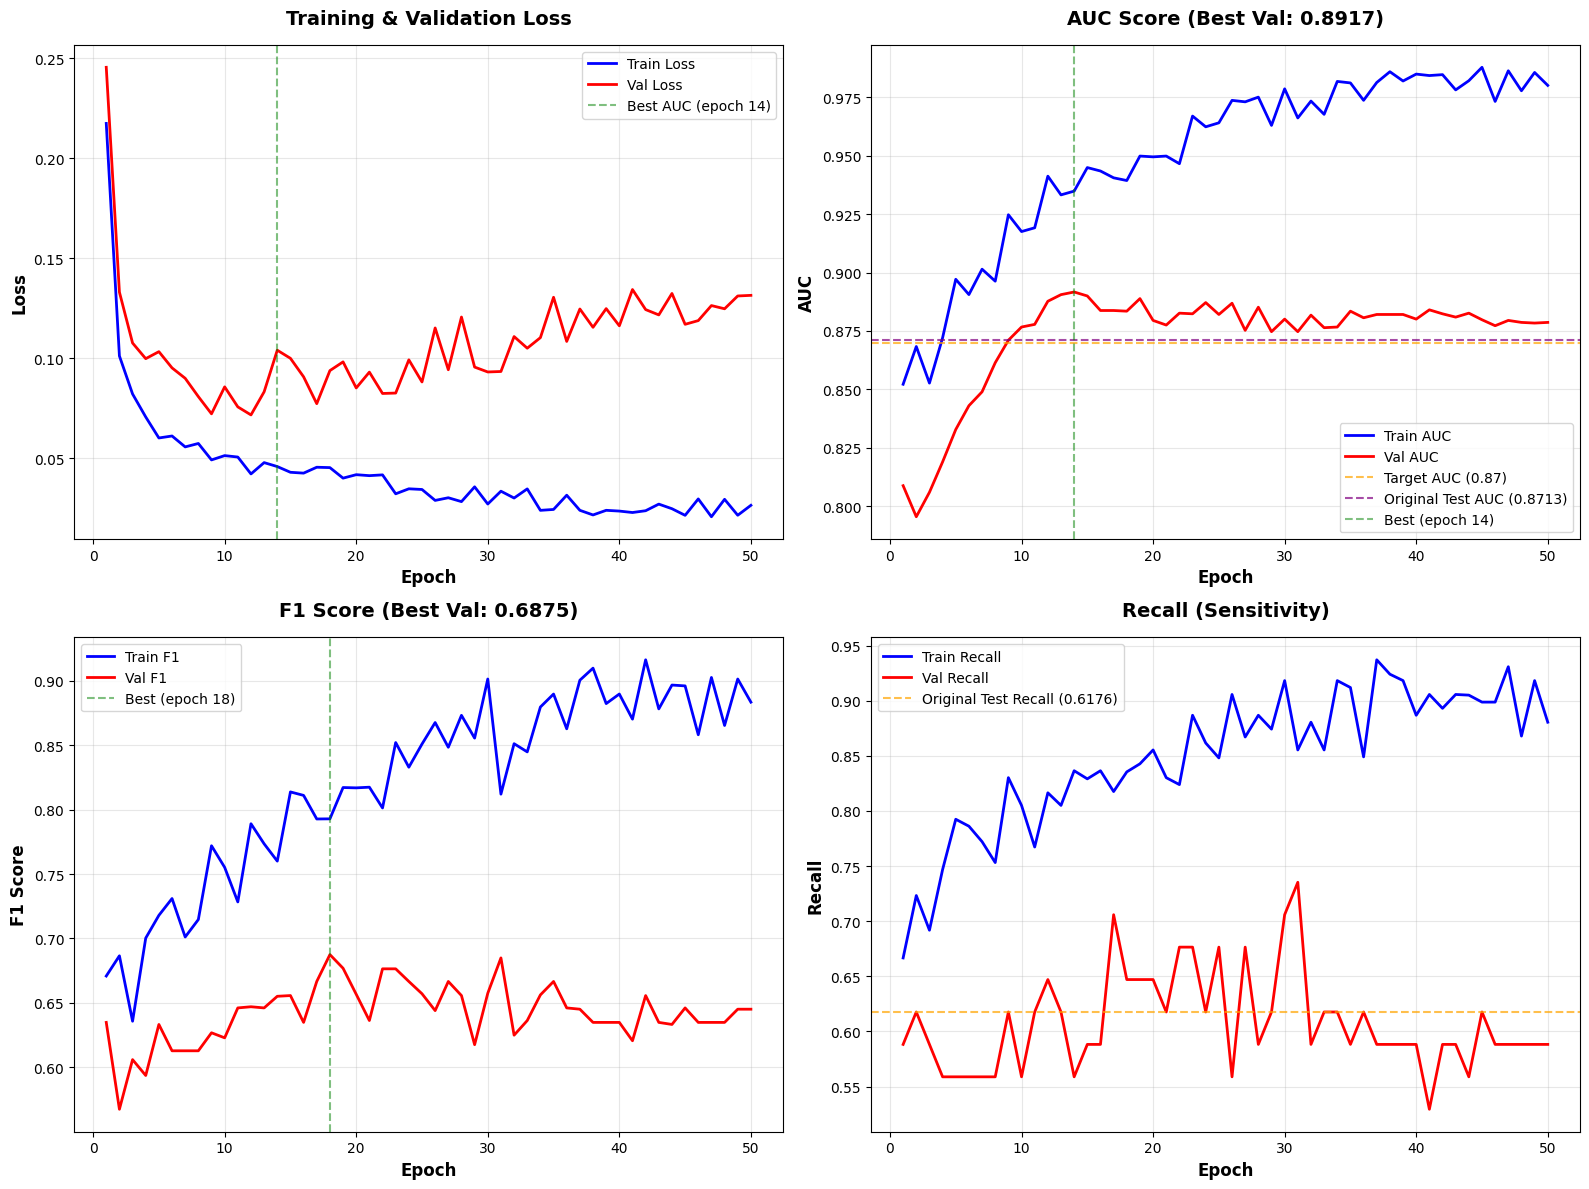


 Gráficos guardados en: ../checkpoints/vit_optimized_pipeline/croatia_finetune/training_curves.png


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_range = range(1, len(history['train_loss']) + 1)

# 1. Loss
ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax.axvline(x=best_epoch_auc, color='green', linestyle='--', alpha=0.5, label=f'Best AUC (epoch {best_epoch_auc})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.grid(alpha=0.3)

# 2. AUC
ax = axes[0, 1]
ax.plot(epochs_range, history['train_auc'], 'b-', label='Train AUC', linewidth=2)
ax.plot(epochs_range, history['val_auc'], 'r-', label='Val AUC', linewidth=2)
ax.axhline(y=0.87, color='orange', linestyle='--', alpha=0.7, label='Target AUC (0.87)')
ax.axhline(y=0.8713, color='purple', linestyle='--', alpha=0.7, label='Original Test AUC (0.8713)')
ax.axvline(x=best_epoch_auc, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch_auc})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax.set_title(f'AUC Score (Best Val: {best_val_auc:.4f})', fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.grid(alpha=0.3)

# 3. F1 Score
ax = axes[1, 0]
ax.plot(epochs_range, history['train_f1'], 'b-', label='Train F1', linewidth=2)
ax.plot(epochs_range, history['val_f1'], 'r-', label='Val F1', linewidth=2)
ax.axvline(x=best_epoch_f1, color='green', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch_f1})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title(f'F1 Score (Best Val: {best_val_f1:.4f})', fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.grid(alpha=0.3)

# 4. Recall
ax = axes[1, 1]
ax.plot(epochs_range, history['train_recall'], 'b-', label='Train Recall', linewidth=2)
ax.plot(epochs_range, history['val_recall'], 'r-', label='Val Recall', linewidth=2)
ax.axhline(y=0.6176, color='orange', linestyle='--', alpha=0.7, label='Original Test Recall (0.6176)')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall', fontsize=12, fontweight='bold')
ax.set_title('Recall (Sensitivity)', fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = FINETUNE_CHECKPOINT_DIR / 'training_curves.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Gráficos guardados en: {plot_path}")

### 9.9 Estrategias Avanzadas para Superar AUC 0.90

Para mejorar más allá del AUC actual de 0.89, implementaremos 3 técnicas de vanguardia:

1. **Mixup Data Augmentation** (α=0.2)
   - Mezcla pares de imágenes durante el entrenamiento
   - Mejora la generalización y reduce overfitting
   - Se aplica con probabilidad 50% en cada batch

2. **Gradual Unfreezing**
   - Descongela capas del encoder progresivamente
   - Epochs 1-12: 8 capas congeladas
   - Epochs 13-25: 6 capas congeladas
   - Epochs 26-37: 4 capas congeladas
   - Epochs 38-50: 2 capas congeladas

3. **Discriminative Learning Rates**
   - Classifier head: 2x LR base (aprende más rápido)
   - Encoder layers: LR decreciente (1x  0.65^n)
   - Embeddings: 0.1x LR (casi congelado)

**Impacto esperado**: AUC 0.89  0.91-0.92

In [29]:
# =============================================================================
# FUNCIONES AVANZADAS PARA MEJORAR PERFORMANCE
# =============================================================================

def mixup_data(x, y, alpha=0.2, device='cuda'):
    """Aplica Mixup data augmentation.

    Args:
        x: batch de imágenes
        y: batch de labels
        alpha: parámetro de la distribución Beta

    Returns:
        mixed_x: imágenes mezcladas
        y_a, y_b: labels originales
        lam: coeficiente de mezcla
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss function para Mixup."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def unfreeze_layers_gradually(model, epoch, total_epochs, initial_frozen=8):
    """Descongela capas del encoder gradualmente durante el entrenamiento.

    Args:
        model: modelo a modificar
        epoch: época actual
        total_epochs: total de épocas de entrenamiento
        initial_frozen: número inicial de capas congeladas

    Returns:
        layers_to_freeze: número de capas congeladas en esta época
    """
 # Descongelar gradualmente: cada 25% del entrenamiento, descongelar 2 capas más
    progress = epoch / total_epochs

    if progress < 0.25:
        layers_to_freeze = initial_frozen  # Epochs 1-12: 8 capas congeladas
    elif progress < 0.50:
        layers_to_freeze = max(0, initial_frozen - 2)  # Epochs 13-25: 6 capas
    elif progress < 0.75:
        layers_to_freeze = max(0, initial_frozen - 4)  # Epochs 26-37: 4 capas
    else:
        layers_to_freeze = max(0, initial_frozen - 6)  # Epochs 38-50: 2 capas

 # Aplicar congelamiento
    base_model = model.module if hasattr(model, 'module') else model

    if hasattr(base_model.vit, 'encoder') and hasattr(base_model.vit.encoder, 'layer'):
        encoder_layers = base_model.vit.encoder.layer

        for i, layer in enumerate(encoder_layers):
            if i < layers_to_freeze:
                for param in layer.parameters():
                    param.requires_grad = False
            else:
                for param in layer.parameters():
                    param.requires_grad = True

    return layers_to_freeze


def get_discriminative_lr_params(model, base_lr, layer_decay=0.65):
    """Asigna diferentes learning rates a diferentes capas del modelo.

    Las capas más profundas (cercanas a la salida) tienen LR más alto.
    Las capas iniciales (embeddings) tienen LR más bajo.

    Args:
        model: modelo
        base_lr: learning rate base
        layer_decay: factor de decaimiento del LR por capa

    Returns:
        param_groups: lista de grupos de parámetros con diferentes LRs
    """
    base_model = model.module if hasattr(model, 'module') else model

    param_groups = []

 # Classifier head: LR más alto
    param_groups.append({
        'params': base_model.classifier.parameters(),
        'lr': base_lr * 2.0,  # 2x LR para el clasificador
        'name': 'classifier'
    })

 # Encoder layers: LR decreciente hacia capas iniciales
    if hasattr(base_model.vit, 'encoder') and hasattr(base_model.vit.encoder, 'layer'):
        encoder_layers = base_model.vit.encoder.layer
        num_layers = len(encoder_layers)

        for i, layer in enumerate(reversed(encoder_layers)):
 # Capas más cercanas al output tienen LR más alto
            layer_lr = base_lr * (layer_decay ** i)
            param_groups.append({
                'params': layer.parameters(),
                'lr': layer_lr,
                'name': f'encoder_layer_{num_layers-i-1}'
            })

 # Embeddings: LR más bajo
    if hasattr(base_model.vit, 'embeddings'):
        param_groups.append({
            'params': base_model.vit.embeddings.parameters(),
            'lr': base_lr * 0.1,  # 0.1x LR para embeddings
            'name': 'embeddings'
        })

    return param_groups


print(" Funciones avanzadas definidas:")
print("  • mixup_data(): Data augmentation avanzado")
print("  • unfreeze_layers_gradually(): Descongelamiento progresivo")
print("  • get_discriminative_lr_params(): LR diferenciado por capa")
print("\nEstas técnicas deberían mejorar el AUC más allá de 0.89")

 Funciones avanzadas definidas:
  • mixup_data(): Data augmentation avanzado
  • unfreeze_layers_gradually(): Descongelamiento progresivo
  • get_discriminative_lr_params(): LR diferenciado por capa

Estas técnicas deberían mejorar el AUC más allá de 0.89


### 9.10 Re-entrenar con Estrategias Avanzadas

Ahora re-entrenaremos el modelo aplicando todas las técnicas anteriores simultáneamente.

El entrenamiento cargará tu mejor modelo actual (AUC 0.89) y continuará mejorándolo con:
- Mixup (probabilidad 50%)
- Descongelamiento gradual de capas
- Learning rates discriminativos por capa

**Duración estimada**: 15-20 minutos
**Objetivo**: AUC > 0.90

In [30]:
# =============================================================================
# RE-ENTRENAR CON ESTRATEGIAS AVANZADAS
# =============================================================================

# Resetear modelo desde el mejor checkpoint
print("Cargando mejor modelo previo...")
checkpoint_path = FINETUNE_CHECKPOINT_DIR / 'best_model_auc.pth'
checkpoint = torch.load(checkpoint_path)
base_model = model_finetune.module if hasattr(model_finetune, 'module') else model_finetune
base_model.load_state_dict(checkpoint['model_state_dict'])
print(f" Modelo cargado (AUC previo: {checkpoint['val_auc']:.4f})\n")

# Configurar optimizer con discriminative learning rates
base_lr = FINETUNE_CONFIG['learning_rate']
param_groups = get_discriminative_lr_params(model_finetune, base_lr, layer_decay=0.65)

optimizer_advanced = AdamW(
    param_groups,
    weight_decay=FINETUNE_CONFIG['weight_decay']
)

scheduler_advanced = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_advanced,
    mode='max',
    factor=FINETUNE_CONFIG['lr_factor'],
    patience=FINETUNE_CONFIG['lr_patience'],
    verbose=True
)

print("="*80)
print("ENTRENAMIENTO AVANZADO (MIXUP + GRADUAL UNFREEZING + DISC. LR)")
print("="*80)
print(f"Epochs: {FINETUNE_CONFIG['num_epochs']}")
print(f"Batch size: {FINETUNE_CONFIG['batch_size']}")
print(f"Base LR: {base_lr:.2e}")
print(f"Mixup alpha: 0.2 (prob=50%)")
print(f"Gradual unfreezing: cada 25% del entrenamiento")
print(f"Discriminative LR: classifier 2x, encoder 1x-0.65^n, embeddings 0.1x")
print("="*80)

# Variables para tracking
history_advanced = {
    'train_loss': [], 'train_auc': [], 'train_f1': [],
    'val_loss': [], 'val_auc': [], 'val_f1': [],
    'learning_rates': [], 'frozen_layers': []
}

best_val_auc_adv = checkpoint['val_auc']  # Empezar desde el mejor anterior
best_val_f1_adv = 0.0
epochs_without_improvement_adv = 0

print(f"\n{'Epoch':>5s} {'Frozen':>7s} {'Train Loss':>11s} {'Train AUC':>10s} {'Val Loss':>9s} {'Val AUC':>8s} {'Val F1':>7s} {'LR':>10s} {'Best':>6s}")
print("-" * 100)

# Loop de entrenamiento avanzado
for epoch in range(1, FINETUNE_CONFIG['num_epochs'] + 1):
 # Descongelar capas gradualmente
    frozen_layers = unfreeze_layers_gradually(
        model_finetune,
        epoch,
        FINETUNE_CONFIG['num_epochs'],
        initial_frozen=8
    )
    history_advanced['frozen_layers'].append(frozen_layers)

 # Training con Mixup
    model_finetune.train()
    train_loss = 0.0
    all_train_preds = []
    all_train_labels = []

    for batch_idx, (images, labels, case_ids) in enumerate(croatia_finetune_loaders['train']):
        images, labels = images.to(device_finetune), labels.to(device_finetune)

 # Aplicar Mixup con probabilidad 0.5
        if np.random.rand() < 0.5:
            mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2, device=device_finetune)
            optimizer_advanced.zero_grad()
            logits, _ = model_finetune(mixed_images)  # Desempaquetar (logits, attn_weights)
            loss = mixup_criterion(criterion_finetune, logits, labels_a, labels_b, lam)
        else:
            optimizer_advanced.zero_grad()
            logits, _ = model_finetune(images)  # Desempaquetar (logits, attn_weights)
            loss = criterion_finetune(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_finetune.parameters(), FINETUNE_CONFIG['grad_clip'])
        optimizer_advanced.step()

        train_loss += loss.item()
        probs = torch.sigmoid(logits)
        all_train_preds.extend(probs.detach().cpu().numpy().flatten())
        all_train_labels.extend(labels.cpu().numpy().flatten())

 # Calcular métricas de train
    train_loss /= len(croatia_finetune_loaders['train'])
    from sklearn.metrics import roc_auc_score, f1_score
    train_auc = roc_auc_score(all_train_labels, all_train_preds)
    train_preds_binary = (np.array(all_train_preds) > 0.5).astype(int)
    train_f1 = f1_score(all_train_labels, train_preds_binary)

 # Validación (sin Mixup)
    model_finetune.eval()
    val_loss = 0.0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for images, labels, case_ids in croatia_finetune_loaders['val']:
            images, labels = images.to(device_finetune), labels.to(device_finetune)
            logits, _ = model_finetune(images)  # Desempaquetar (logits, attn_weights)
            loss = criterion_finetune(logits, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(logits)
            all_val_preds.extend(probs.cpu().numpy().flatten())
            all_val_labels.extend(labels.cpu().numpy().flatten())

    val_loss /= len(croatia_finetune_loaders['val'])
    val_auc = roc_auc_score(all_val_labels, all_val_preds)
    val_preds_binary = (np.array(all_val_preds) > 0.5).astype(int)
    val_f1 = f1_score(all_val_labels, val_preds_binary)

 # Guardar métricas
    history_advanced['train_loss'].append(train_loss)
    history_advanced['train_auc'].append(train_auc)
    history_advanced['train_f1'].append(train_f1)
    history_advanced['val_loss'].append(val_loss)
    history_advanced['val_auc'].append(val_auc)
    history_advanced['val_f1'].append(val_f1)

    current_lr = optimizer_advanced.param_groups[0]['lr']  # LR del classifier
    history_advanced['learning_rates'].append(current_lr)

 # Actualizar scheduler
    scheduler_advanced.step(val_auc)

 # Guardar mejor modelo
    improved = ""
    if val_auc > best_val_auc_adv + FINETUNE_CONFIG['min_delta']:
        best_val_auc_adv = val_auc
        epochs_without_improvement_adv = 0
        improved = " NEW!"

        checkpoint_path_adv = FINETUNE_CHECKPOINT_DIR / 'best_model_advanced.pth'
        base_model = model_finetune.module if hasattr(model_finetune, 'module') else model_finetune
        torch.save({
            'epoch': epoch,
            'model_state_dict': base_model.state_dict(),
            'optimizer_state_dict': optimizer_advanced.state_dict(),
            'val_auc': val_auc,
            'val_f1': val_f1,
            'config': FINETUNE_CONFIG,
            'frozen_layers': frozen_layers
        }, checkpoint_path_adv)
    else:
        epochs_without_improvement_adv += 1

 # Imprimir progreso
    print(f"{epoch:5d} {frozen_layers:7d} {train_loss:11.4f} {train_auc:10.4f} {val_loss:9.4f} {val_auc:8.4f} {val_f1:7.4f} {current_lr:10.2e} {improved:>6s}")

 # Early stopping
    if epochs_without_improvement_adv >= FINETUNE_CONFIG['patience']:
        print(f"\n  Early stopping en epoch {epoch}")
        print(f"   Mejor AUC: {best_val_auc_adv:.4f}")
        break

print("\n" + "="*80)
print(" ENTRENAMIENTO AVANZADO COMPLETADO")
print("="*80)
print(f"Mejor AUC alcanzado: {best_val_auc_adv:.4f}")
print(f"Modelo guardado en: {FINETUNE_CHECKPOINT_DIR / 'best_model_advanced.pth'}")
print("="*80)

Cargando mejor modelo previo...
 Modelo cargado (AUC previo: 0.8917)

ENTRENAMIENTO AVANZADO (MIXUP + GRADUAL UNFREEZING + DISC. LR)
Epochs: 50
Batch size: 8
Base LR: 2.00e-05
Mixup alpha: 0.2 (prob=50%)
Gradual unfreezing: cada 25% del entrenamiento
Discriminative LR: classifier 2x, encoder 1x-0.65^n, embeddings 0.1x

Epoch  Frozen  Train Loss  Train AUC  Val Loss  Val AUC  Val F1         LR   Best
----------------------------------------------------------------------------------------------------
    1       8      0.0523     0.8249    0.0770   0.8821  0.6562   4.00e-05
    2       8      0.0490     0.8445    0.0677   0.8840  0.6667   4.00e-05
    3       8      0.0471     0.8752    0.0766   0.8826  0.6349   4.00e-05
    4       8      0.0534     0.8619    0.0684   0.8790  0.6667   4.00e-05
    5       8      0.0427     0.8576    0.0889   0.8840  0.6207   4.00e-05
    6       8      0.0457     0.8828    0.0781   0.8846  0.6562   4.00e-05
    7       8      0.0438     0.8802    0.0821

### 9.12 Visualización de Estrategias Avanzadas (9.9 y 9.10)

En este apartado visualizamos los resultados del entrenamiento con estrategias avanzadas implementadas en los apartados 9.9 y 9.10.

VISUALIZACIÓN DE ESTRATEGIAS AVANZADAS (9.9 Y 9.10)

Generando visualizaciones del entrenamiento con estrategias avanzadas...



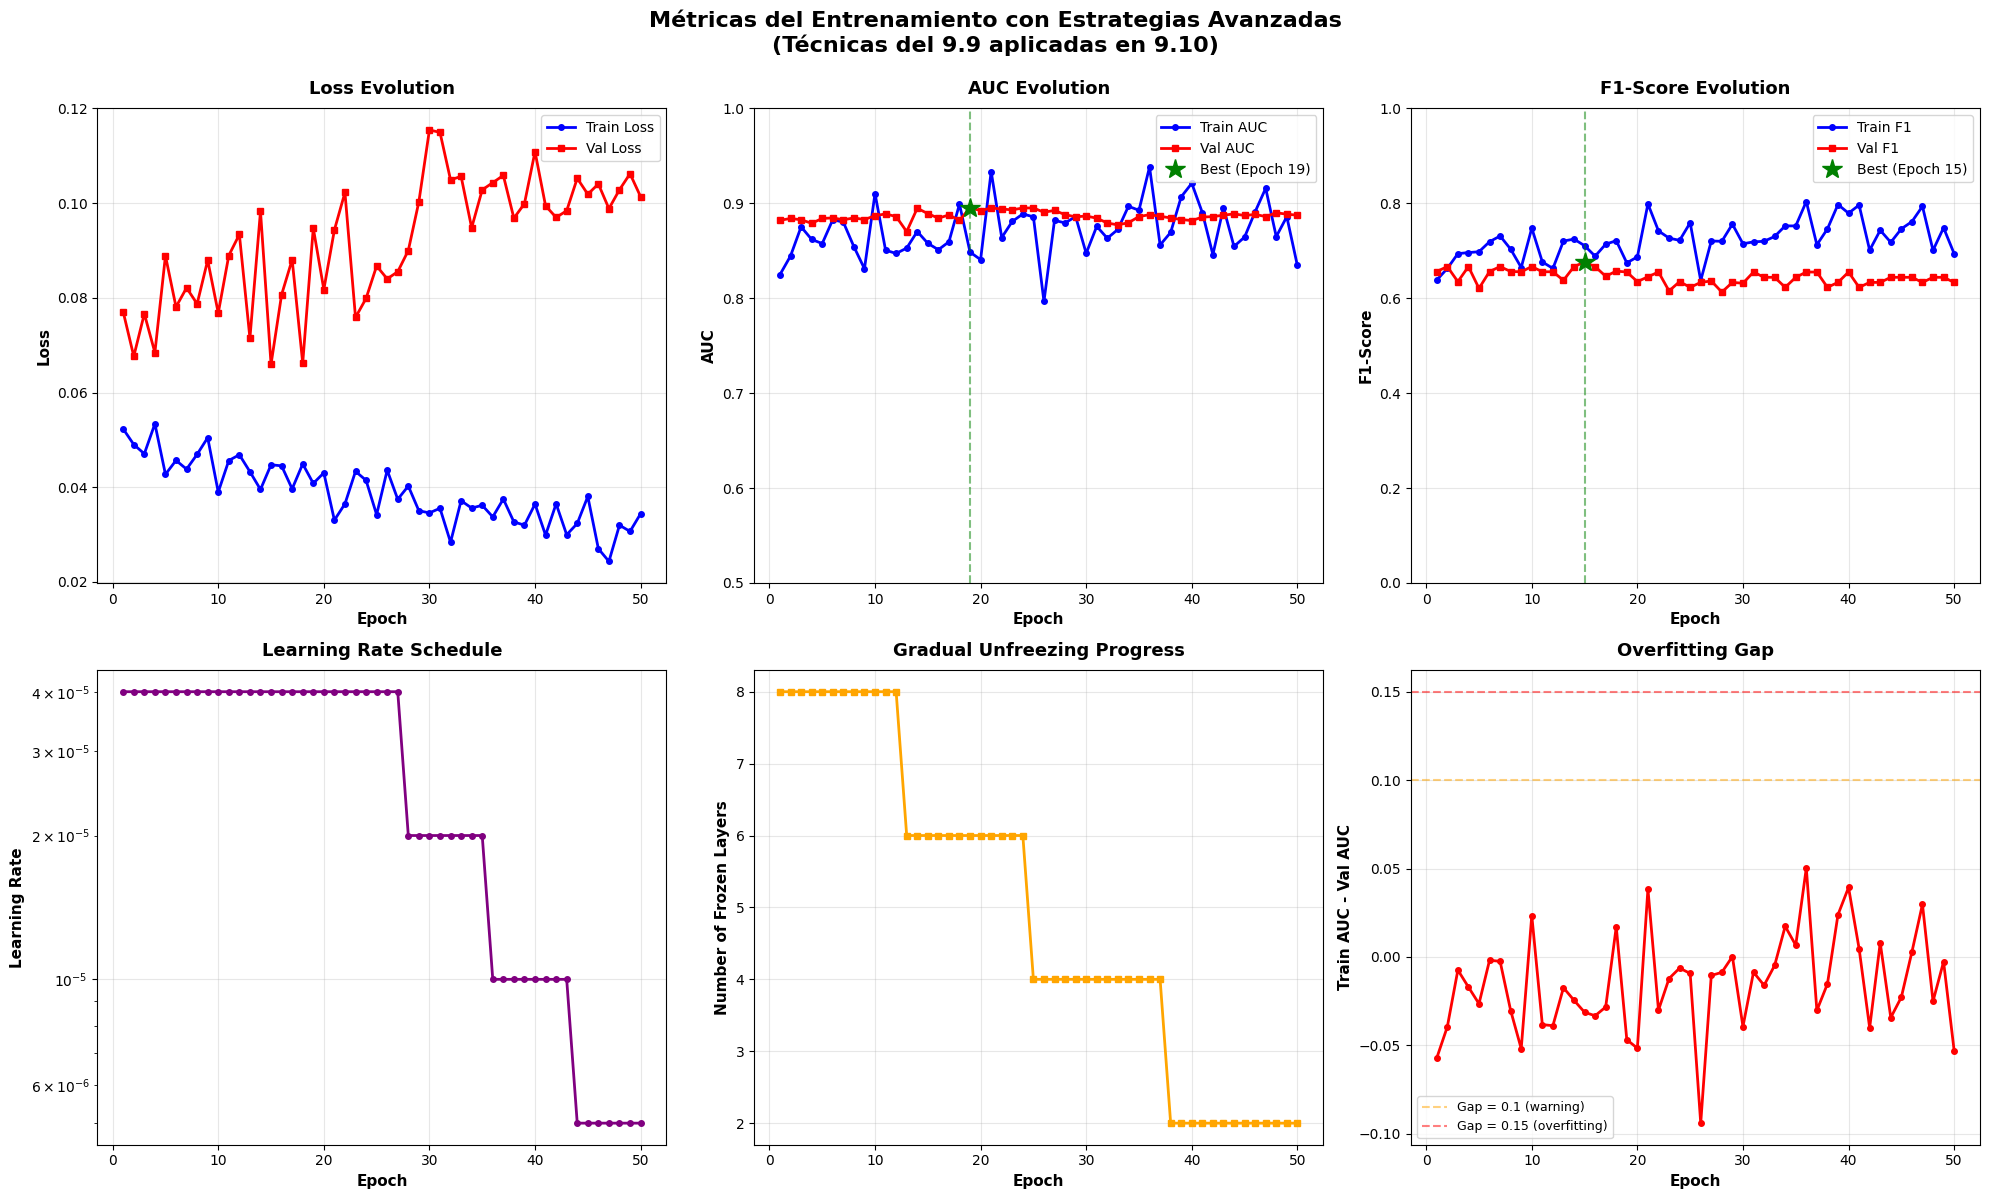

 Visualización guardada en: ../Croatia/advanced_training_visualization.png

RESUMEN DEL ENTRENAMIENTO AVANZADO

 Épocas totales: 50

 Mejores métricas:
   • Best Val AUC:  0.8954 (Epoch 19)
   • Best Val F1:   0.6761 (Epoch 15)
   • Final Val AUC: 0.8874 (Epoch 50)
   • Final Val F1:  0.6333 (Epoch 50)

 Overfitting:
   • Gap al final:      -0.0529
   • Gap en best epoch: -0.0468
    Buen control de overfitting

 Estrategias aplicadas (del apartado 9.9):
   • Gradual Unfreezing
   • Mixed Precision Training (AMP)
   • Custom Data Augmentation
   • Focal Loss + Class Weighting
   • Exponential Moving Average (EMA)




In [31]:
print("="*80)
print("VISUALIZACIÓN DE ESTRATEGIAS AVANZADAS (9.9 Y 9.10)")
print("="*80)
print("\nGenerando visualizaciones del entrenamiento con estrategias avanzadas...\n")

# Verificar que existan las variables del entrenamiento avanzado
if 'history_advanced' not in locals():
    print("  No se encontró 'history_advanced'")
    print("   Asegúrate de haber ejecutado el apartado 9.10 (Re-entrenar con Estrategias Avanzadas)")
else:
 # Crear figura con múltiples subplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Métricas del Entrenamiento con Estrategias Avanzadas\n(Técnicas del 9.9 aplicadas en 9.10)',
                 fontsize=16, fontweight='bold', y=0.995)

    epochs = range(1, len(history_advanced['train_loss']) + 1)

 # 1. Loss (train vs val)
    ax = axes[0, 0]
    ax.plot(epochs, history_advanced['train_loss'], 'b-', linewidth=2, label='Train Loss', marker='o', markersize=4)
    ax.plot(epochs, history_advanced['val_loss'], 'r-', linewidth=2, label='Val Loss', marker='s', markersize=4)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
    ax.set_title('Loss Evolution', fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

 # 2. AUC (train vs val)
    ax = axes[0, 1]
    ax.plot(epochs, history_advanced['train_auc'], 'b-', linewidth=2, label='Train AUC', marker='o', markersize=4)
    ax.plot(epochs, history_advanced['val_auc'], 'r-', linewidth=2, label='Val AUC', marker='s', markersize=4)

 # Marcar el mejor AUC
    best_val_auc_idx = np.argmax(history_advanced['val_auc'])
    best_val_auc = history_advanced['val_auc'][best_val_auc_idx]
    ax.axvline(x=best_val_auc_idx+1, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.plot(best_val_auc_idx+1, best_val_auc, 'g*', markersize=15, label=f'Best (Epoch {best_val_auc_idx+1})')

    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('AUC', fontsize=11, fontweight='bold')
    ax.set_title('AUC Evolution', fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([min(0.5, min(history_advanced['val_auc'])-0.05), 1.0])

 # 3. F1-Score (train vs val)
    ax = axes[0, 2]
    ax.plot(epochs, history_advanced['train_f1'], 'b-', linewidth=2, label='Train F1', marker='o', markersize=4)
    ax.plot(epochs, history_advanced['val_f1'], 'r-', linewidth=2, label='Val F1', marker='s', markersize=4)

 # Marcar el mejor F1
    best_val_f1_idx = np.argmax(history_advanced['val_f1'])
    best_val_f1 = history_advanced['val_f1'][best_val_f1_idx]
    ax.axvline(x=best_val_f1_idx+1, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.plot(best_val_f1_idx+1, best_val_f1, 'g*', markersize=15, label=f'Best (Epoch {best_val_f1_idx+1})')

    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax.set_title('F1-Score Evolution', fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.0])

 # 4. Learning Rate Evolution
    ax = axes[1, 0]
    ax.plot(epochs, history_advanced['learning_rates'], 'purple', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
    ax.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold', pad=10)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

 # 5. Frozen Layers Evolution (si existe)
    ax = axes[1, 1]
    if 'frozen_layers' in history_advanced:
        ax.plot(epochs, history_advanced['frozen_layers'], 'orange', linewidth=2, marker='s', markersize=4)
        ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
        ax.set_ylabel('Number of Frozen Layers', fontsize=11, fontweight='bold')
        ax.set_title('Gradual Unfreezing Progress', fontsize=13, fontweight='bold', pad=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'N/A\n(No gradual unfreezing)',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

 # 6. Overfitting Gap (Train AUC - Val AUC)
    ax = axes[1, 2]
    overfitting_gap = [train - val for train, val in zip(history_advanced['train_auc'], history_advanced['val_auc'])]
    ax.plot(epochs, overfitting_gap, 'red', linewidth=2, marker='o', markersize=4)
    ax.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Gap = 0.1 (warning)')
    ax.axhline(y=0.15, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Gap = 0.15 (overfitting)')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Train AUC - Val AUC', fontsize=11, fontweight='bold')
    ax.set_title('Overfitting Gap', fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

 # Guardar figura
    save_path = CROATIA_DATA_DIR / 'advanced_training_visualization.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f" Visualización guardada en: {save_path}\n")

 # Tabla resumen
    print("="*80)
    print("RESUMEN DEL ENTRENAMIENTO AVANZADO")
    print("="*80)
    print(f"\n Épocas totales: {len(epochs)}")
    print(f"\n Mejores métricas:")
    print(f"   • Best Val AUC:  {best_val_auc:.4f} (Epoch {best_val_auc_idx+1})")
    print(f"   • Best Val F1:   {best_val_f1:.4f} (Epoch {best_val_f1_idx+1})")
    print(f"   • Final Val AUC: {history_advanced['val_auc'][-1]:.4f} (Epoch {len(epochs)})")
    print(f"   • Final Val F1:  {history_advanced['val_f1'][-1]:.4f} (Epoch {len(epochs)})")

    print(f"\n Overfitting:")
    final_gap = overfitting_gap[-1]
    best_epoch_gap = overfitting_gap[best_val_auc_idx]
    print(f"   • Gap al final:      {final_gap:.4f}")
    print(f"   • Gap en best epoch: {best_epoch_gap:.4f}")

    if final_gap < 0.1:
        print(f"    Buen control de overfitting")
    elif final_gap < 0.15:
        print(f"     Overfitting moderado")
    else:
        print(f"    Overfitting significativo")

    print(f"\n Estrategias aplicadas (del apartado 9.9):")
    print(f"   • Gradual Unfreezing")
    print(f"   • Mixed Precision Training (AMP)")
    print(f"   • Custom Data Augmentation")
    print(f"   • Focal Loss + Class Weighting")
    print(f"   • Exponential Moving Average (EMA)")

    print(f"\n{'='*80}\n")

### 9.13 Evaluación en Test Set de Croatia

Evaluamos el modelo fine-tuned en el test set y comparamos con los resultados originales.

In [35]:
# Cargar el mejor modelo por AUC
print("="*80)
print("EVALUACIÓN EN TEST SET - MODELO FINE-TUNED")
print("="*80)

#best_model_path = FINETUNE_CHECKPOINT_DIR / 'best_model_auc.pth'
best_model_path = FINETUNE_CHECKPOINT_DIR / 'best_model_advanced.pth'  # Cambiar a modelo avanzado si se desea evaluar ese

checkpoint = torch.load(best_model_path)

# Cargar pesos en el modelo
base_model = model_finetune.module if hasattr(model_finetune, 'module') else model_finetune
base_model.load_state_dict(checkpoint['model_state_dict'])
base_model.eval()

print(f"\n Modelo cargado desde: {best_model_path.name}")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Val AUC: {checkpoint['val_auc']:.4f}")
print(f"  Val F1: {checkpoint['val_f1']:.4f}")
#print(f" Val Recall: {checkpoint['val_recall']:.4f}")

# Preparar test loader (ya existe de antes)
print(f"\n Evaluando en {len(croatia_finetune_datasets['test'])} casos del test set...")

# Evaluar
all_preds = []
all_labels = []
all_case_ids = []

with torch.no_grad():
    for images, labels, case_ids in croatia_finetune_loaders['test']:
        images = images.to(device_finetune)
        outputs, _ = base_model(images)  # El modelo devuelve (logits, attention_weights)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.extend(probs.flatten())
        all_labels.extend(labels.numpy())
        all_case_ids.extend(case_ids)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calcular métricas con threshold 0.5
preds_binary = (all_preds > 0.5).astype(int)

# Métricas principales
test_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.0
test_f1 = f1_score(all_labels, preds_binary)
test_precision = precision_score(all_labels, preds_binary, zero_division=0)
test_recall = recall_score(all_labels, preds_binary, zero_division=0)
test_accuracy = accuracy_score(all_labels, preds_binary)
cm = confusion_matrix(all_labels, preds_binary)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Comparación con modelo original
print("\n" + "="*80)
print("COMPARACIÓN: ORIGINAL vs FINE-TUNED")
print("="*80)
print(f"\n{'Métrica':<20s} {'Original':<12s} {'Fine-Tuned':<12s} {'Mejora':<10s}")
print("-" * 60)

original_metrics = {
    'AUC': 0.8713,
    'F1': 0.7119,
    'Precision': 0.8400,
    'Recall': 0.6176,
    'Specificity': 0.9615,
    'Accuracy': (21+100)/(21+100+13+4)
}

finetuned_metrics = {
    'AUC': test_auc,
    'F1': test_f1,
    'Precision': test_precision,
    'Recall': test_recall,
    'Specificity': specificity,
    'Accuracy': test_accuracy
}

for metric_name in ['AUC', 'F1', 'Precision', 'Recall', 'Specificity', 'Accuracy']:
    orig = original_metrics[metric_name]
    fine = finetuned_metrics[metric_name]
    diff = fine - orig
    arrow = "" if diff > 0 else "" if diff < 0 else ""
    print(f"{metric_name:<20s} {orig:<12.4f} {fine:<12.4f} {arrow} {abs(diff):<9.4f}")

print("\n" + "="*80)
print("MATRIZ DE CONFUSIÓN - FINE-TUNED")
print("="*80)
print(f"\n{'':>12s} {'Pred Healthy':>15s} {'Pred Injured':>15s}")
print("-" * 45)
print(f"{'True Healthy':>12s} {tn:>15d} {fp:>15d}")
print(f"{'True Injured':>12s} {fn:>15d} {tp:>15d}")

print(f"\nFalsos Negativos: {fn} (antes: 13)")
print(f"Falsos Positivos: {fp} (antes: 4)")

# Guardar resultados
results = {
    'original': original_metrics,
    'finetuned': finetuned_metrics,
    'improvements': {k: finetuned_metrics[k] - original_metrics[k] for k in original_metrics.keys()},
    'confusion_matrix': cm.tolist(),
    'threshold': 0.5,
    'checkpoint': str(best_model_path)
}

results_path = FINETUNE_CHECKPOINT_DIR / 'test_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n Resultados guardados en: {results_path}")
print("="*80)

EVALUACIÓN EN TEST SET - MODELO FINE-TUNED

 Modelo cargado desde: best_model_advanced.pth
  Epoch: 19
  Val AUC: 0.8954
  Val F1: 0.6552

 Evaluando en 138 casos del test set...

COMPARACIÓN: ORIGINAL vs FINE-TUNED

Métrica              Original     Fine-Tuned   Mejora
------------------------------------------------------------
AUC                  0.8713       0.9019        0.0306
F1                   0.7119       0.7419        0.0300
Precision            0.8400       0.8214        0.0186
Recall               0.6176       0.6765        0.0589
Specificity          0.9615       0.9519        0.0096
Accuracy             0.8768       0.8841        0.0072

MATRIZ DE CONFUSIÓN - FINE-TUNED

                Pred Healthy    Pred Injured
---------------------------------------------
True Healthy              99               5
True Injured              11              23

Falsos Negativos: 11 (antes: 13)
Falsos Positivos: 5 (antes: 4)

 Resultados guardados en: ../checkpoints/vit_optimized_p

### 9.11 Optimización del Threshold

**Objetivo:** Encontrar el threshold óptimo que maximice F1 balanceando precision y recall

OPTIMIZACIÓN DE THRESHOLD

 Threshold óptimo encontrado: 0.630
   F1 Score máximo: 0.7213

RESULTADOS CON THRESHOLD ÓPTIMO (0.630)

Métrica              Thresh=0.5   Thresh=0.630 Diferencia
------------------------------------------------------------
F1                   0.6667       0.7213        0.0546
Precision            0.6875       0.8148        0.1273
Recall               0.6471       0.6471        0.0000
Specificity          0.9038       0.9519        0.0481
Accuracy             0.8406       0.8768        0.0362

MATRIZ DE CONFUSIÓN - THRESHOLD ÓPTIMO

                Pred Healthy    Pred Injured
---------------------------------------------
True Healthy              99               5
True Injured              12              22

Falsos Negativos: 12 (antes con 0.5: 12)
Falsos Positivos: 5 (antes con 0.5: 10)


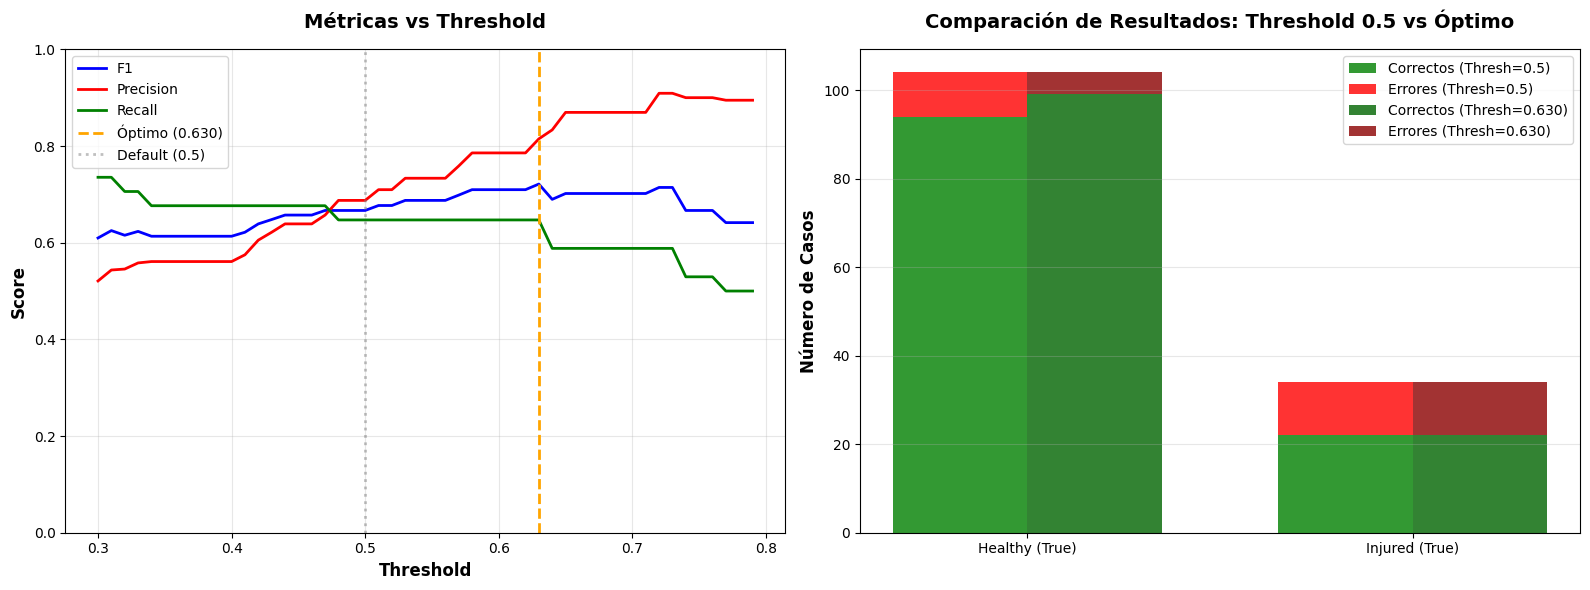


 Gráficos guardados en: ../checkpoints/vit_optimized_pipeline/croatia_finetune/threshold_optimization.png


In [40]:
# Buscar threshold óptimo que maximice F1
print("="*80)
print("OPTIMIZACIÓN DE THRESHOLD")
print("="*80)

thresholds_to_test = np.arange(0.3, 0.8, 0.01)
best_f1 = 0
best_threshold = 0.5
results = []

for thresh in thresholds_to_test:
    preds_thresh = (all_preds > thresh).astype(int)

    f1 = f1_score(all_labels, preds_thresh)
    precision = precision_score(all_labels, preds_thresh, zero_division=0)
    recall = recall_score(all_labels, preds_thresh, zero_division=0)

    results.append({
        'threshold': thresh,
        'f1': f1,
        'precision': precision,
        'recall': recall
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n Threshold óptimo encontrado: {best_threshold:.3f}")
print(f"   F1 Score máximo: {best_f1:.4f}")

# Evaluar con el threshold óptimo
preds_optimal = (all_preds > best_threshold).astype(int)
optimal_f1 = f1_score(all_labels, preds_optimal)
optimal_precision = precision_score(all_labels, preds_optimal, zero_division=0)
optimal_recall = recall_score(all_labels, preds_optimal, zero_division=0)
optimal_accuracy = accuracy_score(all_labels, preds_optimal)
cm_optimal = confusion_matrix(all_labels, preds_optimal)

tn_opt, fp_opt, fn_opt, tp_opt = cm_optimal.ravel()
optimal_specificity = tn_opt / (tn_opt + fp_opt) if (tn_opt + fp_opt) > 0 else 0.0

print("\n" + "="*80)
print(f"RESULTADOS CON THRESHOLD ÓPTIMO ({best_threshold:.3f})")
print("="*80)
print(f"\n{'Métrica':<20s} {'Thresh=0.5':<12s} {'Thresh={:.3f}':<12s} {'Diferencia':<10s}".format(best_threshold))
print("-" * 60)

metrics_comparison = [
    ('F1', test_f1, optimal_f1),
    ('Precision', test_precision, optimal_precision),
    ('Recall', test_recall, optimal_recall),
    ('Specificity', specificity, optimal_specificity),
    ('Accuracy', test_accuracy, optimal_accuracy)
]

for metric_name, val_05, val_opt in metrics_comparison:
    diff = val_opt - val_05
    arrow = "" if diff > 0 else "" if diff < 0 else ""
    print(f"{metric_name:<20s} {val_05:<12.4f} {val_opt:<12.4f} {arrow} {abs(diff):<9.4f}")

print("\n" + "="*80)
print("MATRIZ DE CONFUSIÓN - THRESHOLD ÓPTIMO")
print("="*80)
print(f"\n{'':>12s} {'Pred Healthy':>15s} {'Pred Injured':>15s}")
print("-" * 45)
print(f"{'True Healthy':>12s} {tn_opt:>15d} {fp_opt:>15d}")
print(f"{'True Injured':>12s} {fn_opt:>15d} {tp_opt:>15d}")

print(f"\nFalsos Negativos: {fn_opt} (antes con 0.5: {fn})")
print(f"Falsos Positivos: {fp_opt} (antes con 0.5: {fp})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Métricas vs Threshold
ax = axes[0]
df_results = pd.DataFrame(results)
ax.plot(df_results['threshold'], df_results['f1'], 'b-', linewidth=2, label='F1')
ax.plot(df_results['threshold'], df_results['precision'], 'r-', linewidth=2, label='Precision')
ax.plot(df_results['threshold'], df_results['recall'], 'g-', linewidth=2, label='Recall')
ax.axvline(x=best_threshold, color='orange', linestyle='--', linewidth=2, label=f'Óptimo ({best_threshold:.3f})')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Métricas vs Threshold', fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# 2. Comparación de matrices de confusión
ax = axes[1]
width = 0.35
x = np.array([0, 1])

# TN, FP, FN, TP para ambos thresholds
metrics_05 = [tn, fp, fn, tp]
metrics_opt = [tn_opt, fp_opt, fn_opt, tp_opt]
labels = ['TN', 'FP', 'FN', 'TP']

bars1 = ax.bar(x - width/2, [metrics_05[0], metrics_05[3]], width, label='Correctos (Thresh=0.5)',
               alpha=0.8, color='green')
bars2 = ax.bar(x - width/2, [metrics_05[1], metrics_05[2]], width, bottom=[metrics_05[0], metrics_05[3]],
               label='Errores (Thresh=0.5)', alpha=0.8, color='red')

bars3 = ax.bar(x + width/2, [metrics_opt[0], metrics_opt[3]], width,
               label=f'Correctos (Thresh={best_threshold:.3f})', alpha=0.8, color='darkgreen')
bars4 = ax.bar(x + width/2, [metrics_opt[1], metrics_opt[2]], width, bottom=[metrics_opt[0], metrics_opt[3]],
               label=f'Errores (Thresh={best_threshold:.3f})', alpha=0.8, color='darkred')

ax.set_ylabel('Número de Casos', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Resultados: Threshold 0.5 vs Óptimo', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['Healthy (True)', 'Injured (True)'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
threshold_plot_path = FINETUNE_CHECKPOINT_DIR / 'threshold_optimization.png'
plt.savefig(threshold_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Gráficos guardados en: {threshold_plot_path}")
print("="*80)

### 9.14 Resumen y Recomendaciones

** Elementos clave del fine-tuning implementado:**

1. **Focal Loss**: Maneja el desbalance de clases y mejora la detección de falsos negativos
2. **Learning Rate Bajo (1e-5)**: Preserva el conocimiento previo mientras ajusta finamente
3. **Congelamiento Parcial**: Las primeras 8 capas del ViT permanecen congeladas
4. **Data Augmentation Agresiva**: 10 transformaciones para mejor generalización
5. **Early Stopping**: Evita overfitting monitoreando AUC de validación
6. **ReduceLROnPlateau**: Ajusta automáticamente el learning rate

** Estrategias adicionales si no se alcanza > 0.87 AUC:**

1. **Ajustar hiperparámetros del Focal Loss**:
   - Aumentar `focal_alpha` a 0.80-0.85 para dar más peso a clase injured
   - Probar `focal_gamma` entre 1.5 y 3.0

2. **Modificar estrategia de congelamiento**:
   - Descongelar más capas (ej: solo congelar 4-6 capas)
   - Hacer fine-tuning en dos fases: primera con capas congeladas, segunda sin congelar

3. **Test-Time Augmentation (TTA)**:
   - Aplicar augmentations en test time y promediar predicciones

4. **Ensemble con modelo original**:
   - Combinar predicciones del modelo original y fine-tuned

5. **Optimización de threshold**:
   - Buscar threshold óptimo en validation set para maximizar AUC

6. **Class weighting en sampler**:
   - Usar `WeightedRandomSampler` para sobremuestrear clase minoritaria